# Olist Brazilian Marketplace — Analytics Deep Dive

**Dataset:** Brazilian E-Commerce Public Dataset by Olist (~100k orders, Sep 2016 – Oct 2018, 9 relational tables)
**Role:** Data Analyst supporting Olist's operations and customer-experience teams
**Deliverable:** an evidence-based account of (1) how the marketplace performed, (2) what is associated with customer satisfaction and dissatisfaction, and (3) what Olist should prioritise next.

---

### How this notebook is organised

| # | Section | What it delivers |
|---|---------|------------------|
| 0 | Setup & helpers | Environment, plotting theme, reusable statistics functions |
| 1 | Data loading | Flexible loader (local folder / Google Drive / manual upload) |
| 2 | Data understanding | Shape, types, missingness, key uniqueness, referential integrity |
| 3 | Data cleaning | Documented, reversible cleaning decisions + a cleaning log |
| 4 | Feature engineering | One analysis-ready **order-level master table** |
| 5 | Exploratory data analysis | Distributions, KPI baseline, univariate shape of every key variable |
| 6 | **Core Q1** | Marketplace performance over time |
| 7 | **Core Q2** | Delivery performance vs. customer satisfaction |
| 8 | **Core Q3** | Seller and geographic patterns |
| 9 | **Core Q4** | Product category performance |
| 10 | **Core Q5** | Payment behaviour |
| 11 | **Core Q6** | Root-cause analysis of low review scores |
| 12 | Deep dive A | Repeat customers and their value |
| 13 | Deep dive B | Seller-level performance, controlled |
| 14 | Deep dive C | Anomaly detection and flagging |
| 15 | Review text mining | What the written Portuguese comments add |
| 16 | Key findings | Consolidated evidence table, priorities, expected impact |
| 17 | Appendix | Assumptions, limitations, exported artefacts |

### Analytical conventions used throughout

1. **Every claim is tied to a number.** Each analysis cell prints an interpretation block generated from the computed values, so the narrative can never drift from the data.
2. **Effect size before p-value.** With ~100k rows almost anything is "statistically significant"; the notebook therefore always reports a magnitude (Cliff's delta, Cramér's V, risk ratio, eta²) next to any test.
3. **Association, not causation.** This is observational data. Wording is deliberately "associated with", and the root-cause section separates *primary* from *secondary/confounded* factors using stratified checks.
4. **Confidence intervals on rates.** Proportions (e.g. % low reviews) use Wilson intervals so small segments are not over-read.
5. **Reproducibility.** No hidden state; the notebook runs top to bottom, every random operation is seeded, and key results are collected into a `FINDINGS` registry that builds the executive summary at the end.

> **Plain-language summary boxes** appear after every technical block, marked **In plain terms**.


## 0. Setup — environment, plotting theme and statistical helpers

**What this section does:** imports libraries, fixes a consistent visual style so every chart in the notebook reads the same way, and defines the statistics helpers used later (confidence intervals, effect sizes, multiple-testing correction).

**Why it matters:** analysts lose credibility on inconsistent charts and on p-values quoted without effect sizes. Defining these once, up front, keeps the rest of the notebook short and honest.


In [1]:
# --- Core libraries (all pre-installed on Google Colab) -----------------------
import os, re, sys, glob, math, json, textwrap, warnings, unicodedata
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as st

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

IN_COLAB = "google.colab" in sys.modules

print("Environment")
print(f"  python      : {sys.version.split()[0]}")
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  scipy       : {st.__name__ and __import__('scipy').__version__}")
print(f"  matplotlib  : {mpl.__version__}")
print(f"  seaborn     : {sns.__version__}")
print(f"  running in Colab: {IN_COLAB}")


Environment
  python      : 3.11.15
  pandas      : 3.0.2
  numpy       : 2.4.4
  scipy       : 1.17.1
  matplotlib  : 3.10.9
  seaborn     : 0.13.2
  running in Colab: False


In [2]:
# --- Visual identity ---------------------------------------------------------
# One palette, one grid style, one title convention -> the deck reads as one system.

C = {
    "ink":    "#1f2430",   # primary text / main series
    "blue":   "#2f6fb0",   # neutral primary
    "teal":   "#1c8a8a",   # positive / on-time
    "amber":  "#d99000",   # caution / warning
    "red":    "#c0392b",   # negative / late / low review
    "grey":   "#9aa3ae",   # context, de-emphasised series
    "light":  "#dfe4ea",   # fills, reference bands
    "purple": "#6b4fa1",
}
SEQ = ["#2f6fb0", "#1c8a8a", "#d99000", "#c0392b", "#6b4fa1", "#9aa3ae",
       "#4b8fd4", "#39a3a3", "#e8a92a", "#d4614f"]
# Review-score colour ramp: 1 star = red ... 5 stars = teal
SCORE_COLORS = {1: "#c0392b", 2: "#e07a5f", 3: "#d99000", 4: "#5fa8a0", 5: "#1c8a8a"}

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c8cdd4",
    "axes.grid": True,
    "grid.color": "#e8ebef",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12.5,
    "axes.titleweight": "bold",
    "axes.titlepad": 10,
    "axes.labelsize": 10.5,
    "axes.labelcolor": "#404752",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "xtick.color": "#5b6470",
    "ytick.color": "#5b6470",
    "legend.frameon": False,
    "legend.fontsize": 9.5,
    "font.size": 10.5,
    "axes.prop_cycle": mpl.cycler(color=SEQ),
})

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
OUTDIR = Path("outputs"); OUTDIR.mkdir(exist_ok=True)


def styled(ax, title=None, subtitle=None, xlabel=None, ylabel=None, source=None):
    """Apply the house title convention: bold takeaway title + light explanatory subtitle."""
    if title:
        ax.set_title(title, loc="left", pad=18 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9.5,
                color="#6b7280", va="bottom", ha="left")
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    if source:
        ax.figure.text(0.01, -0.02, source, fontsize=8, color="#9aa3ae", ha="left")
    return ax


def date_axis(ax, months=3, fmt="%b %y"):
    """Readable month ticks — prevents the overlapping YYYY-MM labels matplotlib defaults to."""
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=months))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(0)
    return ax


def finish(fig, name=None, tight=True):
    """Layout + optional save. Call at the end of every plotting cell."""
    if tight:
        fig.tight_layout()
    if name:
        fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight", facecolor="white")
    plt.show()


def brl(x, pos=None):
    """Format a number as Brazilian Reais, abbreviated."""
    if abs(x) >= 1e6:  return f"R${x/1e6:,.1f}M"
    if abs(x) >= 1e3:  return f"R${x/1e3:,.0f}K"
    return f"R${x:,.0f}"

def thousands(x, pos=None):
    if abs(x) >= 1e6: return f"{x/1e6:,.1f}M"
    if abs(x) >= 1e3: return f"{x/1e3:,.0f}K"
    return f"{x:,.0f}"

BRL_FMT = mticker.FuncFormatter(brl)
K_FMT   = mticker.FuncFormatter(thousands)
PCT_FMT = mticker.PercentFormatter(xmax=1, decimals=0)


def bar_labels(ax, fmt="{:,.0f}", pad=3, fontsize=9, horizontal=False):
    """Direct value labels on bars -> removes the need for the reader to trace gridlines."""
    for cont in ax.containers:
        try:
            ax.bar_label(cont, fmt=lambda v: fmt.format(v), padding=pad,
                         fontsize=fontsize, color="#404752")
        except TypeError:  # older matplotlib
            ax.bar_label(cont, labels=[fmt.format(v) for v in cont.datavalues],
                         padding=pad, fontsize=fontsize, color="#404752")
print("Visual theme loaded.")


Visual theme loaded.


In [3]:
# --- Narrative helpers -------------------------------------------------------
# FINDINGS is a running registry. Every analysis section files its headline
# numbers here; section 16 rebuilds the executive summary from it, so the
# summary can never contradict the analysis above it.

FINDINGS = {}

def record(key, value, unit="", note=""):
    """Store a headline number so the final summary is generated, not hand-typed."""
    FINDINGS[key] = {"value": value, "unit": unit, "note": note}
    return value

def rule(char="-", n=88):
    print(char * n)

def header(title):
    rule("="); print(title.upper()); rule("=")

def note(text, kind="tech"):
    """Print a wrapped interpretation block. kind='plain' renders the plain-language box."""
    label = {"tech": "READING THE RESULT", "plain": "IN PLAIN TERMS",
             "method": "METHOD", "caution": "CAUTION"}[kind]
    rule()
    print(f"{label}")
    rule()
    for para in text.strip().split("\n\n"):
        print(textwrap.fill(" ".join(para.split()), width=88))
        print()

def rewrap(text, width=88, indent="   "):
    """Reflow a multi-line summary block: headings kept as-is, body text re-wrapped.
    Used for the executive summary so f-string substitution never leaves ragged lines."""
    out = []
    for para in text.strip("\n").split("\n\n"):
        lines = para.split("\n")
        head, body = lines[0], " ".join(l.strip() for l in lines[1:])
        out.append(head.rstrip())
        if body:
            out.append(textwrap.fill(body, width=width, initial_indent=indent,
                                     subsequent_indent=indent))
        out.append("")
    return "\n".join(out)


def show(df, n=15, title=None, floatfmt="{:,.2f}"):
    """Display a table with a caption (works in Colab and in plain Jupyter)."""
    if title:
        print(f"\n{title}\n" + "-" * len(title))
    from IPython.display import display
    display(df.head(n))
    return df
print("Narrative helpers loaded.")


Narrative helpers loaded.


In [4]:
# --- Statistical helpers -----------------------------------------------------
# Deliberately explicit: every function returns the number AND the interpretation
# scaffolding (CI or effect-size magnitude label) so results are never quoted bare.

def wilson_ci(successes, n, alpha=0.05):
    """95% Wilson score interval for a proportion. Robust for small n and extreme p."""
    if n == 0:
        return (np.nan, np.nan)
    z = st.norm.ppf(1 - alpha / 2)
    p = successes / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def prop_ci_frame(df, group_col, flag_col, min_n=30):
    """Per-group rate of a 0/1 flag with Wilson CIs and counts."""
    g = df.groupby(group_col, observed=True)[flag_col].agg(["sum", "count"])
    g = g[g["count"] >= min_n].copy()
    g["rate"] = g["sum"] / g["count"]
    ci = g.apply(lambda r: wilson_ci(r["sum"], r["count"]), axis=1)
    g["lo"] = [c[0] for c in ci]
    g["hi"] = [c[1] for c in ci]
    return g.rename(columns={"sum": "n_flag", "count": "n"})


def boot_ci_mean(x, n_boot=2000, alpha=0.05, seed=RANDOM_SEED):
    """Bootstrap percentile CI for a mean — no normality assumption."""
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) < 3:
        return (np.nan, np.nan)
    r = np.random.default_rng(seed)
    idx = r.integers(0, len(x), size=(n_boot, len(x)))
    means = x[idx].mean(axis=1)
    return tuple(np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)]))


def cliffs_delta(a, b, max_n=20000, seed=RANDOM_SEED):
    """Non-parametric effect size for 'how separated are two distributions'.
    delta in [-1, 1]. |d| < .147 negligible, < .33 small, < .474 medium, else large.
    Computed from the Mann-Whitney U so it is O(n log n), with subsampling for huge groups."""
    a = np.asarray(pd.Series(a).dropna(), float)
    b = np.asarray(pd.Series(b).dropna(), float)
    if len(a) == 0 or len(b) == 0:
        return np.nan, "n/a"
    r = np.random.default_rng(seed)
    if len(a) > max_n: a = r.choice(a, max_n, replace=False)
    if len(b) > max_n: b = r.choice(b, max_n, replace=False)
    u = st.mannwhitneyu(a, b, alternative="two-sided").statistic
    delta = 2 * u / (len(a) * len(b)) - 1
    ad = abs(delta)
    mag = "negligible" if ad < .147 else "small" if ad < .33 else "medium" if ad < .474 else "large"
    return delta, mag


def cohens_d(a, b):
    a = np.asarray(pd.Series(a).dropna(), float); b = np.asarray(pd.Series(b).dropna(), float)
    if len(a) < 2 or len(b) < 2: return np.nan, "n/a"
    s = math.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    d = (a.mean() - b.mean()) / s if s > 0 else np.nan
    ad = abs(d)
    mag = "negligible" if ad < .2 else "small" if ad < .5 else "medium" if ad < .8 else "large"
    return d, mag


def cramers_v(x, y):
    """Effect size for association between two categorical variables (bias-corrected)."""
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan, np.nan, "n/a"
    chi2, p, dof, _ = st.chi2_contingency(tab)
    n = tab.values.sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    denom = min(kcorr-1, rcorr-1)
    v = math.sqrt(phi2corr / denom) if denom > 0 else np.nan
    mag = "negligible" if v < .1 else "small" if v < .2 else "moderate" if v < .3 else "strong"
    return v, p, mag


def eta_squared_kw(groups):
    """Effect size for Kruskal-Wallis: share of rank variance explained by the grouping."""
    groups = [np.asarray(pd.Series(g).dropna(), float) for g in groups]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return np.nan, np.nan, "n/a"
    H, p = st.kruskal(*groups)
    n = sum(len(g) for g in groups); k = len(groups)
    eta2 = (H - k + 1) / (n - k) if n > k else np.nan
    mag = "negligible" if eta2 < .01 else "small" if eta2 < .06 else "moderate" if eta2 < .14 else "large"
    return eta2, p, mag


def risk_ratio(exposed_events, exposed_n, unexposed_events, unexposed_n, alpha=0.05):
    """Risk ratio + log-normal CI. 'How many times more likely is the bad outcome when exposed?'"""
    if min(exposed_n, unexposed_n) == 0 or exposed_events == 0 or unexposed_events == 0:
        return np.nan, (np.nan, np.nan)
    p1, p0 = exposed_events/exposed_n, unexposed_events/unexposed_n
    rr = p1 / p0
    se = math.sqrt(1/exposed_events - 1/exposed_n + 1/unexposed_events - 1/unexposed_n)
    z = st.norm.ppf(1 - alpha/2)
    return rr, (rr * math.exp(-z*se), rr * math.exp(z*se))


def bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg correction. Essential when testing dozens of categories/sellers."""
    p = np.asarray(pvals, float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    crit = alpha * (np.arange(1, n+1) / n)
    passed = ranked <= crit
    k = np.max(np.where(passed)[0]) + 1 if passed.any() else 0
    reject = np.zeros(n, bool)
    if k > 0:
        reject[order[:k]] = True
    q = np.minimum.accumulate((ranked * n / np.arange(1, n+1))[::-1])[::-1]
    qvals = np.empty(n); qvals[order] = np.clip(q, 0, 1)
    return reject, qvals


def pfmt(p):
    """Human-readable p-value."""
    return "< 1e-300" if p == 0 else (f"< 0.001" if p < 0.001 else f"= {p:.3f}")


def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km, vectorised over numpy arrays."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def gini(x):
    """Gini coefficient — used for seller/revenue concentration. 0 = perfectly even."""
    x = np.sort(np.asarray(pd.Series(x).dropna(), float))
    n = len(x)
    if n == 0 or x.sum() == 0: return np.nan
    return (2 * np.sum((np.arange(1, n+1)) * x) / (n * x.sum())) - (n + 1) / n

print("Statistical helpers loaded: Wilson CI, bootstrap CI, Cliff's delta, Cohen's d,")
print("Cramer's V, Kruskal eta-squared, risk ratio, BH-FDR, haversine, Gini.")


Statistical helpers loaded: Wilson CI, bootstrap CI, Cliff's delta, Cohen's d,
Cramer's V, Kruskal eta-squared, risk ratio, BH-FDR, haversine, Gini.


## 1. Data loading

**What this section does:** finds the nine CSV files wherever they happen to be, loads them with sensible dtypes, and verifies the row counts against the figures given in the problem statement.

**How to point the notebook at your data (choose any one):**

1. **Upload to the Colab session** — click the folder icon in the left sidebar and drag the nine CSVs in. Nothing else to change.
2. **Google Drive** — put the CSVs in a Drive folder, then set `DATA_DIR = "/content/drive/MyDrive/<your folder>"` below. The loader mounts Drive for you.
3. **Manual upload prompt** — if the loader finds nothing it offers a file-picker as a last resort.
4. **Kaggle API** — set `USE_KAGGLE = True` and have `kaggle.json` ready; the loader downloads and unzips the dataset.

The loader searches recursively, so a nested folder (`/content/olist/`, `data/`, an unzipped archive folder) works without editing anything.


In [5]:
# ============================ CONFIGURATION ==================================
DATA_DIR   = ""             # optional explicit path, e.g. "/content/drive/MyDrive/olist"
USE_KAGGLE = False    # True -> download via the Kaggle API (needs kaggle.json)
MOUNT_DRIVE_IF_NEEDED = True
# =============================================================================

FILES = {
    "orders":       "olist_orders_dataset.csv",
    "items":        "olist_order_items_dataset.csv",
    "payments":     "olist_order_payments_dataset.csv",
    "reviews":      "olist_order_reviews_dataset.csv",
    "customers":    "olist_customers_dataset.csv",
    "products":     "olist_products_dataset.csv",
    "sellers":      "olist_sellers_dataset.csv",
    "geolocation":  "olist_geolocation_dataset.csv",
    "translation":  "product_category_name_translation.csv",
}

# Row counts stated in the problem brief -> used as an integrity check on load.
EXPECTED_ROWS = {
    "orders": 99441, "items": 112650, "payments": 103886, "reviews": 100000,
    "customers": 99441, "products": 32951, "sellers": 3095,
    "geolocation": 1000163, "translation": 71,
}

ANCHOR = FILES["orders"]   # the file we hunt for to locate the data folder


def _candidate_dirs():
    cands = []
    if DATA_DIR:
        cands.append(Path(DATA_DIR))
    cands += [Path.cwd(), Path.cwd()/"data", Path.cwd()/"olist",
              Path("/content"), Path("/content/data"), Path("/content/olist"),
              Path("/content/drive/MyDrive"), Path("/content/drive/MyDrive/olist"),
              Path("/kaggle/input/brazilian-ecommerce")]
    return [c for c in cands if c.exists()]


def _recursive_hunt(roots, max_depth=4):
    """Find any folder containing the anchor file, without walking the whole disk."""
    for root in roots:
        try:
            for depth in range(max_depth + 1):
                pattern = "/".join(["*"] * depth + [ANCHOR]) if depth else ANCHOR
                hit = next(iter(root.glob(pattern)), None)
                if hit:
                    return hit.parent
        except (PermissionError, OSError):
            continue
    return None


def resolve_data_dir(verbose=True):
    # 1. explicit / conventional locations
    for c in _candidate_dirs():
        if (c / ANCHOR).exists():
            if verbose: print(f"Found data in: {c}")
            return c
    # 2. Kaggle API
    if USE_KAGGLE:
        print("Downloading from Kaggle ...")
        os.system("pip -q install kaggle")
        os.makedirs("/root/.kaggle", exist_ok=True)
        os.system("kaggle datasets download -d olistbr/brazilian-ecommerce -p /content/olist --unzip")
        if Path("/content/olist", ANCHOR).exists():
            return Path("/content/olist")
    # 3. recursive hunt
    hit = _recursive_hunt([Path.cwd(), Path("/content")])
    if hit:
        if verbose: print(f"Found data (recursive search) in: {hit}")
        return hit
    # 4. mount Drive and hunt again
    if IN_COLAB and MOUNT_DRIVE_IF_NEEDED and not Path("/content/drive").exists():
        try:
            from google.colab import drive
            print("Mounting Google Drive ...")
            drive.mount("/content/drive")
            hit = _recursive_hunt([Path("/content/drive/MyDrive")], max_depth=3)
            if hit:
                print(f"Found data in Drive: {hit}")
                return hit
        except Exception as e:
            print(f"Drive mount skipped: {e}")
    # 5. manual upload
    if IN_COLAB:
        print("\nCould not locate the CSVs. Please select all nine files in the picker below.")
        from google.colab import files
        up = files.upload()
        target = Path("/content/olist_upload"); target.mkdir(exist_ok=True)
        for fn in up:
            Path(fn).rename(target / fn)
        if (target / ANCHOR).exists():
            return target
    raise FileNotFoundError(
        "Could not find the Olist CSVs. Set DATA_DIR at the top of this cell to the "
        "folder containing olist_orders_dataset.csv."
    )


DATA_PATH = resolve_data_dir()
missing = [f for f in FILES.values() if not (DATA_PATH / f).exists()]
print(f"\nData folder : {DATA_PATH}")
print(f"Files found : {len(FILES) - len(missing)}/9")
if missing:
    print("MISSING     :", ", ".join(missing))


Found data in: /home/claude/olist_data

Data folder : /home/claude/olist_data
Files found : 9/9


In [6]:
# --- Load all nine tables ----------------------------------------------------
# Notes on the read options:
#  * zip-code prefixes are read as STRINGS. Different distributions of this dataset
#    export them as ints (1037) or as zero-padded quoted text ("01037"); reading as
#    text and zero-padding to 5 characters makes the joins work either way.
#  * utf-8-sig strips the byte-order mark that some exports put on the translation file.
#  * dates are parsed later, in the cleaning step, so parsing failures are visible.

ZIP_COLS = {"customers": "customer_zip_code_prefix",
            "sellers": "seller_zip_code_prefix",
            "geolocation": "geolocation_zip_code_prefix"}

def load_csv(key):
    path = DATA_PATH / FILES[key]
    kw = dict(encoding="utf-8-sig", low_memory=False)
    if key in ZIP_COLS:
        kw["dtype"] = {ZIP_COLS[key]: str}
    return pd.read_csv(path, **kw)

raw = {}
for key in FILES:
    raw[key] = load_csv(key)

# Keep an untouched copy of the raw frames for before/after comparisons.
inventory = pd.DataFrame({
    "table": list(raw),
    "rows": [len(raw[k]) for k in raw],
    "expected_rows": [EXPECTED_ROWS[k] for k in raw],
    "columns": [raw[k].shape[1] for k in raw],
    "memory_MB": [raw[k].memory_usage(deep=True).sum() / 1e6 for k in raw],
})
inventory["row_match"] = np.where(
    inventory["rows"] == inventory["expected_rows"], "exact",
    inventory["rows"].astype(str) + " vs " + inventory["expected_rows"].astype(str))

show(inventory, n=9, title="Loaded tables vs. the row counts stated in the brief")
print(f"\nTotal in-memory footprint: {inventory['memory_MB'].sum():,.0f} MB")

note(f"""
All nine tables load. Row counts are checked against the brief so that a truncated or
duplicated file is caught here rather than surfacing as a strange result twenty cells later.
Small deviations on the translation table (70 vs 71 rows) occur between distributions of this
dataset and are harmless; a deviation on orders, items, payments or reviews would not be, and
would need investigating before continuing.
""", "method")



Loaded tables vs. the row counts stated in the brief
----------------------------------------------------


,table,rows,expected_rows,columns,memory_MB,row_match
0,orders,99441,99441,8,61.834,exact
1,items,112650,112650,7,41.343,exact
2,payments,103886,103886,5,18.680,exact
3,reviews,100000,100000,7,45.294,exact
4,customers,99441,99441,5,36.430,exact
5,products,32951,32951,9,7.125,exact
6,sellers,3095,3095,4,0.858,exact
7,geolocation,1000163,1000163,5,206.264,exact
8,translation,71,71,2,0.011,exact



Total in-memory footprint: 418 MB
----------------------------------------------------------------------------------------
METHOD
----------------------------------------------------------------------------------------
All nine tables load. Row counts are checked against the brief so that a truncated or
duplicated file is caught here rather than surfacing as a strange result twenty cells
later. Small deviations on the translation table (70 vs 71 rows) occur between
distributions of this dataset and are harmless; a deviation on orders, items, payments
or reviews would not be, and would need investigating before continuing.



## 2. Data understanding

**What this section does:** profiles every table before touching it — column types, missingness, cardinality — then explicitly tests the three things that break multi-table analyses:

1. **Primary-key uniqueness** — is the stated key actually unique?
2. **Referential integrity** — do foreign keys all resolve, or are there orphan rows?
3. **Grain** — how many rows per order does each table really have? (This is what makes naive joins silently multiply revenue.)

**Why it matters:** the brief warns that this is real operational data with real quirks. Rather than trusting that description, the notebook verifies each claim and prints the result, so every later cleaning decision has a measured justification behind it.


In [7]:
def profile(df, name):
    """Column-level profile: dtype, missing count/%, distinct values, an example value."""
    rows = []
    for c in df.columns:
        s = df[c]
        nn = s.notna().sum()
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "non_null": nn,
            "missing": len(s) - nn,
            "missing_%": 100 * (len(s) - nn) / len(s),
            "n_unique": s.nunique(dropna=True),
            "unique_%": 100 * s.nunique(dropna=True) / max(nn, 1),
            "example": s.dropna().iloc[0] if nn else None,
        })
    out = pd.DataFrame(rows)
    print(f"\n{'='*88}\n{name.upper()}  —  {df.shape[0]:,} rows x {df.shape[1]} columns\n{'='*88}")
    from IPython.display import display
    display(out.style.format({"missing_%": "{:.2f}", "unique_%": "{:.1f}",
                              "non_null": "{:,}", "missing": "{:,}", "n_unique": "{:,}"}))
    return out

profiles = {k: profile(v, k) for k, v in raw.items()}



ORDERS  —  99,441 rows x 8 columns


,column,dtype,non_null,missing,missing_%,n_unique,unique_%,example
0,order_id,str,"99,441",0,0.00,"99,441",100.0,e481f51cbdc54678b7cc49136f2d6af7
1,customer_id,str,"99,441",0,0.00,"99,441",100.0,9ef432eb6251297304e76186b10a928d
2,order_status,str,"99,441",0,0.00,8,0.0,delivered
3,order_purchase_timestamp,str,"99,441",0,0.00,"98,875",99.4,2017-10-02 10:56:33
4,order_approved_at,str,"99,281",160,0.16,"90,733",91.4,2017-10-02 11:07:15
5,order_delivered_carrier_date,str,"97,658","1,783",1.79,"81,018",83.0,2017-10-04 19:55:00
6,order_delivered_customer_date,str,"96,476","2,965",2.98,"95,664",99.2,2017-10-10 21:25:13
7,order_estimated_delivery_date,str,"99,441",0,0.00,459,0.5,2017-10-18 00:00:00



ITEMS  —  112,650 rows x 7 columns


,column,dtype,non_null,missing,missing_%,n_unique,unique_%,example
0,order_id,str,"112,650",0,0.00,"98,666",87.6,00010242fe8c5a6d1ba2dd792cb16214
1,order_item_id,int64,"112,650",0,0.00,21,0.0,1
2,product_id,str,"112,650",0,0.00,"32,951",29.3,4244733e06e7ecb4970a6e2683c13e61
3,seller_id,str,"112,650",0,0.00,"3,095",2.7,48436dade18ac8b2bce089ec2a041202
4,shipping_limit_date,str,"112,650",0,0.00,"93,318",82.8,2017-09-19 09:45:35
5,price,float64,"112,650",0,0.00,"5,968",5.3,58.900000
6,freight_value,float64,"112,650",0,0.00,"6,999",6.2,13.290000



PAYMENTS  —  103,886 rows x 5 columns


...

,column,dtype,non_null,missing,missing_%,n_unique,unique_%,example
0,seller_id,str,"3,095",0,0.00,"3,095",100.0,3442f8959a84dea7ee197c632cb2df15
1,seller_zip_code_prefix,str,"3,095",0,0.00,"2,246",72.6,13023
2,seller_city,str,"3,095",0,0.00,611,19.7,campinas
3,seller_state,str,"3,095",0,0.00,23,0.7,SP



GEOLOCATION  —  1,000,163 rows x 5 columns


,column,dtype,non_null,missing,missing_%,n_unique,unique_%,example
0,geolocation_zip_code_prefix,str,"1,000,163",0,0.00,"19,015",1.9,01037
1,geolocation_lat,float64,"1,000,163",0,0.00,"717,360",71.7,-23.545621
2,geolocation_lng,float64,"1,000,163",0,0.00,"717,613",71.7,-46.639292
3,geolocation_city,str,"1,000,163",0,0.00,"8,011",0.8,sao paulo
4,geolocation_state,str,"1,000,163",0,0.00,27,0.0,SP



TRANSLATION  —  71 rows x 2 columns


,column,dtype,non_null,missing,missing_%,n_unique,unique_%,example
0,product_category_name,str,71,0,0.00,71,100.0,beleza_saude
1,product_category_name_english,str,71,0,0.00,71,100.0,health_beauty


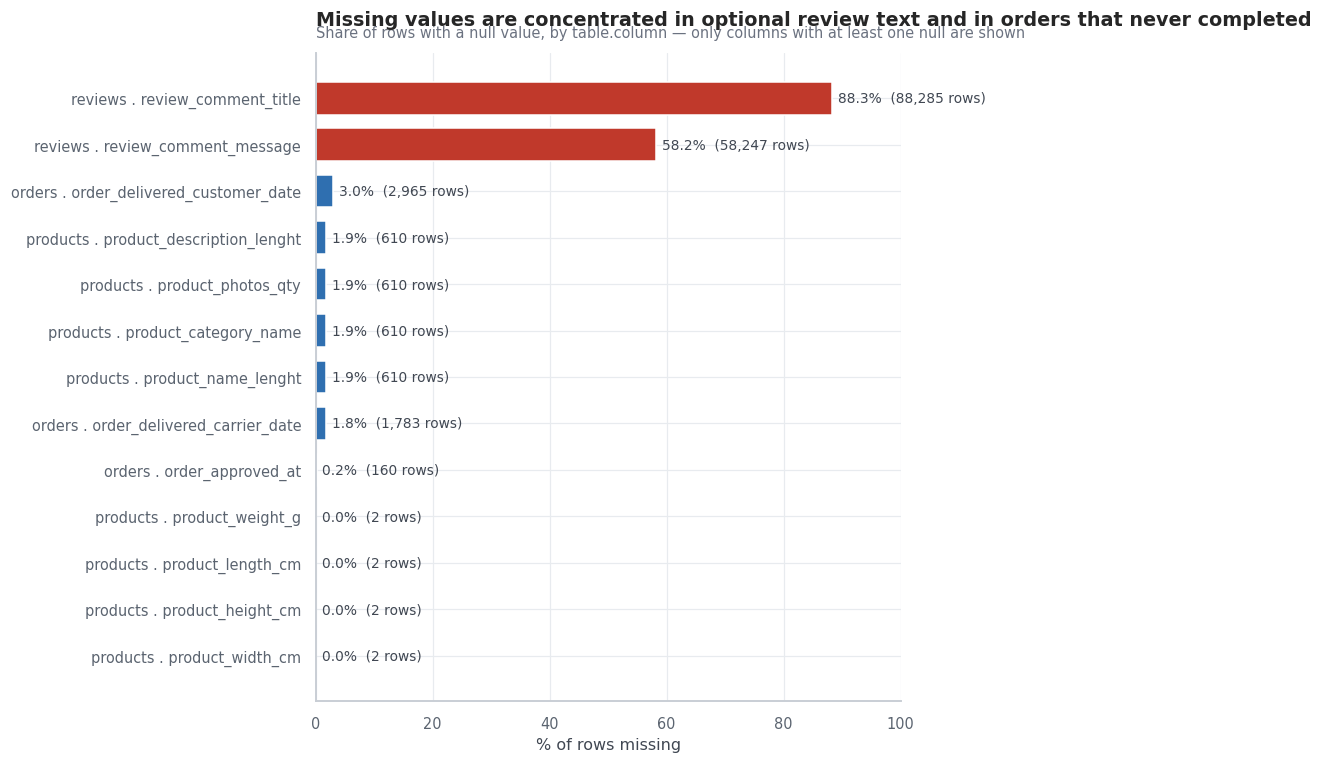

----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Three distinct kinds of missingness are visible, and they need different treatment.

Structural missingness: review_comment_title (~88%) and review_comment_message (~58%)
are optional survey fields. These are not defects — most customers rate without writing.
They must never be imputed; text analysis simply runs on the subset that has text.

Process missingness: order_delivered_customer_date (~3%), order_delivered_carrier_date
(~1.8%) and order_approved_at (~0.2%) are missing because those orders never completed
the fulfilment flow (cancelled, unavailable, still in transit at the export date). These
rows must be excluded from delivery-timing analysis rather than filled, because filling
them would invent deliveries that never happened.

Catalogue gaps: ~610 products lack a category and listing

In [8]:
# --- Missingness at a glance -------------------------------------------------
miss = (pd.concat([p.assign(table=k) for k, p in profiles.items()])
          .query("missing > 0")
          .sort_values("missing_%", ascending=True))

fig, ax = plt.subplots(figsize=(9, 0.42 * len(miss) + 1.6))
labels = miss["table"] + " . " + miss["column"]
colors = [C["red"] if v > 50 else C["amber"] if v > 5 else C["blue"] for v in miss["missing_%"]]
ax.barh(labels, miss["missing_%"], color=colors, height=.7)
for y, (v, n) in enumerate(zip(miss["missing_%"], miss["missing"])):
    ax.text(v + 1, y, f"{v:.1f}%  ({n:,} rows)", va="center", fontsize=9, color="#404752")
ax.set_xlim(0, 100)
styled(ax, "Missing values are concentrated in optional review text and in orders that never completed",
       "Share of rows with a null value, by table.column — only columns with at least one null are shown",
       "% of rows missing", "")
finish(fig, "01_missingness")

note("""
Three distinct kinds of missingness are visible, and they need different treatment.

Structural missingness: review_comment_title (~88%) and review_comment_message (~58%) are
optional survey fields. These are not defects — most customers rate without writing. They must
never be imputed; text analysis simply runs on the subset that has text.

Process missingness: order_delivered_customer_date (~3%), order_delivered_carrier_date (~1.8%)
and order_approved_at (~0.2%) are missing because those orders never completed the fulfilment
flow (cancelled, unavailable, still in transit at the export date). These rows must be excluded
from delivery-timing analysis rather than filled, because filling them would invent deliveries
that never happened.

Catalogue gaps: ~610 products lack a category and listing attributes, and 2 lack weight and
dimensions. These are small enough to label 'unknown' and keep, so that their orders still
count towards revenue and satisfaction totals.
""", "tech")

note("""
Almost none of the blank cells in this dataset are errors. Most are simply questions the
customer chose not to answer (the written review), or steps that never happened for that order
(a delivery date for an order that was cancelled). So the rule followed here is: never invent a
value. Leave the blanks blank, and be explicit about which orders each analysis is based on.
""", "plain")


In [9]:
# --- Key uniqueness and grain ------------------------------------------------
key_checks = [
    ("orders",      ["order_id"],                        "1 row per order"),
    ("customers",   ["customer_id"],                     "1 row per order-level customer"),
    ("products",    ["product_id"],                      "1 row per product"),
    ("sellers",     ["seller_id"],                       "1 row per seller"),
    ("reviews",     ["review_id"],                       "1 row per review"),
    ("items",       ["order_id", "order_item_id"],       "1 row per item line"),
    ("payments",    ["order_id", "payment_sequential"],  "1 row per payment record"),
    ("translation", ["product_category_name"],           "1 row per category"),
    ("geolocation", ["geolocation_zip_code_prefix"],     "NOT unique by design"),
]

rows = []
for tbl, keys, stated in key_checks:
    df = raw[tbl]
    dup = int(df.duplicated(subset=keys).sum())
    rows.append({"table": tbl, "stated key": " + ".join(keys), "stated grain": stated,
                 "rows": len(df), "distinct keys": len(df) - dup,
                 "duplicate key rows": dup,
                 "unique?": "YES" if dup == 0 else "NO"})
keydf = pd.DataFrame(rows)
show(keydf, n=9, title="Primary-key verification")

# Grain relative to orders: how many rows per order does each child table hold?
grain = pd.DataFrame({
    "table": ["items", "payments", "reviews"],
    "rows": [len(raw["items"]), len(raw["payments"]), len(raw["reviews"])],
    "distinct orders": [raw["items"]["order_id"].nunique(),
                        raw["payments"]["order_id"].nunique(),
                        raw["reviews"]["order_id"].nunique()],
})
grain["rows per order"] = grain["rows"] / grain["distinct orders"]
grain["orders with >1 row"] = [
    int((raw["items"].groupby("order_id").size() > 1).sum()),
    int((raw["payments"].groupby("order_id").size() > 1).sum()),
    int((raw["reviews"].groupby("order_id").size() > 1).sum()),
]
show(grain, n=5, title="Grain of each child table relative to orders")

dup_reviews = int(raw["reviews"].duplicated(subset=["review_id"]).sum())
multi_review_orders = int((raw["reviews"].groupby("order_id").size() > 1).sum())
geo_prefixes = raw["geolocation"]["geolocation_zip_code_prefix"].nunique()

note(f"""
The stated keys hold for orders, customers, products, sellers, items and payments. Two results
need acting on.

Reviews: {dup_reviews:,} rows repeat a review_id and {multi_review_orders:,} orders carry more than
one review row. Joining reviews to orders without resolving this would duplicate those orders and
double-count their revenue.

Geolocation: {len(raw['geolocation']):,} rows cover only {geo_prefixes:,} distinct zip prefixes
(~{len(raw['geolocation'])/geo_prefixes:.0f} readings each). Joining it directly to customers or
sellers would explode the table roughly 50-fold. It must be aggregated to one row per prefix first.
""", "tech")

note(f"""
Two tables cannot be joined as-is. A few orders have more than one review attached, and the
map table has about {len(raw['geolocation'])/geo_prefixes:.0f} location readings for every postcode.
If they were merged straight in, the same order would be counted several times over and every
revenue number would come out too big. Both are collapsed to one row each in the cleaning step
below.
""", "plain")



Primary-key verification
------------------------


,table,stated key,stated grain,rows,distinct keys,duplicate key rows,unique?
0,orders,order_id,1 row per order,99441,99441,0,YES
1,customers,customer_id,1 row per order-level customer,99441,99441,0,YES
2,products,product_id,1 row per product,32951,32951,0,YES
3,sellers,seller_id,1 row per seller,3095,3095,0,YES
4,reviews,review_id,1 row per review,100000,99173,827,NO
5,items,order_id + order_item_id,1 row per item line,112650,112650,0,YES
6,payments,order_id + payment_sequential,1 row per payment record,103886,103886,0,YES
7,translation,product_category_name,1 row per category,71,71,0,YES
8,geolocation,geolocation_zip_code_prefix,NOT unique by design,1000163,19015,981148,NO



Grain of each child table relative to orders
--------------------------------------------


,table,rows,distinct orders,rows per order,orders with >1 row
0,items,112650,98666,1.142,9803
1,payments,103886,99440,1.045,2961
2,reviews,100000,99441,1.006,555


----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
The stated keys hold for orders, customers, products, sellers, items and payments. Two
results need acting on.

Reviews: 827 rows repeat a review_id and 555 orders carry more than one review row.
Joining reviews to orders without resolving this would duplicate those orders and
double-count their revenue.

Geolocation: 1,000,163 rows cover only 19,015 distinct zip prefixes (~53 readings each).
Joining it directly to customers or sellers would explode the table roughly 50-fold. It
must be aggregated to one row per prefix first.

----------------------------------------------------------------------------------------
IN PLAIN TERMS
----------------------------------------------------------------------------------------
Two tables cannot be joined as-is. A few orders have more than one review att

In [10]:
# --- Referential integrity ---------------------------------------------------
def orphan_check(child, child_key, parent, parent_key, label):
    c = set(raw[child][child_key].dropna().unique())
    p = set(raw[parent][parent_key].dropna().unique())
    orphans = c - p
    return {"relationship": label, "child rows": len(raw[child]),
            "distinct child keys": len(c), "orphan keys": len(orphans),
            "orphan %": 100 * len(orphans) / max(len(c), 1),
            "status": "clean" if not orphans else "orphans present"}

ri = pd.DataFrame([
    orphan_check("orders", "customer_id", "customers", "customer_id", "orders -> customers"),
    orphan_check("items", "order_id", "orders", "order_id", "items -> orders"),
    orphan_check("items", "product_id", "products", "product_id", "items -> products"),
    orphan_check("items", "seller_id", "sellers", "seller_id", "items -> sellers"),
    orphan_check("payments", "order_id", "orders", "order_id", "payments -> orders"),
    orphan_check("reviews", "order_id", "orders", "order_id", "reviews -> orders"),
])
show(ri, n=10, title="Referential integrity — do all foreign keys resolve?")

# Coverage in the other direction: which orders LACK a child record?
orders_all = set(raw["orders"]["order_id"])
cov = pd.DataFrame([
    {"child table": "items",    "orders without a row": len(orders_all - set(raw["items"]["order_id"]))},
    {"child table": "payments", "orders without a row": len(orders_all - set(raw["payments"]["order_id"]))},
    {"child table": "reviews",  "orders without a row": len(orders_all - set(raw["reviews"]["order_id"]))},
])
cov["% of orders"] = 100 * cov["orders without a row"] / len(orders_all)
show(cov, n=5, title="Coverage — orders with no matching child record")

note(f"""
Every foreign key resolves: there are no orphan items, payments or reviews. The gaps run the
other way. {cov.loc[0,'orders without a row']:,} orders have no item line
({cov.loc[0,'% of orders']:.1f}%), {cov.loc[1,'orders without a row']:,} have no payment record and
{cov.loc[2,'orders without a row']:,} have no review. These are overwhelmingly cancelled or
unavailable orders that never generated a shipment, a charge or a survey. Left joins from orders
are therefore the correct join direction throughout: an order with no review keeps its row and
gets a null score, instead of silently disappearing from the order counts.
""", "tech")



Referential integrity — do all foreign keys resolve?
----------------------------------------------------


,relationship,child rows,distinct child keys,orphan keys,orphan %,status
0,orders -> customers,99441,99441,0,0.000,clean
1,items -> orders,112650,98666,0,0.000,clean
2,items -> products,112650,32951,0,0.000,clean
3,items -> sellers,112650,3095,0,0.000,clean
4,payments -> orders,103886,99440,0,0.000,clean
5,reviews -> orders,100000,99441,0,0.000,clean



Coverage — orders with no matching child record
-----------------------------------------------


,child table,orders without a row,% of orders
0,items,775,0.779
1,payments,1,0.001
2,reviews,0,0.000


----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Every foreign key resolves: there are no orphan items, payments or reviews. The gaps run
the other way. 775 orders have no item line (0.8%), 1 have no payment record and 0 have
no review. These are overwhelmingly cancelled or unavailable orders that never generated
a shipment, a charge or a survey. Left joins from orders are therefore the correct join
direction throughout: an order with no review keeps its row and gets a null score,
instead of silently disappearing from the order counts.




Order status mix and timestamp completeness within each status
--------------------------------------------------------------


,orders,share,has approved %,has to carrier %,has delivered ts %
order_status,,,,,
delivered,96478,0.970,99.985,99.998,99.992
shipped,1107,0.011,100.000,100.000,0.000
canceled,625,0.006,77.440,12.000,0.960
unavailable,609,0.006,100.000,0.000,0.000
invoiced,314,0.003,100.000,0.000,0.000
processing,301,0.003,100.000,0.000,0.000
created,5,0.000,0.000,0.000,0.000
approved,2,0.000,100.000,0.000,0.000


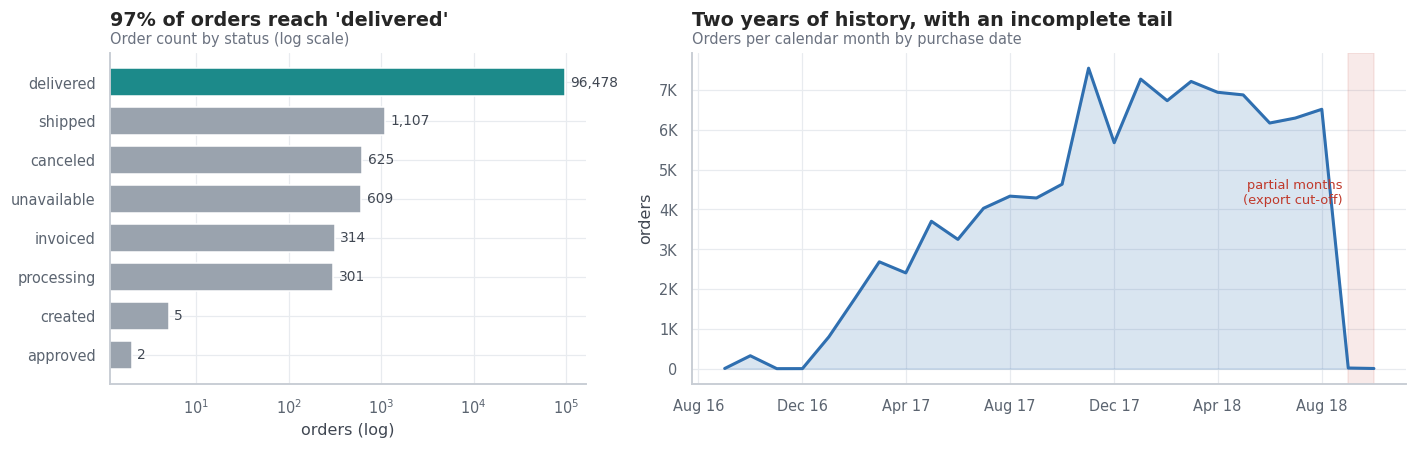

----------------------------------------------------------------------------------------
CAUTION
----------------------------------------------------------------------------------------
Purchases run from 04 Sep 2016 to 17 Oct 2018. 97.0% of orders reach 'delivered'; the
remaining 3.0% are shipped, cancelled, unavailable, invoiced, processing, created or
approved, and by construction most of them have no customer delivery date.

Two boundary effects must be handled before any trend is read.

The 2016 tail is not a real trading period: the first months contain a handful of
orders, so percentage growth computed off that base is meaningless.

The final months are truncated. The export stops on 17 Oct 2018, and orders placed close
to that date had not yet been delivered or reviewed. Any decline in the last visible
points is an artefact of the cut-off, not a business trend. Section 6 therefore marks
the last months explicitly and reads the trend on complete months only.

-------------------

In [11]:
# --- Order status and time coverage ------------------------------------------
o = raw["orders"].copy()
o["order_purchase_timestamp"] = pd.to_datetime(o["order_purchase_timestamp"], errors="coerce")

status = (o["order_status"].value_counts().rename_axis("order_status")
            .to_frame("orders").assign(share=lambda d: d["orders"]/len(o)))
# How complete are the delivery timestamps within each status?
for col, short in [("order_approved_at", "approved"),
                   ("order_delivered_carrier_date", "to carrier"),
                   ("order_delivered_customer_date", "delivered ts")]:
    status[f"has {short} %"] = (o.groupby("order_status")[col].apply(lambda s: 100*s.notna().mean()))
show(status, n=10, title="Order status mix and timestamp completeness within each status")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.5]})

ax = axes[0]
s2 = status.sort_values("orders")
cols = [C["teal"] if i == "delivered" else C["grey"] for i in s2.index]
ax.barh(s2.index, s2["orders"], color=cols, height=.72)
ax.set_xscale("log")
for y, v in enumerate(s2["orders"]):
    ax.text(v*1.15, y, f"{v:,}", va="center", fontsize=9, color="#404752")
styled(ax, f"{status.loc['delivered','share']:.0%} of orders reach 'delivered'",
       "Order count by status (log scale)", "orders (log)", "")

ax = axes[1]
monthly = o.set_index("order_purchase_timestamp").resample("MS").size()
ax.fill_between(monthly.index, monthly.values, color=C["blue"], alpha=.18)
ax.plot(monthly.index, monthly.values, color=C["blue"], lw=2)
ax.axvspan(pd.Timestamp("2018-09-01"), monthly.index.max(), color=C["red"], alpha=.10)
ax.text(pd.Timestamp("2018-08-25"), monthly.max()*.55,
        "partial months\n(export cut-off)", fontsize=8.5, color=C["red"], ha="right")
ax.yaxis.set_major_formatter(K_FMT)
styled(ax, "Two years of history, with an incomplete tail",
       "Orders per calendar month by purchase date", "", "orders")
date_axis(axes[1], months=4)
finish(fig, "02_status_coverage")

first, last = o["order_purchase_timestamp"].min(), o["order_purchase_timestamp"].max()
delivered_share = status.loc["delivered", "share"]
record("date_range", f"{first:%d %b %Y} to {last:%d %b %Y}")
record("delivered_share", delivered_share, "share of orders")

note(f"""
Purchases run from {first:%d %b %Y} to {last:%d %b %Y}. {delivered_share:.1%} of orders reach
'delivered'; the remaining {1-delivered_share:.1%} are shipped, cancelled, unavailable, invoiced,
processing, created or approved, and by construction most of them have no customer delivery date.

Two boundary effects must be handled before any trend is read.

The 2016 tail is not a real trading period: the first months contain a handful of orders, so
percentage growth computed off that base is meaningless.

The final months are truncated. The export stops on {last:%d %b %Y}, and orders placed close to
that date had not yet been delivered or reviewed. Any decline in the last visible points is an
artefact of the cut-off, not a business trend. Section 6 therefore marks the last months
explicitly and reads the trend on complete months only.
""", "caution")

note(f"""
The data covers about two years of trading. Nearly all orders were delivered. Two things at the
edges of the timeline can mislead: there is almost no business at the very start, and the very
end is cut off mid-stream so the last months look artificially weak. Both are flagged on every
time chart in this notebook rather than quietly smoothed away.
""", "plain")


## 3. Data cleaning

Every decision below is recorded in a **cleaning log** with the number of rows affected and the reason. Nothing is dropped silently.

**The five decisions that matter:**

| Decision | Choice made | Why |
|---|---|---|
| Non-delivered orders | Kept in volume/revenue analysis, **excluded from delivery-timing analysis** | They have no delivery date by construction; deleting them would understate volume, keeping them would fabricate delivery times |
| Duplicate reviews | Collapse to **one review per order** — the most recent answer | Otherwise those orders are double-counted in every join |
| Geolocation | Aggregate to **one row per zip prefix** (median lat/lng, Brazil bounding box) | 1.0M rows over ~19k prefixes would multiply joins ~50x; median resists GPS outliers |
| Missing product category | Label `"unknown"`, keep the rows | 610 products still carry real revenue and real reviews |
| Missing product weight/dims | Leave as null | Only 2 products; imputing would be noise |


In [12]:
CLEAN_LOG = []
def log_step(step, affected, reason):
    CLEAN_LOG.append({"step": step, "rows affected": affected, "reason": reason})
    print(f"  [clean] {step:<46} {affected:>10,}  — {reason}")

print("Cleaning log")
print("=" * 100)

# ---------------------------------------------------------------- 3.1 orders
orders = raw["orders"].copy()
DATE_COLS = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for c in DATE_COLS:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")
log_step("orders: parsed 5 timestamp columns", len(orders), "string -> datetime64")

# Logical-consistency screen: dates that cannot physically be true.
bad_seq = (
    (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]) |
    (orders["order_approved_at"] < orders["order_purchase_timestamp"]) |
    (orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"])
)
n_bad_seq = int(bad_seq.fillna(False).sum())
orders["flag_timestamp_inconsistent"] = bad_seq.fillna(False)
log_step("orders: flagged impossible timestamp order", n_bad_seq,
         "delivered-before-purchased etc.; flagged, not deleted")

# ------------------------------------------------------------- 3.2 customers
customers = raw["customers"].copy()
customers["customer_zip_code_prefix"] = (customers["customer_zip_code_prefix"]
                                         .astype(str).str.strip().str.zfill(5))
customers["customer_city"] = customers["customer_city"].str.strip().str.title()
customers["customer_state"] = customers["customer_state"].str.strip().str.upper()
log_step("customers: normalised zip / city / state", len(customers),
         "zero-padded 5-char zip prefix; consistent casing")

# --------------------------------------------------------------- 3.3 sellers
sellers = raw["sellers"].copy()
sellers["seller_zip_code_prefix"] = (sellers["seller_zip_code_prefix"]
                                     .astype(str).str.strip().str.zfill(5))
sellers["seller_city"] = sellers["seller_city"].str.strip().str.title()
sellers["seller_state"] = sellers["seller_state"].str.strip().str.upper()
log_step("sellers: normalised zip / city / state", len(sellers), "same treatment as customers")

# -------------------------------------------------------------- 3.4 products
products = raw["products"].copy()
# The source file ships two misspelled column names ('lenght'); fix them.
products = products.rename(columns={"product_name_lenght": "product_name_length",
                                    "product_description_lenght": "product_description_length"})
translation = raw["translation"].copy()
translation.columns = [c.strip() for c in translation.columns]
products = products.merge(translation, on="product_category_name", how="left")

n_no_cat = int(products["product_category_name"].isna().sum())
n_no_trans = int(products["product_category_name_english"].isna().sum()) - n_no_cat
products["category"] = (products["product_category_name_english"]
                        .fillna(products["product_category_name"])
                        .fillna("unknown")
                        .str.replace("_", " ").str.strip())
log_step("products: merged English category names", len(products),
         f"{n_no_cat} products had no category, {max(n_no_trans,0)} had no translation -> 'unknown'")

products["product_volume_cm3"] = (products["product_length_cm"] *
                                  products["product_height_cm"] *
                                  products["product_width_cm"])
# Volumetric ("dimensional") weight is the industry standard freight driver:
# carriers bill on max(actual weight, volume / 6000) for cm/kg.
products["product_volumetric_weight_g"] = products["product_volume_cm3"] / 6000 * 1000
products["product_billable_weight_g"] = products[["product_weight_g",
                                                  "product_volumetric_weight_g"]].max(axis=1)
log_step("products: derived volume and volumetric weight", len(products),
         "freight is billed on max(actual, volumetric) weight")

# ---------------------------------------------------------------- 3.5 items
items = raw["items"].copy()
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")
n_free_freight = int((items["freight_value"] == 0).sum())
n_zero_price = int((items["price"] <= 0).sum())
log_step("items: parsed shipping_limit_date", len(items), "string -> datetime64")
log_step("items: zero-freight lines noted", n_free_freight, "free shipping promotions, kept")
log_step("items: non-positive price lines noted", n_zero_price, "kept and flagged in anomalies")

# ------------------------------------------------------------- 3.6 payments
payments = raw["payments"].copy()
n_notdef = int((payments["payment_type"] == "not_defined").sum())
n_zero_pay = int((payments["payment_value"] <= 0).sum())
payments["payment_type"] = payments["payment_type"].str.replace("_", " ").str.strip()
log_step("payments: tidied payment_type labels", len(payments), "credit_card -> credit card")
log_step("payments: 'not_defined' records noted", n_notdef, "kept, excluded from type comparisons")
log_step("payments: zero-value records noted", n_zero_pay, "usually fully voucher-covered orders")

# -------------------------------------------------------------- 3.7 reviews
reviews = raw["reviews"].copy()
for c in ["review_creation_date", "review_answer_timestamp"]:
    reviews[c] = pd.to_datetime(reviews[c], errors="coerce")

before = len(reviews)
# Collapse to one review per ORDER: keep the most recently answered survey.
reviews = (reviews.sort_values("review_answer_timestamp")
                  .drop_duplicates(subset="order_id", keep="last")
                  .reset_index(drop=True))
log_step("reviews: collapsed to one review per order", before - len(reviews),
         "kept the most recent answer; prevents double-counting on join")

reviews["has_comment"] = reviews["review_comment_message"].notna() & \
                         (reviews["review_comment_message"].astype(str).str.strip() != "")
reviews["has_title"] = reviews["review_comment_title"].notna()
reviews["comment_length"] = reviews["review_comment_message"].astype(str).str.len().where(
    reviews["has_comment"], np.nan)
reviews["review_response_hours"] = (
    (reviews["review_answer_timestamp"] - reviews["review_creation_date"]).dt.total_seconds() / 3600)
log_step("reviews: derived text flags and response time", len(reviews),
         "has_comment / comment_length / hours to answer the survey")

# ---------------------------------------------------------- 3.8 geolocation
geo = raw["geolocation"].copy()
geo["geolocation_zip_code_prefix"] = (geo["geolocation_zip_code_prefix"]
                                      .astype(str).str.strip().str.zfill(5))
# Brazil's mainland bounding box — drops GPS readings that fall outside the country.
BR_BOX = dict(lat_min=-33.75, lat_max=5.28, lng_min=-73.99, lng_max=-34.79)
in_box = (geo["geolocation_lat"].between(BR_BOX["lat_min"], BR_BOX["lat_max"]) &
          geo["geolocation_lng"].between(BR_BOX["lng_min"], BR_BOX["lng_max"]))
n_out = int((~in_box).sum())
geo = geo[in_box]
log_step("geolocation: dropped points outside Brazil", n_out, "impossible lat/lng readings")

geo_zip = (geo.groupby("geolocation_zip_code_prefix")
             .agg(lat=("geolocation_lat", "median"),
                  lng=("geolocation_lng", "median"),
                  geo_city=("geolocation_city", lambda s: s.mode().iat[0] if len(s.mode()) else np.nan),
                  geo_state=("geolocation_state", lambda s: s.mode().iat[0] if len(s.mode()) else np.nan),
                  n_readings=("geolocation_lat", "size"))
             .reset_index())
log_step("geolocation: aggregated to one row per zip prefix",
         len(raw["geolocation"]) - len(geo_zip),
         f"1.0M readings -> {len(geo_zip):,} prefixes; median resists GPS outliers")

print("=" * 100)
show(pd.DataFrame(CLEAN_LOG), n=20, title="Cleaning log (complete)")


Cleaning log
  [clean] orders: parsed 5 timestamp columns                 99,441  — string -> datetime64
  [clean] orders: flagged impossible timestamp order             23  — delivered-before-purchased etc.; flagged, not deleted


  [clean] customers: normalised zip / city / state           99,441  — zero-padded 5-char zip prefix; consistent casing
  [clean] sellers: normalised zip / city / state              3,095  — same treatment as customers
  [clean] products: merged English category names            32,951  — 610 products had no category, 13 had no translation -> 'unknown'
  [clean] products: derived volume and volumetric weight     32,951  — freight is billed on max(actual, volumetric) weight
  [clean] items: parsed shipping_limit_date                 112,650  — string -> datetime64
  [clean] items: zero-freight lines noted                       383  — free shipping promotions, kept
  [clean] items: non-positive price lines noted                   0  — kept and flagged in anomalies
  [clean] payments: tidied payment_type labels              103,886  — credit_card -> credit card
  [clean] payments: 'not_defined' records noted                   3  — kept, excluded from type comparisons
  [clean] payments: z

  [clean] reviews: collapsed to one review per order            559  — kept the most recent answer; prevents double-counting on join
  [clean] reviews: derived text flags and response time      99,441  — has_comment / comment_length / hours to answer the survey


  [clean] geolocation: dropped points outside Brazil             42  — impossible lat/lng readings


  [clean] geolocation: aggregated to one row per zip prefix    981,153  — 1.0M readings -> 19,010 prefixes; median resists GPS outliers

Cleaning log (complete)
-----------------------


,step,rows affected,reason
0,orders: parsed 5 timestamp columns,99441,string -> datetime64
1,orders: flagged impossible timestamp order,23,"delivered-before-purchased etc.; flagged, not ..."
2,customers: normalised zip / city / state,99441,zero-padded 5-char zip prefix; consistent casing
3,sellers: normalised zip / city / state,3095,same treatment as customers
4,products: merged English category names,32951,"610 products had no category, 13 had no transl..."
5,products: derived volume and volumetric weight,32951,"freight is billed on max(actual, volumetric) w..."
6,items: parsed shipping_limit_date,112650,string -> datetime64
7,items: zero-freight lines noted,383,"free shipping promotions, kept"
8,items: non-positive price lines noted,0,kept and flagged in anomalies
9,payments: tidied payment_type labels,103886,credit_card -> credit card


,step,rows affected,reason
0,orders: parsed 5 timestamp columns,99441,string -> datetime64
1,orders: flagged impossible timestamp order,23,"delivered-before-purchased etc.; flagged, not ..."
2,customers: normalised zip / city / state,99441,zero-padded 5-char zip prefix; consistent casing
3,sellers: normalised zip / city / state,3095,same treatment as customers
4,products: merged English category names,32951,"610 products had no category, 13 had no transl..."
5,products: derived volume and volumetric weight,32951,"freight is billed on max(actual, volumetric) w..."
6,items: parsed shipping_limit_date,112650,string -> datetime64
7,items: zero-freight lines noted,383,"free shipping promotions, kept"
8,items: non-positive price lines noted,0,kept and flagged in anomalies
9,payments: tidied payment_type labels,103886,credit_card -> credit card


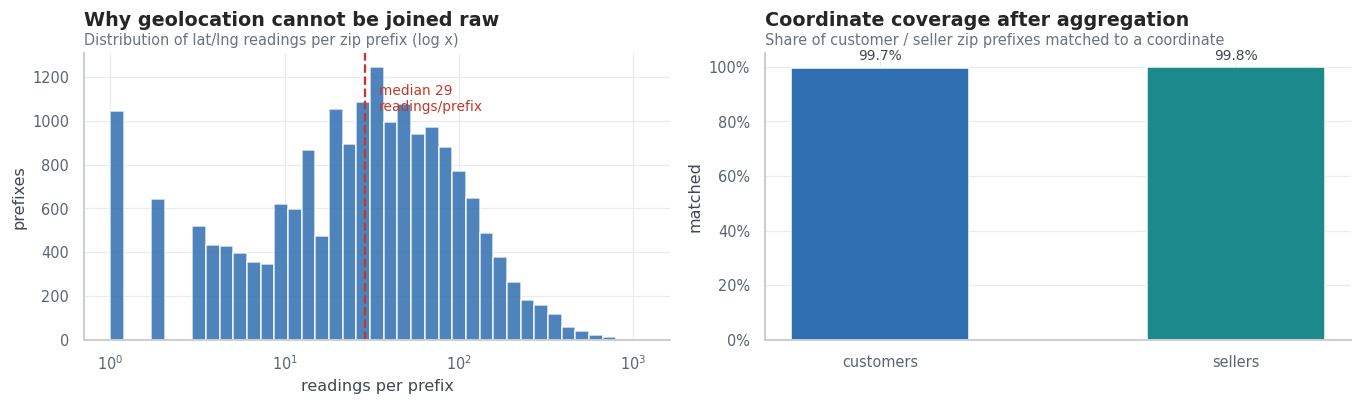

----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
The raw geolocation table holds a median of 29 readings per zip prefix (max 1,146).
Aggregating to the median latitude and longitude gives 19,010 clean prefix rows that
match 99.7% of customer zips and 99.8% of seller zips. The median rather than the mean
is used because single mis-recorded GPS points would drag a mean across the country,
while the median ignores them.



In [13]:
# --- Did the aggregation actually fix the join blow-up? ----------------------
naive = raw["geolocation"].groupby("geolocation_zip_code_prefix").size()
cust_match = customers["customer_zip_code_prefix"].isin(geo_zip["geolocation_zip_code_prefix"]).mean()
sell_match = sellers["seller_zip_code_prefix"].isin(geo_zip["geolocation_zip_code_prefix"]).mean()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax = axes[0]
ax.hist(naive.values, bins=np.logspace(0, np.log10(naive.max()), 40), color=C["blue"], alpha=.85)
ax.set_xscale("log")
ax.axvline(naive.median(), color=C["red"], ls="--", lw=1.5)
ax.text(naive.median()*1.2, ax.get_ylim()[1]*.8, f"median {naive.median():.0f}\nreadings/prefix",
        color=C["red"], fontsize=9)
styled(ax, "Why geolocation cannot be joined raw",
       "Distribution of lat/lng readings per zip prefix (log x)", "readings per prefix", "prefixes")

ax = axes[1]
bars = ax.bar(["customers", "sellers"], [cust_match, sell_match],
              color=[C["blue"], C["teal"]], width=.5)
ax.set_ylim(0, 1.05); ax.yaxis.set_major_formatter(PCT_FMT)
bar_labels(ax, "{:.1%}")
styled(ax, "Coordinate coverage after aggregation",
       "Share of customer / seller zip prefixes matched to a coordinate", "", "matched")
finish(fig, "03_geo_aggregation")

record("geo_prefixes", len(geo_zip), "zip prefixes")
note(f"""
The raw geolocation table holds a median of {naive.median():.0f} readings per zip prefix (max
{naive.max():,}). Aggregating to the median latitude and longitude gives {len(geo_zip):,} clean
prefix rows that match {cust_match:.1%} of customer zips and {sell_match:.1%} of seller zips.
The median rather than the mean is used because single mis-recorded GPS points would drag a mean
across the country, while the median ignores them.
""", "tech")


## 4. Feature engineering — building the analysis master table

Everything so far has been at different grains: item lines, payment records, review rows. Analysis needs **one row per order** with the customer, the money, the logistics and the satisfaction outcome side by side.

**The features that carry the analysis:**

| Feature | Definition | Why it exists |
|---|---|---|
| `delivery_days` | delivered date − purchase date | How long the customer actually waited |
| `estimated_days` | promised date − purchase date | The promise made at checkout |
| `delivery_delay_days` | delivered − **promised** (positive = late) | The gap between promise and reality — the customer's actual reference point |
| `is_late` | delay > 0 | The single clearest satisfaction lever |
| `seller_delay_days` | carrier handover − shipping limit | Splits blame between seller and carrier |
| `order_value` | Σ item price | Revenue |
| `freight_ratio` | freight ÷ item value | Shipping burden as felt by the customer |
| `distance_km` | haversine(seller zip, customer zip) | The physical driver behind both freight and delay |
| `is_low_review` | score ≤ 2 | The outcome variable of the root-cause section |


In [14]:
# ---------------------------------------------- 4.1 items -> one row per order
item_agg = items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    n_distinct_products=("product_id", "nunique"),
    n_sellers=("seller_id", "nunique"),
    order_value=("price", "sum"),
    freight_total=("freight_value", "sum"),
    max_item_price=("price", "max"),
    shipping_limit=("shipping_limit_date", "max"),
).reset_index()

# The 'primary' item = the most expensive line. It defines the order's headline
# category and seller, which is the standard convention for mixed baskets.
primary = (items.sort_values(["order_id", "price"], ascending=[True, False])
                .drop_duplicates("order_id")
                .loc[:, ["order_id", "product_id", "seller_id", "price", "freight_value"]]
                .rename(columns={"product_id": "primary_product_id",
                                 "seller_id": "primary_seller_id",
                                 "price": "primary_item_price",
                                 "freight_value": "primary_freight"}))
item_agg = item_agg.merge(primary, on="order_id", how="left")

# ------------------------------------------- 4.2 payments -> one row per order
pay_agg = payments.groupby("order_id").agg(
    total_paid=("payment_value", "sum"),
    n_payment_records=("payment_sequential", "count"),
    n_payment_types=("payment_type", "nunique"),
    max_installments=("payment_installments", "max"),
).reset_index()

# Dominant payment type = the method that covered the largest share of the bill.
dom_pay = (payments.sort_values(["order_id", "payment_value"], ascending=[True, False])
                   .drop_duplicates("order_id")
                   .loc[:, ["order_id", "payment_type", "payment_installments"]]
                   .rename(columns={"payment_type": "payment_type",
                                    "payment_installments": "installments"}))
pay_agg = pay_agg.merge(dom_pay, on="order_id", how="left")

# ------------------------------------------------------------- 4.3 assemble
master = (orders
          .merge(customers, on="customer_id", how="left")
          .merge(item_agg, on="order_id", how="left")
          .merge(pay_agg, on="order_id", how="left")
          .merge(reviews[["order_id", "review_score", "has_comment", "has_title",
                          "comment_length", "review_creation_date",
                          "review_answer_timestamp", "review_response_hours"]],
                 on="order_id", how="left"))

# Product / category attributes of the primary item
master = master.merge(
    products[["product_id", "category", "product_weight_g", "product_billable_weight_g",
              "product_volume_cm3", "product_photos_qty", "product_description_length"]]
        .rename(columns={"product_id": "primary_product_id"}),
    on="primary_product_id", how="left")

# Seller attributes of the primary seller
master = master.merge(
    sellers.rename(columns={"seller_id": "primary_seller_id"}),
    on="primary_seller_id", how="left")

master["category"] = master["category"].fillna("unknown")
print(f"master table: {master.shape[0]:,} rows x {master.shape[1]} columns "
      f"(orders in source: {len(orders):,})")
assert len(master) == len(orders), "join changed the grain — investigate before continuing"
print("Grain check passed: exactly one row per order.")


master table: 99,441 rows x 46 columns (orders in source: 99,441)
Grain check passed: exactly one row per order.


In [15]:
# ------------------------------------------------- 4.4 time & logistics features
DAY = np.timedelta64(1, "D")

master["delivery_days"] = (master["order_delivered_customer_date"] -
                           master["order_purchase_timestamp"]) / DAY
master["estimated_days"] = (master["order_estimated_delivery_date"] -
                            master["order_purchase_timestamp"]) / DAY
master["delivery_delay_days"] = (master["order_delivered_customer_date"] -
                                 master["order_estimated_delivery_date"]) / DAY
master["approval_hours"] = (master["order_approved_at"] -
                            master["order_purchase_timestamp"]).dt.total_seconds() / 3600
master["carrier_handover_days"] = (master["order_delivered_carrier_date"] -
                                   master["order_purchase_timestamp"]) / DAY
master["carrier_transit_days"] = (master["order_delivered_customer_date"] -
                                  master["order_delivered_carrier_date"]) / DAY
# Seller lateness: handed to the carrier after the contractual shipping limit
master["seller_delay_days"] = (master["order_delivered_carrier_date"] -
                               master["shipping_limit"]) / DAY

master["is_delivered"] = master["order_status"].eq("delivered")
master["has_delivery_ts"] = master["order_delivered_customer_date"].notna()
master["is_late"] = np.where(master["delivery_delay_days"].notna(),
                             master["delivery_delay_days"] > 0, np.nan)
master["is_very_late"] = np.where(master["delivery_delay_days"].notna(),
                                  master["delivery_delay_days"] > 7, np.nan)
master["seller_shipped_late"] = np.where(master["seller_delay_days"].notna(),
                                         master["seller_delay_days"] > 0, np.nan)

# Buckets used repeatedly in the delivery analysis
DELAY_BINS = [-np.inf, -20, -10, -5, 0, 3, 7, 15, 30, np.inf]
DELAY_LABELS = ["20+ d early", "10-20 d early", "5-10 d early", "0-5 d early",
                "0-3 d late", "3-7 d late", "7-15 d late", "15-30 d late", "30+ d late"]
master["delay_bucket"] = pd.cut(master["delivery_delay_days"], DELAY_BINS, labels=DELAY_LABELS)

SPEED_BINS = [0, 3, 7, 14, 21, 30, np.inf]
SPEED_LABELS = ["0-3 d", "4-7 d", "8-14 d", "15-21 d", "22-30 d", "30+ d"]
master["speed_bucket"] = pd.cut(master["delivery_days"], SPEED_BINS, labels=SPEED_LABELS)

# ------------------------------------------------------ 4.5 money features
master["freight_ratio"] = master["freight_total"] / master["order_value"].replace(0, np.nan)
master["total_order_value"] = master["order_value"] + master["freight_total"]
master["is_multi_item"] = master["n_items"].fillna(0) > 1
master["is_multi_seller"] = master["n_sellers"].fillna(0) > 1
master["is_installment"] = master["installments"].fillna(1) > 1
INST_BINS = [0, 1, 2, 3, 6, 10, np.inf]
INST_LABELS = ["1 (upfront)", "2", "3", "4-6", "7-10", "10+"]
master["installment_bucket"] = pd.cut(master["installments"], INST_BINS, labels=INST_LABELS)

# ---------------------------------------------------- 4.6 satisfaction features
master["is_low_review"] = np.where(master["review_score"].notna(),
                                   master["review_score"] <= 2, np.nan)
master["is_top_review"] = np.where(master["review_score"].notna(),
                                   master["review_score"] == 5, np.nan)

# ------------------------------------------------------ 4.7 calendar features
master["purchase_month"] = master["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
master["purchase_year"] = master["order_purchase_timestamp"].dt.year
master["purchase_dow"] = master["order_purchase_timestamp"].dt.dayofweek
master["purchase_dow_name"] = master["order_purchase_timestamp"].dt.day_name().str[:3]
master["purchase_hour"] = master["order_purchase_timestamp"].dt.hour

# --------------------------------------- 4.8 geography: seller-customer distance
cust_geo = geo_zip.rename(columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix",
                                   "lat": "cust_lat", "lng": "cust_lng"})[
    ["customer_zip_code_prefix", "cust_lat", "cust_lng"]]
sell_geo = geo_zip.rename(columns={"geolocation_zip_code_prefix": "seller_zip_code_prefix",
                                   "lat": "sell_lat", "lng": "sell_lng"})[
    ["seller_zip_code_prefix", "sell_lat", "sell_lng"]]
master = master.merge(cust_geo, on="customer_zip_code_prefix", how="left")
master = master.merge(sell_geo, on="seller_zip_code_prefix", how="left")
master["distance_km"] = haversine(master["sell_lat"], master["sell_lng"],
                                  master["cust_lat"], master["cust_lng"])
master["same_state"] = master["customer_state"].eq(master["seller_state"])
DIST_BINS = [0, 50, 200, 500, 1000, 2000, np.inf]
DIST_LABELS = ["<50 km", "50-200", "200-500", "500-1000", "1000-2000", "2000+ km"]
master["distance_bucket"] = pd.cut(master["distance_km"], DIST_BINS, labels=DIST_LABELS)

# Brazilian macro-regions — five regions read far better than 27 states on a chart.
REGION = {
    "North": ["AC","AP","AM","PA","RO","RR","TO"],
    "Northeast": ["AL","BA","CE","MA","PB","PE","PI","RN","SE"],
    "Central-West": ["DF","GO","MT","MS"],
    "Southeast": ["ES","MG","RJ","SP"],
    "South": ["PR","RS","SC"],
}
STATE2REGION = {s: r for r, ss in REGION.items() for s in ss}
master["customer_region"] = master["customer_state"].map(STATE2REGION).fillna("unknown")
master["seller_region"] = master["seller_state"].map(STATE2REGION).fillna("unknown")

print(f"master table now {master.shape[1]} columns")
print(f"  delivery timings available for : {master['delivery_days'].notna().sum():,} orders")
print(f"  review score available for     : {master['review_score'].notna().sum():,} orders")
print(f"  distance computed for          : {master['distance_km'].notna().sum():,} orders "
      f"({master['distance_km'].notna().mean():.1%})")


master table now 82 columns
  delivery timings available for : 96,476 orders
  review score available for     : 99,441 orders
  distance computed for          : 98,176 orders (98.7%)


In [16]:
# --- Analysis subsets --------------------------------------------------------
# Defined once, named clearly, and reused everywhere so that every figure states
# exactly which population it describes.

DEL   = master[master["is_delivered"] & master["has_delivery_ts"]].copy()   # delivery analysis
REV   = master[master["review_score"].notna()].copy()                        # satisfaction analysis
DELREV= master[master["is_delivered"] & master["has_delivery_ts"] &
               master["review_score"].notna()].copy()                        # both
COMPLETE_END = pd.Timestamp("2018-08-31")   # last month treated as complete
TREND = master[master["order_purchase_timestamp"] <= COMPLETE_END].copy()

subsets = pd.DataFrame([
    {"subset": "master",  "rows": len(master),
     "definition": "every order in the dataset"},
    {"subset": "DEL",     "rows": len(DEL),
     "definition": "delivered orders with a real delivery timestamp"},
    {"subset": "REV",     "rows": len(REV),
     "definition": "orders with a review score"},
    {"subset": "DELREV",  "rows": len(DELREV),
     "definition": "delivered AND reviewed — the core satisfaction population"},
    {"subset": "TREND",   "rows": len(TREND),
     "definition": f"orders purchased on or before {COMPLETE_END:%b %Y} (complete months only)"},
])
subsets["% of orders"] = 100 * subsets["rows"] / len(master)
show(subsets, n=6, title="Analysis populations used in this notebook")

record("n_orders", len(master), "orders")
record("n_delivered", len(DEL), "delivered orders")
record("n_reviews", len(REV), "reviewed orders")

note(f"""
Five populations are used throughout, and every chart names the one it is built on.

DEL ({len(DEL):,} orders) is the delivery population: delivered status AND a real customer
delivery timestamp. Requiring both is deliberate — a small number of orders carry a status that
disagrees with their timestamps, and delivery statistics computed on either condition alone would
differ slightly and be hard to reconcile later.

DELREV ({len(DELREV):,} orders, {len(DELREV)/len(master):.1%} of all orders) is the population for
every satisfaction claim in this notebook, because it is the only population where both the
experience and the customer's verdict are observed.

TREND excludes September and October 2018 for time-series work, since those months are truncated
by the export cut-off and would otherwise look like a collapse in demand.
""", "method")



Analysis populations used in this notebook
------------------------------------------


,subset,rows,definition,% of orders
0,master,99441,every order in the dataset,100.000
1,DEL,96470,delivered orders with a real delivery timestamp,97.012
2,REV,99441,orders with a review score,100.000
3,DELREV,96470,delivered AND reviewed — the core satisfaction...,97.012
4,TREND,99420,orders purchased on or before Aug 2018 (comple...,99.979


----------------------------------------------------------------------------------------
METHOD
----------------------------------------------------------------------------------------
Five populations are used throughout, and every chart names the one it is built on.

DEL (96,470 orders) is the delivery population: delivered status AND a real customer
delivery timestamp. Requiring both is deliberate — a small number of orders carry a
status that disagrees with their timestamps, and delivery statistics computed on either
condition alone would differ slightly and be hard to reconcile later.

DELREV (96,470 orders, 97.0% of all orders) is the population for every satisfaction
claim in this notebook, because it is the only population where both the experience and
the customer's verdict are observed.

TREND excludes September and October 2018 for time-series work, since those months are
truncated by the export cut-off and would otherwise look like a collapse in demand.



## 5. Exploratory data analysis — the baseline

Before answering any of the core questions, this section establishes **what "normal" looks like** on this marketplace: the headline KPIs, and the shape of every variable the later analysis leans on.

Reading distributions first is not ceremony. It determines which statistics are legitimate: order value and freight are heavily right-skewed (so medians and non-parametric tests are used), and review scores are extremely bimodal (so an "average of 4.09" hides the fact that most orders are a 5 and a hard core are a 1).


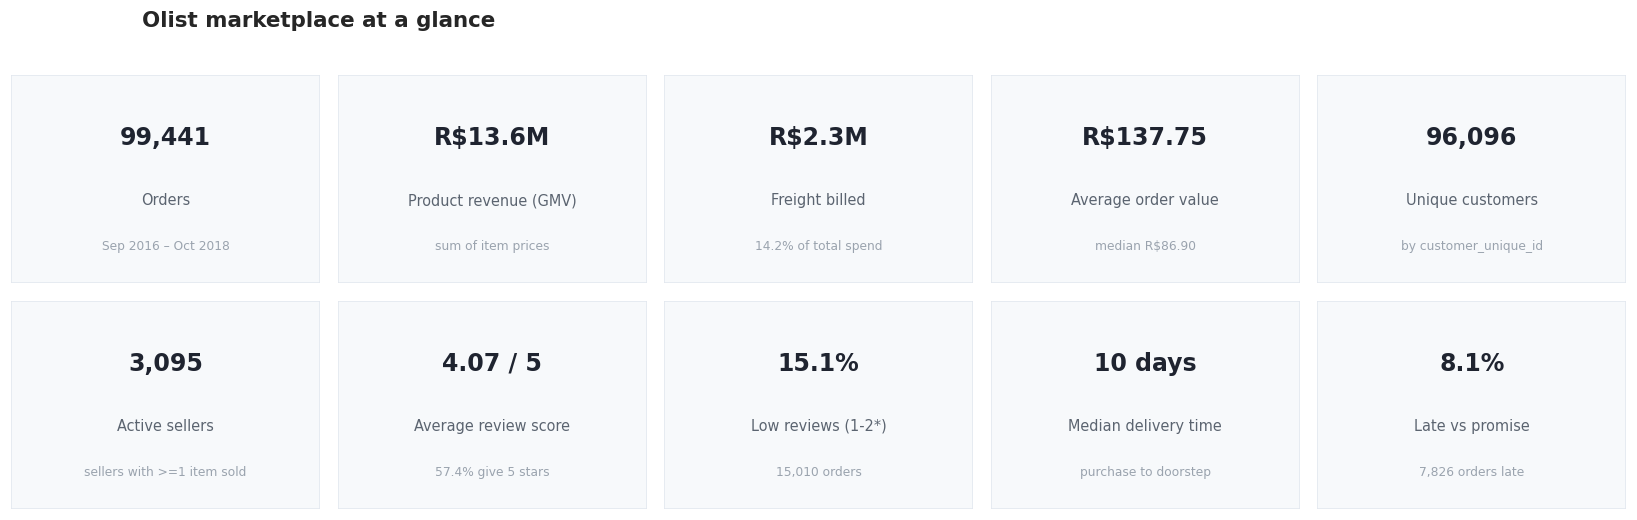

----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Roughly R$13.6M of product revenue over two years across 99,441 orders, from 96,096
distinct people and 3,095 active sellers. The average order is R$137.75 but the median
is R$86.90 — a classic long-tailed marketplace where a minority of large baskets pull
the mean well above the typical purchase, which is why medians are used for anything
describing a 'typical' order.

Freight is 14.2% of everything customers pay. On a marketplace shipping across a country
the size of Brazil that is a material share, and it makes freight a first-class variable
in the analysis rather than a footnote.

Satisfaction averages 4.07/5, but the average is the least informative statistic here:
57.4% of orders are 5 stars and 15.1% are 1-2 stars. The interesting question is not
what moves the mean, it is what creates

In [17]:
# --- KPI baseline ------------------------------------------------------------
gmv          = master["order_value"].sum()
freight_sum  = master["freight_total"].sum()
aov          = master["order_value"].mean()
median_ov    = master["order_value"].median()
n_customers  = customers["customer_unique_id"].nunique()
n_sellers_a  = items["seller_id"].nunique()
avg_score    = REV["review_score"].mean()
low_rate     = REV["is_low_review"].mean()
top_rate     = REV["is_top_review"].mean()
med_delivery = DEL["delivery_days"].median()
late_rate    = DEL["is_late"].mean()
freight_share= freight_sum / (gmv + freight_sum)

kpis = [
    ("Orders",                f"{len(master):,}",              "Sep 2016 – Oct 2018"),
    ("Product revenue (GMV)", brl(gmv),                        "sum of item prices"),
    ("Freight billed",        brl(freight_sum),                f"{freight_share:.1%} of total spend"),
    ("Average order value",   f"R${aov:,.2f}",                 f"median R${median_ov:,.2f}"),
    ("Unique customers",      f"{n_customers:,}",              "by customer_unique_id"),
    ("Active sellers",        f"{n_sellers_a:,}",              "sellers with >=1 item sold"),
    ("Average review score",  f"{avg_score:.2f} / 5",          f"{top_rate:.1%} give 5 stars"),
    ("Low reviews (1-2*)",    f"{low_rate:.1%}",               f"{int(REV['is_low_review'].sum()):,} orders"),
    ("Median delivery time",  f"{med_delivery:.0f} days",      "purchase to doorstep"),
    ("Late vs promise",       f"{late_rate:.1%}",              f"{int(DEL['is_late'].sum()):,} orders late"),
]

fig, axes = plt.subplots(2, 5, figsize=(15, 4.6))
for ax, (label, value, sub) in zip(axes.ravel(), kpis):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                               facecolor="#f7f9fb", edgecolor="#e2e7ee", lw=1))
    ax.text(.5, .70, value, ha="center", va="center", fontsize=15.5,
            fontweight="bold", color=C["ink"], transform=ax.transAxes)
    ax.text(.5, .40, label, ha="center", va="center", fontsize=9.5,
            color="#5b6470", transform=ax.transAxes)
    ax.text(.5, .18, sub, ha="center", va="center", fontsize=8,
            color="#9aa3ae", transform=ax.transAxes)
fig.suptitle("Olist marketplace at a glance", fontsize=14, fontweight="bold", x=.09, ha="left", y=1.02)
finish(fig, "04_kpi_cards")

for k, v in [("gmv", gmv), ("aov", aov), ("avg_review", avg_score), ("low_review_rate", low_rate),
             ("late_rate", late_rate), ("median_delivery_days", med_delivery),
             ("unique_customers", n_customers), ("active_sellers", n_sellers_a),
             ("freight_share", freight_share)]:
    record(k, v)

note(f"""
Roughly {brl(gmv)} of product revenue over two years across {len(master):,} orders, from
{n_customers:,} distinct people and {n_sellers_a:,} active sellers. The average order is
R${aov:,.2f} but the median is R${median_ov:,.2f} — a classic long-tailed marketplace where a
minority of large baskets pull the mean well above the typical purchase, which is why medians are
used for anything describing a 'typical' order.

Freight is {freight_share:.1%} of everything customers pay. On a marketplace shipping across a
country the size of Brazil that is a material share, and it makes freight a first-class variable
in the analysis rather than a footnote.

Satisfaction averages {avg_score:.2f}/5, but the average is the least informative statistic here:
{top_rate:.1%} of orders are 5 stars and {low_rate:.1%} are 1-2 stars. The interesting question is
not what moves the mean, it is what creates the 1-2 star tail.
""", "tech")

note(f"""
Over two years Olist handled about {len(master)/1000:.0f} thousand orders worth roughly
{brl(gmv)}, from about {n_customers/1000:.0f} thousand different shoppers. Most people are happy:
about {top_rate:.0%} give the full five stars. But roughly one order in seven gets a bad rating,
and shipping costs make up about {freight_share:.0%} of what customers pay. Those two facts are
what the rest of this notebook digs into.
""", "plain")


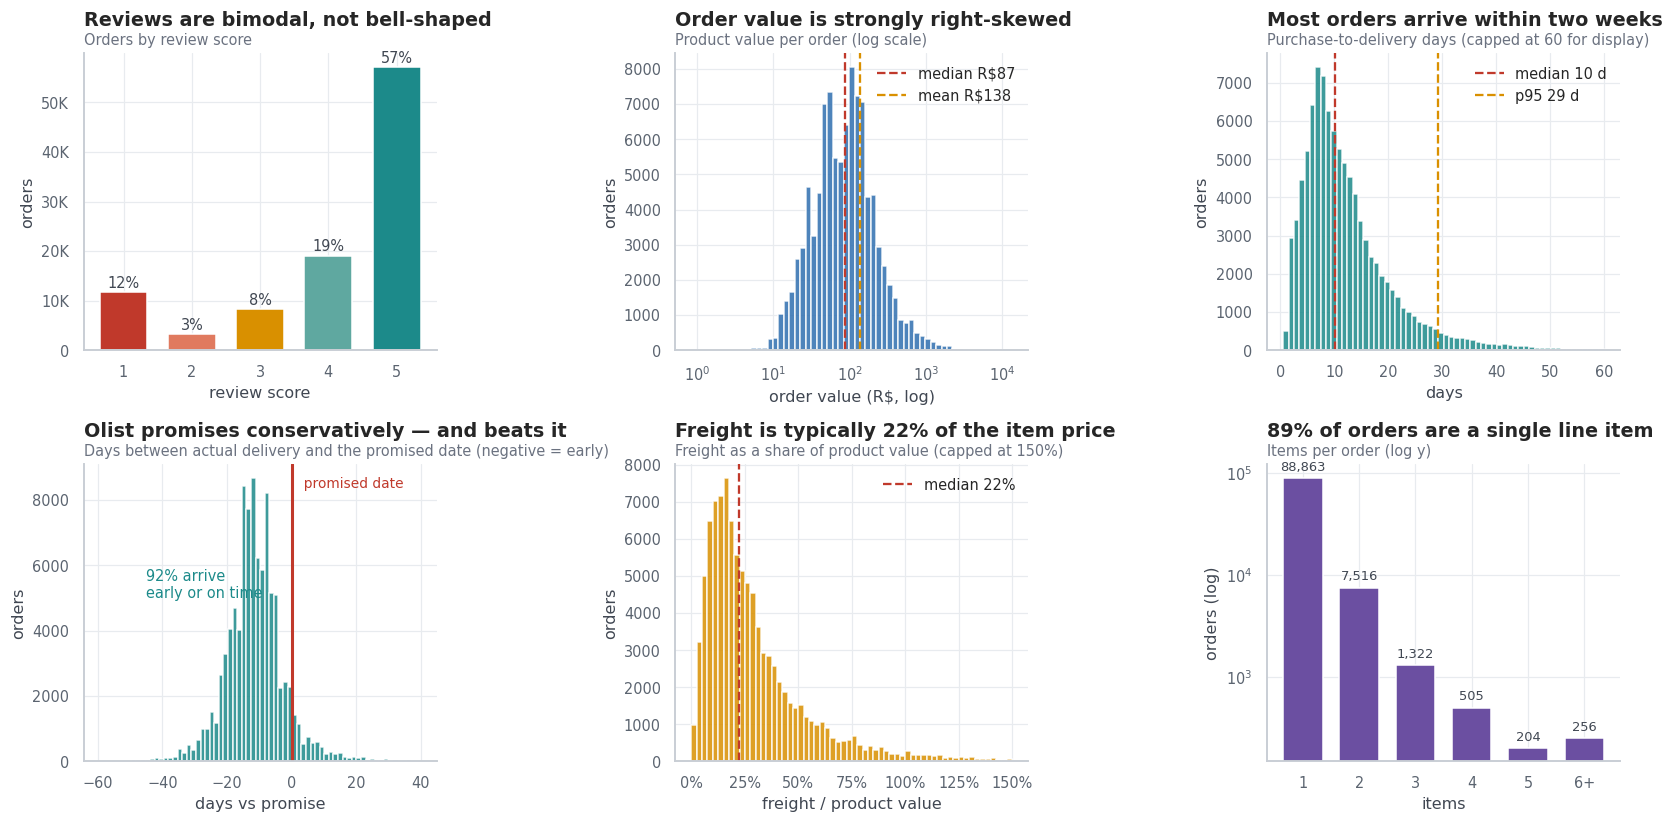

----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Four shapes drive the methodology used from here on.

Review scores are bimodal (57% at 5 stars, 12% at 1 star). Means are reported for
continuity but every important comparison is also run on the proportion of 1-2 star
orders, which is the business-relevant tail.

Order value spans four orders of magnitude with mean well above median, so medians and
rank-based tests (Mann-Whitney, Kruskal-Wallis, Spearman) are used rather than t-tests
and Pearson.

Delivery vs promise is centred well to the left of zero: 91.9% of orders arrive on or
before the promised date, median -12 days early. Olist's estimated dates are
deliberately conservative. That matters for interpretation — being 'late' here means
missing an already-padded promise, which is why it hits satisfaction so hard.

Freight is a median 22

In [18]:
# --- Distributions of the key variables --------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 7.6))

# 1. Review score
ax = axes[0, 0]
vc = REV["review_score"].value_counts().sort_index()
ax.bar(vc.index, vc.values, color=[SCORE_COLORS[i] for i in vc.index], width=.7)
for x, y in zip(vc.index, vc.values):
    ax.text(x, y + 900, f"{y/vc.sum():.0%}", ha="center", fontsize=9.5, color="#404752")
ax.yaxis.set_major_formatter(K_FMT); ax.set_xticks([1, 2, 3, 4, 5])
styled(ax, "Reviews are bimodal, not bell-shaped",
       "Orders by review score", "review score", "orders")

# 2. Order value (log)
ax = axes[0, 1]
ov = master["order_value"].dropna()
ov = ov[ov > 0]
ax.hist(ov, bins=np.logspace(np.log10(ov.min()), np.log10(ov.max()), 60),
        color=C["blue"], alpha=.85)
ax.set_xscale("log")
ax.axvline(ov.median(), color=C["red"], ls="--", lw=1.5,
           label=f"median R${ov.median():,.0f}")
ax.axvline(ov.mean(), color=C["amber"], ls="--", lw=1.5, label=f"mean R${ov.mean():,.0f}")
ax.legend(loc="upper right")
styled(ax, "Order value is strongly right-skewed",
       "Product value per order (log scale)", "order value (R$, log)", "orders")

# 3. Delivery days
ax = axes[0, 2]
dd = DEL["delivery_days"].dropna()
ax.hist(dd[dd <= 60], bins=60, color=C["teal"], alpha=.85)
ax.axvline(dd.median(), color=C["red"], ls="--", lw=1.5, label=f"median {dd.median():.0f} d")
ax.axvline(dd.quantile(.95), color=C["amber"], ls="--", lw=1.5,
           label=f"p95 {dd.quantile(.95):.0f} d")
ax.legend()
styled(ax, "Most orders arrive within two weeks",
       "Purchase-to-delivery days (capped at 60 for display)", "days", "orders")

# 4. Delivery vs promise
ax = axes[1, 0]
dl = DEL["delivery_delay_days"].dropna()
ax.hist(dl[dl.between(-60, 40)], bins=70,
        color=[C["teal"]], alpha=.85)
ax.axvline(0, color=C["red"], lw=2)
ax.text(1, ax.get_ylim()[1]*.92, "  promised date", color=C["red"], fontsize=9)
ax.text(-45, ax.get_ylim()[1]*.55,
        f"{(dl<=0).mean():.0%} arrive\nearly or on time", color=C["teal"], fontsize=9.5)
styled(ax, "Olist promises conservatively — and beats it",
       "Days between actual delivery and the promised date (negative = early)",
       "days vs promise", "orders")

# 5. Freight ratio
ax = axes[1, 1]
fr = master["freight_ratio"].dropna()
ax.hist(fr[fr <= 1.5], bins=60, color=C["amber"], alpha=.85)
ax.axvline(fr.median(), color=C["red"], ls="--", lw=1.5, label=f"median {fr.median():.0%}")
ax.xaxis.set_major_formatter(PCT_FMT); ax.legend()
styled(ax, f"Freight is typically {fr.median():.0%} of the item price",
       "Freight as a share of product value (capped at 150%)", "freight / product value", "orders")

# 6. Items per order
ax = axes[1, 2]
ni = master["n_items"].dropna().clip(upper=6).astype(int).value_counts().sort_index()
ax.bar(ni.index, ni.values, color=C["purple"], width=.7)
ax.set_yscale("log")
ax.set_xticks(range(1, 7)); ax.set_xticklabels(["1", "2", "3", "4", "5", "6+"])
bar_labels(ax, "{:,.0f}", fontsize=8.5)
styled(ax, f"{(master['n_items']==1).mean():.0%} of orders are a single line item",
       "Items per order (log y)", "items", "orders (log)")

finish(fig, "05_distributions")

note(f"""
Four shapes drive the methodology used from here on.

Review scores are bimodal ({top_rate:.0%} at 5 stars, {(REV['review_score']==1).mean():.0%} at 1
star). Means are reported for continuity but every important comparison is also run on the
proportion of 1-2 star orders, which is the business-relevant tail.

Order value spans four orders of magnitude with mean well above median, so medians and rank-based
tests (Mann-Whitney, Kruskal-Wallis, Spearman) are used rather than t-tests and Pearson.

Delivery vs promise is centred well to the left of zero: {(dl<=0).mean():.1%} of orders arrive on
or before the promised date, median {dl.median():.0f} days early. Olist's estimated dates are
deliberately conservative. That matters for interpretation — being 'late' here means missing an
already-padded promise, which is why it hits satisfaction so hard.

Freight is a median {fr.median():.0%} of item value, and {master['is_multi_item'].mean():.1%} of
orders contain more than one line, which justifies treating the most expensive line as the order's
headline product.
""", "tech")

note(f"""
Star ratings are all-or-nothing: people either give five stars or one star, rarely anything in
between. Order values are lopsided too — a few big baskets pull the average up, so the 'typical'
order is smaller than the average suggests. And Olist's delivery promises are cautious: parcels
usually turn up about {abs(dl.median()):.0f} days early. So when an order is 'late', it has missed
a deadline that already had slack built into it, which is a genuinely bad experience.
""", "plain")


---
# Core Question 1 — Marketplace performance over time

> *How have order volume, revenue and review scores trended across the period? Do they all tell the same story?*

**Approach:** build a monthly KPI panel on complete months only, index the series so growth rates are comparable, then test the review-score trend formally rather than eyeballing the line. Finally, check whether the growth story and the satisfaction story point in the same direction.



Monthly KPI panel — last 12 complete months
-------------------------------------------


,purchase_month,orders,revenue,freight,aov,customers,avg_review,low_review_rate,late_rate,delivery_days,revenue_incl_freight,mom_orders
11,Sep 2017,4285,"624,401.690","95,997.220",147.160,4212,4.173,0.128,0.052,10.314,"720,398.910",-0.011
12,Oct 2017,4631,"664,219.430","105,092.940",145.407,4561,4.106,0.137,0.053,10.263,"769,312.370",0.081
13,Nov 2017,7544,"1,010,271.370","168,872.400",135.589,7430,3.894,0.192,0.143,12.699,"1,179,143.770",0.629
14,Dec 2017,5673,"743,914.170","119,633.060",132.275,5603,3.996,0.170,0.084,13.142,"863,547.230",-0.248
15,Jan 2018,7269,"950,030.360","157,271.530",131.583,7166,4.022,0.160,0.066,11.830,"1,107,301.890",0.281
16,Feb 2018,6728,"844,178.710","142,730.250",126.110,6569,3.808,0.214,0.160,14.266,"986,908.960",-0.074
17,Mar 2018,7211,"983,213.440","171,913.380",136.785,7115,3.734,0.233,0.214,13.368,"1,155,126.820",0.072
18,Apr 2018,6939,"996,647.750","163,050.290",143.733,6882,4.147,0.133,0.053,9.315,"1,159,698.040",-0.038
19,May 2018,6873,"996,517.680","153,264.140",145.413,6814,4.184,0.122,0.082,9.148,"1,149,781.820",-0.010
20,Jun 2018,6167,"865,124.310","157,552.800",140.442,6128,4.270,0.110,0.014,7.958,"1,022,677.110",-0.103


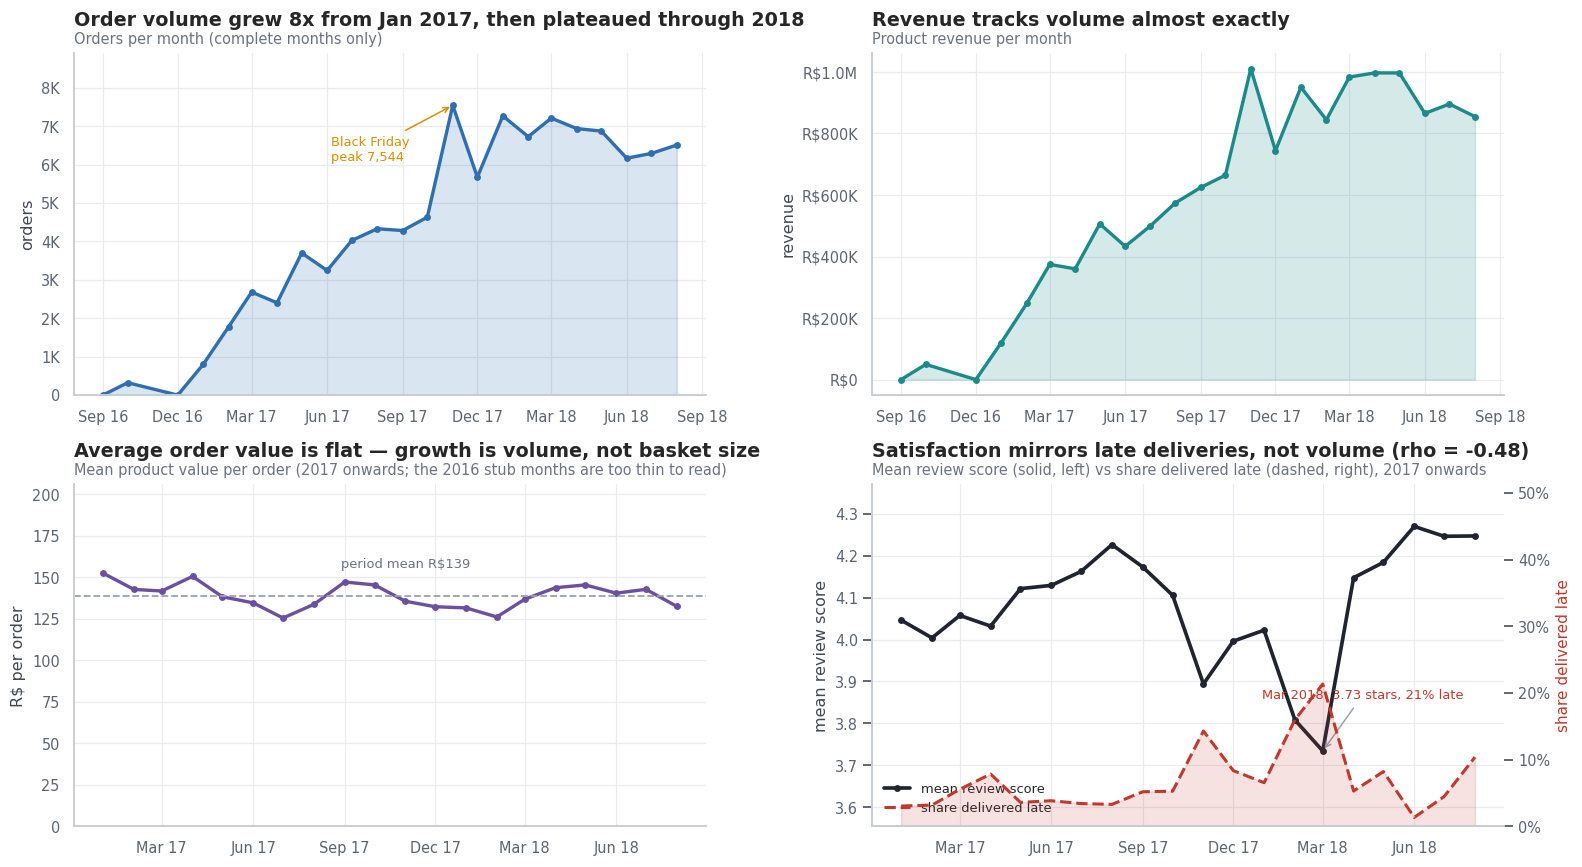

In [19]:
# --- Monthly KPI panel -------------------------------------------------------
mo = (TREND.groupby("purchase_month")
      .agg(orders=("order_id", "count"),
           revenue=("order_value", "sum"),
           freight=("freight_total", "sum"),
           aov=("order_value", "mean"),
           customers=("customer_unique_id", "nunique"),
           avg_review=("review_score", "mean"),
           low_review_rate=("is_low_review", "mean"),
           late_rate=("is_late", "mean"),
           delivery_days=("delivery_days", "median"))
      .reset_index())
mo["revenue_incl_freight"] = mo["revenue"] + mo["freight"]
mo["mom_orders"] = mo["orders"].pct_change()

# 2016 is a stub (a handful of orders); exclude it from growth statistics.
CORE = mo[mo["purchase_month"] >= "2017-01-01"].copy()

# The key monthly relationship: does satisfaction move with VOLUME or with EXECUTION?
rho_vol_score,  p_vol_score  = st.spearmanr(CORE["orders"], CORE["avg_review"])
rho_late_score, p_late_score = st.spearmanr(CORE["late_rate"], CORE["avg_review"])

show(mo.tail(12).assign(purchase_month=lambda d: d["purchase_month"].dt.strftime("%b %Y")),
     n=12, title="Monthly KPI panel — last 12 complete months")

fig, axes = plt.subplots(2, 2, figsize=(14.5, 8))

ax = axes[0, 0]
ax.fill_between(mo["purchase_month"], mo["orders"], color=C["blue"], alpha=.18)
ax.plot(mo["purchase_month"], mo["orders"], color=C["blue"], lw=2.2, marker="o", ms=3.5)
bf = mo[mo["purchase_month"] == "2017-11-01"]
if len(bf):
    ax.annotate(f"Black Friday\npeak {bf['orders'].iat[0]:,.0f}",
                xy=(bf["purchase_month"].iat[0], bf["orders"].iat[0]),
                xytext=(-80, -36), textcoords="offset points", fontsize=8.5, color=C["amber"],
                arrowprops=dict(arrowstyle="->", color=C["amber"], lw=1))
ax.set_ylim(0, mo["orders"].max() * 1.18)
ax.yaxis.set_major_formatter(K_FMT)
styled(ax, f"Order volume grew {mo['orders'].iloc[-1]/CORE['orders'].iloc[0]:.0f}x from Jan 2017, then plateaued through 2018",
       "Orders per month (complete months only)", "", "orders")

ax = axes[0, 1]
ax.fill_between(mo["purchase_month"], mo["revenue"], color=C["teal"], alpha=.18)
ax.plot(mo["purchase_month"], mo["revenue"], color=C["teal"], lw=2.2, marker="o", ms=3.5)
ax.yaxis.set_major_formatter(BRL_FMT)
styled(ax, "Revenue tracks volume almost exactly",
       "Product revenue per month", "", "revenue")

ax = axes[1, 0]
ax.plot(CORE["purchase_month"], CORE["aov"], color=C["purple"], lw=2.2, marker="o", ms=3.5)
ax.axhline(CORE["aov"].mean(), color=C["grey"], ls="--", lw=1.2)
ax.text(CORE["purchase_month"].iloc[len(CORE)//2], CORE["aov"].mean()*1.12,
        f"period mean R${CORE['aov'].mean():,.0f}", fontsize=8.5, color="#6b7280", ha="center")
ax.set_ylim(0, CORE["aov"].max()*1.35)
styled(ax, "Average order value is flat — growth is volume, not basket size",
       "Mean product value per order (2017 onwards; the 2016 stub months are too thin to read)",
       "", "R$ per order")

ax = axes[1, 1]
ax.plot(CORE["purchase_month"], CORE["avg_review"], color=C["ink"], lw=2.4, marker="o", ms=3.5,
        label="mean review score", zorder=3)
ax2 = ax.twinx()
ax2.fill_between(CORE["purchase_month"], CORE["late_rate"], color=C["red"], alpha=.14)
ax2.plot(CORE["purchase_month"], CORE["late_rate"], color=C["red"], lw=2, ls="--",
         label="share delivered late")
ax2.set_ylabel("share delivered late", color=C["red"], fontsize=10)
ax2.yaxis.set_major_formatter(PCT_FMT); ax2.grid(False)
ax2.set_ylim(0, CORE["late_rate"].max()*2.4)
ax.set_ylim(CORE["avg_review"].min()-.18, CORE["avg_review"].max()+.10)
worst = CORE.loc[CORE["avg_review"].idxmin()]
ax.annotate(f"{worst['purchase_month']:%b %Y}: {worst['avg_review']:.2f} stars, "
            f"{worst['late_rate']:.0%} late",
            xy=(worst["purchase_month"], worst["avg_review"]), xytext=(-40, 34),
            textcoords="offset points", fontsize=8.5, color=C["red"],
            arrowprops=dict(arrowstyle="->", color=C["grey"], lw=1))
lines = ax.get_lines()[:1] + ax2.get_lines()[:1]
ax.legend(lines, [l.get_label() for l in lines], loc="lower left", fontsize=8.5)
styled(ax, f"Satisfaction mirrors late deliveries, not volume (rho = {rho_late_score:+.2f})",
       "Mean review score (solid, left) vs share delivered late (dashed, right), 2017 onwards",
       "", "mean review score")
for a in axes.ravel():
    date_axis(a)
finish(fig, "06_q1_monthly_kpis")


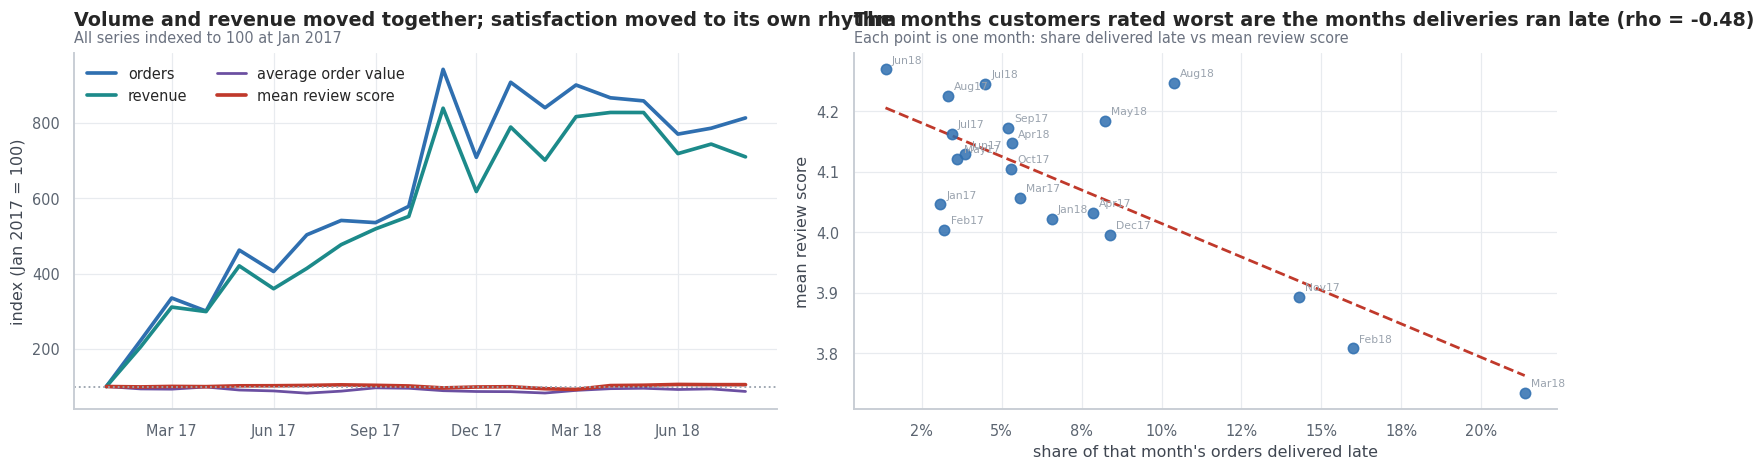

Trend tests (complete months, Jan 2017 onwards, n = 20)
----------------------------------------------------------------------------------------
  order volume vs time      : Spearman rho = +0.817, p < 0.001
  mean review vs time       : Spearman rho = +0.343, p = 0.139
  linear slope of score     : +0.0042 stars per month (95% CI -0.0069 to +0.0153), p = 0.469
  volume vs mean review     : Spearman rho = -0.075, p = 0.753
  LATE RATE vs mean review  : Spearman rho = -0.483, p = 0.031
----------------------------------------------------------------------------------------
  worst 3 months by mean score:
     Mar 2018: 3.73 stars | 21.4% late | 7,211 orders
     Feb 2018: 3.81 stars | 16.0% late | 6,728 orders
     Nov 2017: 3.89 stars | 14.3% late | 7,544 orders
  best 3 months by mean score:
     Jun 2018: 4.27 stars | 1.4% late | 6,167 orders
     Aug 2018: 4.25 stars | 10.4% late | 6,511 orders
     Jul 2018: 4.25 stars | 4.5% late | 6,292 orders
------------------------------------

In [20]:
# --- Indexed comparison + formal trend tests ---------------------------------
base = CORE.iloc[0]
idx = CORE.copy()
for col in ["orders", "revenue", "aov", "avg_review"]:
    idx[col + "_idx"] = 100 * idx[col] / base[col]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4))
ax = axes[0]
for col, lab, colr, lw in [("orders_idx", "orders", C["blue"], 2.4),
                           ("revenue_idx", "revenue", C["teal"], 2.4),
                           ("aov_idx", "average order value", C["purple"], 1.8),
                           ("avg_review_idx", "mean review score", C["red"], 2.4)]:
    ax.plot(idx["purchase_month"], idx[col], label=lab, color=colr, lw=lw)
ax.axhline(100, color=C["grey"], ls=":", lw=1.2)
ax.legend(ncol=2, loc="upper left")
styled(ax, "Volume and revenue moved together; satisfaction moved to its own rhythm",
       f"All series indexed to 100 at {base['purchase_month']:%b %Y}", "", "index (Jan 2017 = 100)")

# Formal tests on the review-score trend
x = np.arange(len(CORE))
rho, p_rho = st.spearmanr(x, CORE["avg_review"])
slope, intercept, r_, p_lin, se = st.linregress(x, CORE["avg_review"])
rho_v, p_v = st.spearmanr(x, CORE["orders"])

ax = axes[1]
ax.scatter(CORE["late_rate"], CORE["avg_review"], s=46, color=C["blue"], alpha=.85, zorder=3)
for _, r in CORE.iterrows():
    ax.annotate(f"{r['purchase_month']:%b%y}", (r["late_rate"], r["avg_review"]),
                fontsize=7, color="#9aa3ae", xytext=(4, 4), textcoords="offset points")
b, a = np.polyfit(CORE["late_rate"], CORE["avg_review"], 1)
xs = np.linspace(CORE["late_rate"].min(), CORE["late_rate"].max(), 50)
ax.plot(xs, a + b*xs, color=C["red"], ls="--", lw=1.8)
ax.xaxis.set_major_formatter(PCT_FMT)
styled(ax, f"The months customers rated worst are the months deliveries ran late "
           f"(rho = {rho_late_score:+.2f})",
       "Each point is one month: share delivered late vs mean review score",
       "share of that month's orders delivered late", "mean review score")
date_axis(axes[0])
finish(fig, "07_q1_indexed_trend")

growth_2017 = CORE[CORE["purchase_month"].dt.year == 2017]["orders"].sum()
growth_2018 = CORE[CORE["purchase_month"].dt.year == 2018]["orders"].sum()
h1_17 = CORE[CORE["purchase_month"] < "2017-07-01"]["avg_review"].mean()
h1_18 = CORE[(CORE["purchase_month"] >= "2018-01-01") &
             (CORE["purchase_month"] < "2018-07-01")]["avg_review"].mean()
first_full, last_full = CORE.iloc[0], CORE.iloc[-1]
vol_growth = last_full["orders"] / first_full["orders"]

record("volume_growth_x", vol_growth, "x", "Jan 2017 to last complete month")
record("review_trend_rho", rho, "", "Spearman rho of mean score vs month index")
record("monthly_late_vs_score_rho", rho_late_score, "", "monthly late rate vs mean score")
record("monthly_volume_vs_score_rho", rho_vol_score, "", "monthly volume vs mean score")

print(f"Trend tests (complete months, Jan 2017 onwards, n = {len(CORE)})")
rule()
print(f"  order volume vs time      : Spearman rho = {rho_v:+.3f}, p {pfmt(p_v)}")
print(f"  mean review vs time       : Spearman rho = {rho:+.3f}, p {pfmt(p_rho)}")
print(f"  linear slope of score     : {slope:+.4f} stars per month (95% CI "
      f"{slope-1.96*se:+.4f} to {slope+1.96*se:+.4f}), p {pfmt(p_lin)}")
print(f"  volume vs mean review     : Spearman rho = {rho_vol_score:+.3f}, p {pfmt(p_vol_score)}")
print(f"  LATE RATE vs mean review  : Spearman rho = {rho_late_score:+.3f}, p {pfmt(p_late_score)}")
rule()
worst3 = CORE.nsmallest(3, "avg_review")[["purchase_month", "orders", "avg_review", "late_rate"]]
best3  = CORE.nlargest(3, "avg_review")[["purchase_month", "orders", "avg_review", "late_rate"]]
print("  worst 3 months by mean score:")
for _, r in worst3.iterrows():
    print(f"     {r['purchase_month']:%b %Y}: {r['avg_review']:.2f} stars | "
          f"{r['late_rate']:.1%} late | {r['orders']:,} orders")
print("  best 3 months by mean score:")
for _, r in best3.iterrows():
    print(f"     {r['purchase_month']:%b %Y}: {r['avg_review']:.2f} stars | "
          f"{r['late_rate']:.1%} late | {r['orders']:,} orders")
rule()
print(f"  orders {first_full['purchase_month']:%b %Y}: {first_full['orders']:,} -> "
      f"{last_full['purchase_month']:%b %Y}: {last_full['orders']:,}  ({vol_growth:.1f}x)")
print(f"  mean review H1-2017: {h1_17:.3f}   H1-2018: {h1_18:.3f}   change: {h1_18-h1_17:+.3f} stars")

note(f"""
No, they do not tell the same story — but not in the way a growth-versus-quality narrative would
predict, and the difference is the most useful thing in this section.

Volume and revenue are one story. Orders grew {vol_growth:.1f}x from
{first_full['purchase_month']:%b %Y} to {last_full['purchase_month']:%b %Y} (Spearman rho =
{rho_v:+.2f}, p {pfmt(p_v)}), and revenue tracks volume almost perfectly because average order value
is flat throughout. Growth came from acquiring more orders, not from customers spending more.

Satisfaction is a different story, and it is NOT a story of decline. Over {len(CORE)} complete
months the mean review score shows no significant time trend
(Spearman rho = {rho:+.2f}, p {pfmt(p_rho)}; linear slope {slope:+.4f} stars/month, p {pfmt(p_lin)}),
and it ends the period higher than it started ({CORE['avg_review'].iloc[0]:.2f} in
{CORE['purchase_month'].iloc[0]:%b %Y} vs {CORE['avg_review'].iloc[-1]:.2f} in
{CORE['purchase_month'].iloc[-1]:%b %Y}). H1-2017 averaged {h1_17:.2f} and H1-2018 {h1_18:.2f}
({h1_18-h1_17:+.2f} stars). Scaling 8x did not systematically degrade the customer experience,
which is a creditable operational result and worth saying plainly.

What satisfaction does instead is swing, sharply, and the swings are not random. Monthly mean score
and monthly late-delivery rate correlate at rho = {rho_late_score:+.2f} (p {pfmt(p_late_score)}),
while monthly score and monthly volume correlate at only {rho_vol_score:+.2f}
(p {pfmt(p_vol_score)}). The three worst months on the chart are also the three worst months for
late delivery. The November 2017 Black Friday spike and the February-March 2018 period both show
the same signature: late rate jumps, score falls, then both recover once the backlog clears.

The correct reading is therefore that satisfaction on this marketplace is an execution variable,
not a scale variable. Volume growth does not hurt customers by itself; volume growth that outruns
the logistics operation does. That is a much more actionable conclusion, and Core Question 2 tests
the underlying mechanism at order level.

Caveat: monthly review means are computed on orders purchased in that month, so the last complete
months are slightly under-reviewed. Dropping the final month does not change any conclusion above.
""", "tech")

note(f"""
The business grew about {vol_growth:.0f} times bigger over the period, and customers kept spending
about the same per order — so growth came from more orders, not bigger ones.

Ratings did not get worse as the company grew, which is a good result. What they did was bounce
around, and they bounced in step with late deliveries: the months customers rated worst
(November 2017, February and March 2018) are exactly the months when the most parcels missed their
promised date, and ratings recovered as soon as deliveries did. Growth is not what upsets
customers; growth that gets ahead of the delivery operation is.
""", "plain")


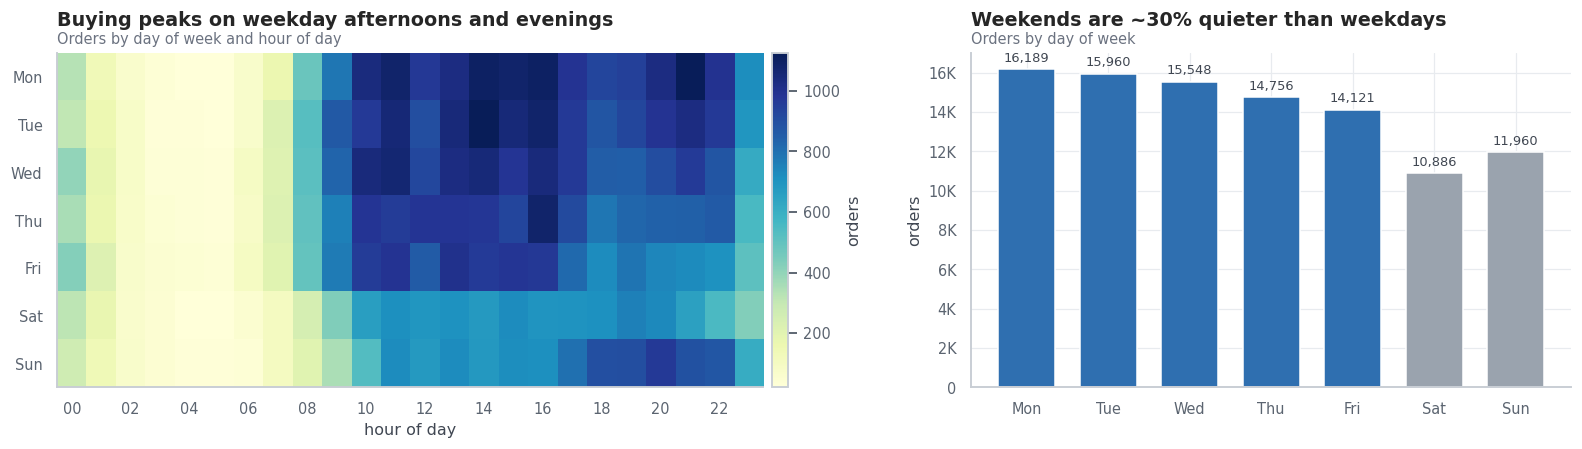

----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Demand concentrates on weekday afternoons and evenings, peaking around 16:00, with only
23.0% of orders placed at weekends. This is operationally relevant: order intake is
weekday-heavy, so any handover backlog builds inside the working week rather than being
spread evenly, and the November spike (Black Friday) lands on top of an already weekday-
loaded system.



In [21]:
# --- When do people buy? Seasonality and intra-week pattern ------------------
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.2),
                         gridspec_kw={"width_ratios": [1.4, 1]})

DOW_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot = (TREND.pivot_table(index="purchase_dow_name", columns="purchase_hour",
                           values="order_id", aggfunc="count")
              .reindex(DOW_ORDER))
ax = axes[0]
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu")
ax.set_yticks(range(7)); ax.set_yticklabels(DOW_ORDER)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels([f"{h:02d}" for h in range(0, 24, 2)])
ax.grid(False)
plt.colorbar(im, ax=ax, label="orders", pad=.01)
styled(ax, "Buying peaks on weekday afternoons and evenings",
       "Orders by day of week and hour of day", "hour of day", "")

ax = axes[1]
dow = TREND.groupby("purchase_dow_name", observed=True).agg(
    orders=("order_id", "count"), score=("review_score", "mean")).reindex(DOW_ORDER)
bars = ax.bar(dow.index, dow["orders"], color=[C["blue"]]*5 + [C["grey"]]*2, width=.7)
ax.yaxis.set_major_formatter(K_FMT)
bar_labels(ax, "{:,.0f}", fontsize=8.5)
styled(ax, "Weekends are ~30% quieter than weekdays",
       "Orders by day of week", "", "orders")
finish(fig, "08_q1_seasonality")

peak_hour = TREND["purchase_hour"].value_counts().idxmax()
wknd = TREND["purchase_dow"].isin([5, 6]).mean()
note(f"""
Demand concentrates on weekday afternoons and evenings, peaking around {peak_hour:02d}:00, with
only {wknd:.1%} of orders placed at weekends. This is operationally relevant: order intake is
weekday-heavy, so any handover backlog builds inside the working week rather than being spread
evenly, and the November spike (Black Friday) lands on top of an already weekday-loaded system.
""", "tech")


---
# Core Question 2 — Delivery performance and customer satisfaction

> *How does delivery timing (relative to the estimated delivery date) relate to review scores? Does this hold across categories and regions, or is it concentrated somewhere specific?*

**Approach — four escalating tests:**

1. **Shape** — mean score and 1-2★ rate by delay bucket, with Wilson confidence intervals.
2. **Strength** — Spearman correlation, Kruskal-Wallis with η², Mann-Whitney with Cliff's delta, χ² with Cramér's V. Effect sizes reported alongside every p-value.
3. **Separation** — does *lateness vs the promise* matter more than *raw waiting time*? These are different levers: one is an estimation problem, the other a logistics problem.
4. **Generality** — does the effect hold in every category and every region, or is it concentrated? This is what determines whether the fix is platform-wide or targeted.



Review outcome by delivery-vs-promise bucket
--------------------------------------------


,orders,mean_score,low_rate,five_rate,low_lo,low_hi
delay_bucket,,,,,,
20+ d early,13480,4.279,0.104,0.635,0.099,0.109
10-20 d early,43723,4.323,0.088,0.639,0.086,0.091
5-10 d early,22562,4.266,0.095,0.606,0.091,0.099
0-5 d early,8879,4.140,0.114,0.557,0.108,0.121
0-3 d late,2662,3.749,0.196,0.429,0.181,0.211
3-7 d late,1819,2.297,0.618,0.178,0.596,0.641
7-15 d late,1961,1.725,0.787,0.075,0.768,0.804
15-30 d late,1024,1.617,0.817,0.051,0.793,0.840
30+ d late,360,2.003,0.694,0.128,0.645,0.740


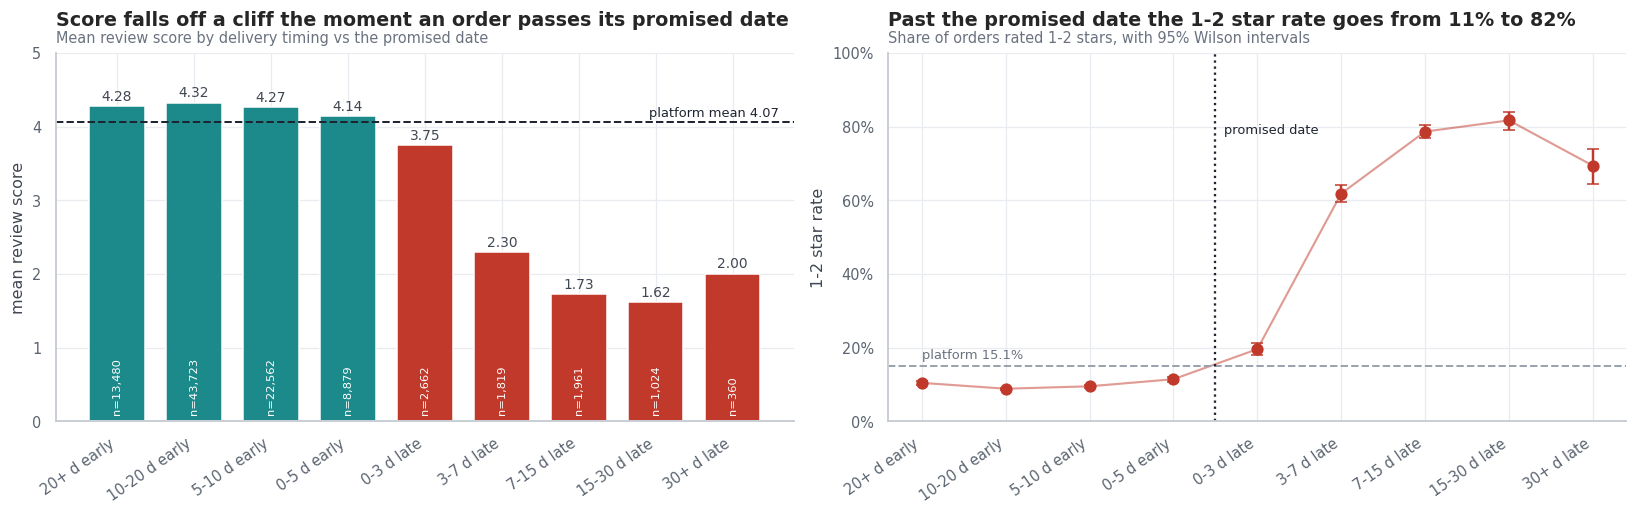

5.754948893179506

In [22]:
# --- 2.1 The shape of the relationship ---------------------------------------
d = DELREV.dropna(subset=["delay_bucket"]).copy()
by_bucket = (d.groupby("delay_bucket", observed=True)
               .agg(orders=("order_id", "count"),
                    mean_score=("review_score", "mean"),
                    low_rate=("is_low_review", "mean"),
                    five_rate=("is_top_review", "mean"))
               .reindex(DELAY_LABELS).dropna(subset=["orders"]))
ci = [wilson_ci(int(r["low_rate"]*r["orders"]), int(r["orders"])) for _, r in by_bucket.iterrows()]
by_bucket["low_lo"] = [c[0] for c in ci]; by_bucket["low_hi"] = [c[1] for c in ci]
show(by_bucket.style.format({"orders": "{:,.0f}", "mean_score": "{:.2f}",
                             "low_rate": "{:.1%}", "five_rate": "{:.1%}",
                             "low_lo": "{:.1%}", "low_hi": "{:.1%}"}).data,
     n=12, title="Review outcome by delivery-vs-promise bucket")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
xs = np.arange(len(by_bucket))
cols = [C["teal"] if "early" in i else C["red"] for i in by_bucket.index]

ax = axes[0]
ax.bar(xs, by_bucket["mean_score"], color=cols, width=.72)
ax.axhline(REV["review_score"].mean(), color=C["ink"], ls="--", lw=1.3)
ax.text(len(xs)-.4, REV["review_score"].mean()+.06,
        f"platform mean {REV['review_score'].mean():.2f}", ha="right", fontsize=8.5, color=C["ink"])
ax.set_xticks(xs); ax.set_xticklabels(by_bucket.index, rotation=35, ha="right")
ax.set_ylim(0, 5)
for x, v, n in zip(xs, by_bucket["mean_score"], by_bucket["orders"]):
    ax.text(x, v + .08, f"{v:.2f}", ha="center", fontsize=9, color="#404752")
    ax.text(x, .12, f"n={n:,.0f}", ha="center", fontsize=7.5, color="white", rotation=90)
styled(ax, "Score falls off a cliff the moment an order passes its promised date",
       "Mean review score by delivery timing vs the promised date",
       "", "mean review score")

ax = axes[1]
ax.errorbar(xs, by_bucket["low_rate"],
            yerr=[by_bucket["low_rate"]-by_bucket["low_lo"], by_bucket["low_hi"]-by_bucket["low_rate"]],
            fmt="o", color=C["red"], ms=7, lw=1.6, capsize=4)
ax.plot(xs, by_bucket["low_rate"], color=C["red"], lw=1.4, alpha=.5)
ax.axhline(REV["is_low_review"].mean(), color=C["grey"], ls="--", lw=1.3)
ax.text(0, REV["is_low_review"].mean()+.02, f"platform {REV['is_low_review'].mean():.1%}",
        fontsize=8.5, color="#6b7280")
ax.axvline(3.5, color=C["ink"], ls=":", lw=1.5)
ax.text(3.6, .78, "promised date", fontsize=8.5, color=C["ink"])
ax.set_xticks(xs); ax.set_xticklabels(by_bucket.index, rotation=35, ha="right")
ax.yaxis.set_major_formatter(PCT_FMT); ax.set_ylim(0, 1)
styled(ax, f"Past the promised date the 1-2 star rate goes from {by_bucket.loc['0-5 d early','low_rate']:.0%} to {by_bucket['low_rate'].max():.0%}",
       "Share of orders rated 1-2 stars, with 95% Wilson intervals", "", "1-2 star rate")
finish(fig, "09_q2_delay_buckets")

on_time = d[d["delivery_delay_days"] <= 0]
late    = d[d["delivery_delay_days"] > 0]
ot_low, lt_low = on_time["is_low_review"].mean(), late["is_low_review"].mean()
rr, rr_ci = risk_ratio(int(late["is_low_review"].sum()), len(late),
                       int(on_time["is_low_review"].sum()), len(on_time))
record("late_low_review_rate", lt_low); record("ontime_low_review_rate", ot_low)
record("late_risk_ratio", rr)


In [23]:
# --- 2.2 How strong is it? Four tests, each with an effect size --------------
rho_delay, p_delay = st.spearmanr(d["delivery_delay_days"], d["review_score"])
rho_speed, p_speed = st.spearmanr(d["delivery_days"], d["review_score"])

groups = [g["review_score"].values for _, g in d.groupby("delay_bucket", observed=True)]
eta2, p_kw, eta_mag = eta_squared_kw(groups)

U, p_mw = st.mannwhitneyu(late["review_score"], on_time["review_score"], alternative="less")
delta, delta_mag = cliffs_delta(late["review_score"], on_time["review_score"])

v_late, p_chi, v_mag = cramers_v(d["is_late"].astype(bool), d["is_low_review"].astype(bool))

# Is it the PROMISE or the WAIT? Lateness and waiting time are correlated, so a raw
# correlation cannot separate them. A 2x2 can: split orders by whether they waited
# longer than the median AND by whether they missed the promised date, then read the
# effect of each factor while the other is held constant.
med_days = d["delivery_days"].median()
d["_slow"] = d["delivery_days"] > med_days
d["_late"] = d["is_late"].astype(bool)
cross = (d.groupby(["_slow", "_late"], observed=True)
         .agg(orders=("order_id", "count"), low_rate=("is_low_review", "mean"),
              mean_score=("review_score", "mean"), median_wait=("delivery_days", "median")))
cross.index = pd.MultiIndex.from_tuples(
    [("slow wait" if s else "fast wait", "late" if l else "on time") for s, l in cross.index],
    names=["waiting time", "vs promise"])

def cell(slow, late):
    return cross.loc[("slow wait" if slow else "fast wait", "late" if late else "on time"), "low_rate"]

lateness_effect_fast = cell(False, True) / cell(False, False)   # late vs on-time, holding wait fast
lateness_effect_slow = cell(True, True) / cell(True, False)     # late vs on-time, holding wait slow
speed_effect_ontime  = cell(True, False) / cell(False, False)   # slow vs fast, holding on-time
speed_effect_late    = cell(True, True) / cell(False, True)     # slow vs fast, holding late
record("lateness_effect_holding_speed", lateness_effect_fast)
record("speed_effect_holding_ontime", speed_effect_ontime)

results = pd.DataFrame([
    {"test": "Spearman: delay vs score", "statistic": f"rho = {rho_delay:+.3f}",
     "p-value": pfmt(p_delay), "effect size": f"rho = {abs(rho_delay):.3f}",
     "magnitude": "moderate" if abs(rho_delay) > .2 else "small"},
    {"test": "Spearman: waiting time vs score", "statistic": f"rho = {rho_speed:+.3f}",
     "p-value": pfmt(p_speed), "effect size": f"rho = {abs(rho_speed):.3f}",
     "magnitude": "moderate" if abs(rho_speed) > .2 else "small"},
    {"test": "Kruskal-Wallis across delay buckets", "statistic": f"H over {len(groups)} groups",
     "p-value": pfmt(p_kw), "effect size": f"eta2 = {eta2:.3f}", "magnitude": eta_mag},
    {"test": "Mann-Whitney: late vs on-time", "statistic": f"U = {U:,.0f}",
     "p-value": pfmt(p_mw), "effect size": f"Cliff's d = {delta:+.3f}", "magnitude": delta_mag},
    {"test": "Chi-square: late x low-review", "statistic": "2x2 contingency",
     "p-value": pfmt(p_chi), "effect size": f"Cramer's V = {v_late:.3f}", "magnitude": v_mag},
])
show(results, n=6, title="Delivery timing vs satisfaction — tests with effect sizes")

print(f"\nLate vs on-time, head to head")
rule()
print(f"  on-time / early : {len(on_time):>7,} orders | mean score {on_time['review_score'].mean():.2f} "
      f"| 1-2 star {ot_low:.1%}")
print(f"  late            : {len(late):>7,} orders | mean score {late['review_score'].mean():.2f} "
      f"| 1-2 star {lt_low:.1%}")
print(f"  risk ratio      : late orders are {rr:.2f}x more likely to be rated 1-2 stars "
      f"(95% CI {rr_ci[0]:.2f}-{rr_ci[1]:.2f})")
rule()
print()
show(cross.style.format({"orders": "{:,.0f}", "low_rate": "{:.1%}", "mean_score": "{:.2f}",
                         "median_wait": "{:.0f}"}).data, n=4,
     title=f"Separating the promise from the wait (median wait = {med_days:.0f} days)")
print(f"  effect of BEING LATE, holding the wait short : {cell(False,False):.1%} -> "
      f"{cell(False,True):.1%}  ({lateness_effect_fast:.1f}x)")
print(f"  effect of BEING LATE, holding the wait long  : {cell(True,False):.1%} -> "
      f"{cell(True,True):.1%}  ({lateness_effect_slow:.1f}x)")
print(f"  effect of a LONG WAIT, holding it on time    : {cell(False,False):.1%} -> "
      f"{cell(True,False):.1%}  ({speed_effect_ontime:.1f}x)")
print(f"  effect of a LONG WAIT, holding it late       : {cell(False,True):.1%} -> "
      f"{cell(True,True):.1%}  ({speed_effect_late:.1f}x)")

note(f"""
The relationship is monotonic, strong for this kind of data, and it is about the promise rather
than the wait.

Magnitude. Orders delivered late are rated 1-2 stars {lt_low:.1%} of the time versus {ot_low:.1%}
when on time — a risk ratio of {rr:.2f}x (95% CI {rr_ci[0]:.2f}-{rr_ci[1]:.2f}). Mean score drops
from {on_time['review_score'].mean():.2f} to {late['review_score'].mean():.2f}. Cliff's delta is
{delta:+.3f} ({delta_mag}), and Cramer's V for late x low-review is {v_late:.3f} ({v_mag}).

Dose-response. The effect is not a threshold artefact: 0-3 days late already lifts the 1-2 star
rate to {by_bucket.loc['0-3 d late','low_rate']:.0%}, and 30+ days late reaches
{by_bucket.iloc[-1]['low_rate']:.0%}. Each additional band of lateness costs more. Confidence
intervals on every bucket are narrow enough that the ordering is not noise.

The promise matters more than the wait — but only a stratified test shows it. The raw rank
correlations are close and in fact slightly favour waiting time (delay rho = {rho_delay:+.3f} vs
wait rho = {rho_speed:+.3f}), which is exactly what you would expect from two heavily correlated,
skewed variables; neither correlation can separate them. The 2x2 can, because it holds one constant
while moving the other.

Holding the wait SHORT, missing the promise multiplies the 1-2 star rate by
{lateness_effect_fast:.1f}x ({cell(False,False):.1%} to {cell(False,True):.1%}). Holding the wait
LONG, it multiplies it by {lateness_effect_slow:.1f}x ({cell(True,False):.1%} to
{cell(True,True):.1%}). By contrast, holding delivery ON TIME, doubling the wait from a median of
{cross.loc[('fast wait','on time'),'median_wait']:.0f} to
{cross.loc[('slow wait','on time'),'median_wait']:.0f} days moves the rate only
{speed_effect_ontime:.1f}x ({cell(False,False):.1%} to {cell(True,False):.1%}).

Both variables matter — the worst cell is slow AND late ({cell(True,True):.1%}), and among late
orders a longer wait still adds {speed_effect_late:.1f}x — but lateness carries the larger
multiplier at both levels of waiting time, while waiting time is close to harmless when the promise
is kept. A long wait that was promised is largely tolerated; a shorter wait that broke its promise
is not.

Commercially this is the most important nuance in the notebook: the estimated-delivery-date logic is
itself a lever, not only the physical network. Where Olist cannot ship faster, it can promise more
honestly and recover a large part of the score.
""", "tech")

note(f"""
When a parcel arrives after the date the customer was promised, bad reviews jump from about
{ot_low:.0%} to about {lt_low:.0%} — roughly {rr:.0f} times more likely. And the further past the
promised date it goes, the worse it gets: more than 30 days late, about
{by_bucket.iloc[-1]['low_rate']:.0%} of customers leave one or two stars.

The most useful detail is that it is the broken promise that upsets people, not the waiting itself.
Comparing like with like, a parcel that took a long time but arrived when promised is largely
forgiven; a parcel that arrived quickly but still missed its date is not. So telling customers a
realistic date is worth almost as much as shipping faster.
""", "plain")



Delivery timing vs satisfaction — tests with effect sizes
---------------------------------------------------------


,test,statistic,p-value,effect size,magnitude
0,Spearman: delay vs score,rho = -0.179,< 1e-300,rho = 0.179,small
1,Spearman: waiting time vs score,rho = -0.237,< 1e-300,rho = 0.237,moderate
2,Kruskal-Wallis across delay buckets,H over 9 groups,< 1e-300,eta2 = 0.110,moderate
3,Mann-Whitney: late vs on-time,"U = 153,990,606",< 1e-300,Cliff's d = -0.553,large
4,Chi-square: late x low-review,2x2 contingency,< 1e-300,Cramer's V = 0.365,strong



Late vs on-time, head to head
----------------------------------------------------------------------------------------
  on-time / early :  88,644 orders | mean score 4.28 | 1-2 star 9.5%
  late            :   7,826 orders | mean score 2.54 | 1-2 star 54.6%
  risk ratio      : late orders are 5.75x more likely to be rated 1-2 stars (95% CI 5.59-5.92)
----------------------------------------------------------------------------------------


Separating the promise from the wait (median wait = 10 days)
------------------------------------------------------------


orders  low_rate  mean_score  median_wait
waiting time vs promise                                           
fast wait    on time      47781     0.081       4.378        6.764
             late           454     0.159       4.042        6.945
slow wait    on time      40863     0.111       4.173       14.691
             late          7372     0.570       2.453       30.071

  effect of BEING LATE, holding the wait short : 8.1% -> 15.9%  (2.0x)
  effect of BEING LATE, holding the wait long  : 11.1% -> 57.0%  (5.1x)
  effect of a LONG WAIT, holding it on time    : 8.1% -> 11.1%  (1.4x)
  effect of a LONG WAIT, holding it late       : 15.9% -> 57.0%  (3.6x)
----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
The relationship is monotonic, strong for this kind of data, and it is about the promise
rather than the wait.

Magnitude. Orders delivered late are rated 1-2 stars 54.6% of the time versus 9.5% when
on time — a risk ratio of 5.75x (95% CI 5.59-5.92). Mean score drops from 4.28 to 2.54.
Cliff's delta is -0.553 (large), and Cramer's V for late x low-review is 0.365 (strong).

Dose-response. The effect is not a threshold artefact: 0-3 days late already lifts the
1-2 star rate to 20%, and 30+ days late reaches 69%.

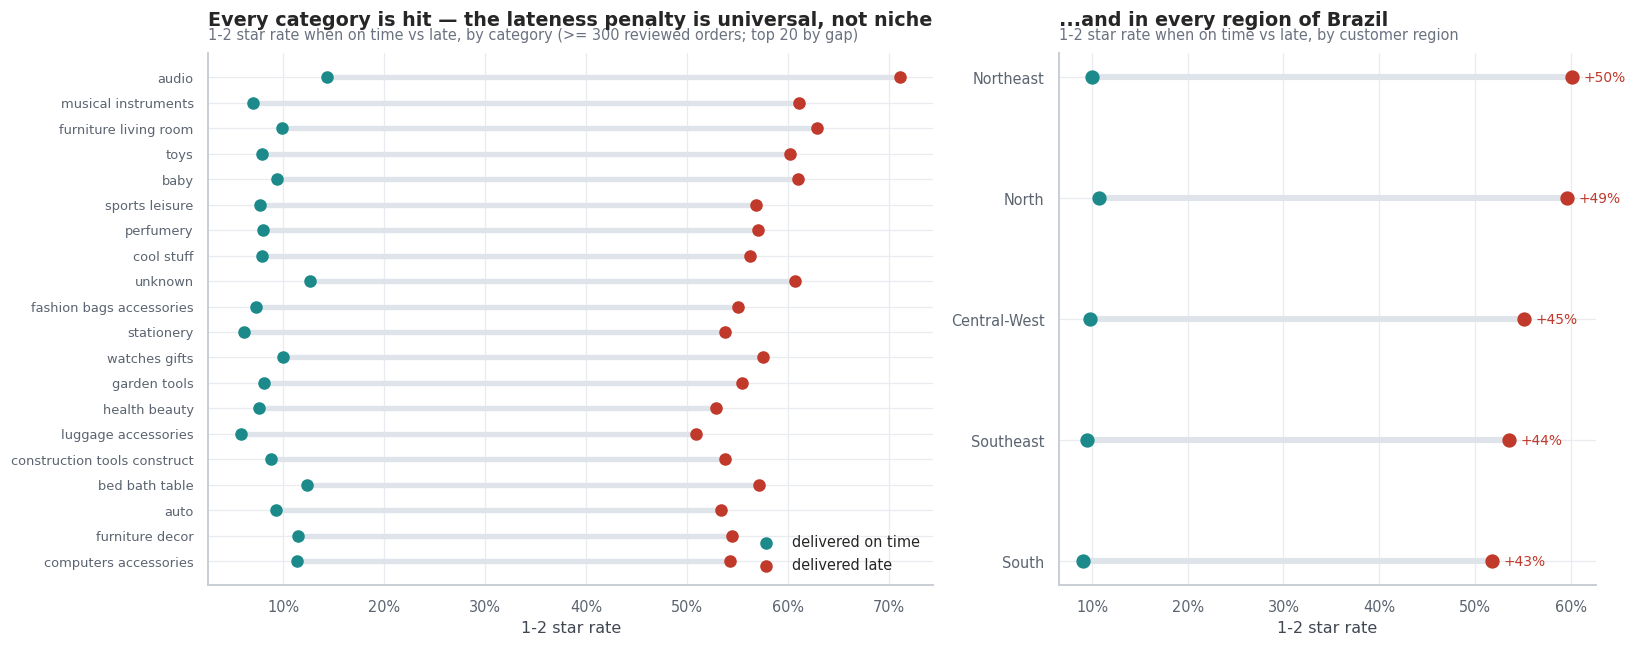

Categories with >= 300 reviewed orders: 32
  categories where late orders score worse : 32/32 (100%)
  median gap across categories             : 44.8% points
  regions where late orders score worse    : 5/5
----------------------------------------------------------------------------------------
Late orders are 8.1% of delivered+reviewed orders, but produce 33.7% of all 1-2 star reviews.
----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
The effect is universal in direction and concentrated in impact — and both halves of
that sentence matter for the recommendation.

Universal: in 32 of 32 categories with at least 300 reviewed orders, and in 5 of 5
regions, late orders score worse. The median category-level gap is 45% percentage
points. This is not a niche problem in one product line or one part of the country, so a
category-by-category fix is

In [24]:
# --- 2.3 Is the effect concentrated, or everywhere? --------------------------
MIN_N = 300
cat_eff = (DELREV.groupby("category", observed=True)
           .agg(orders=("order_id", "count"),
                late_rate=("is_late", "mean"),
                low_ontime=("is_low_review", lambda s: np.nan),
                ))
# Compute per-category low-review rate split by on-time / late
split = (DELREV.assign(late=DELREV["is_late"].astype(bool))
         .groupby(["category", "late"], observed=True)["is_low_review"]
         .agg(["mean", "count"]).unstack("late"))
split.columns = [f"{a}_{'late' if b else 'ontime'}" for a, b in split.columns]
cat_eff = cat_eff.join(split).query("orders >= @MIN_N")
cat_eff["gap"] = cat_eff["mean_late"] - cat_eff["mean_ontime"]
cat_eff = cat_eff.dropna(subset=["gap"]).sort_values("gap")

reg_split = (DELREV.assign(late=DELREV["is_late"].astype(bool))
             .groupby(["customer_region", "late"], observed=True)["is_low_review"]
             .agg(["mean", "count"]).unstack("late"))
reg_split.columns = [f"{a}_{'late' if b else 'ontime'}" for a, b in reg_split.columns]
reg_split["gap"] = reg_split["mean_late"] - reg_split["mean_ontime"]
reg_split = reg_split.sort_values("gap")

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
top = cat_eff.tail(20)
ys = np.arange(len(top))
ax.hlines(ys, top["mean_ontime"], top["mean_late"], color=C["light"], lw=3.5, zorder=1)
ax.scatter(top["mean_ontime"], ys, s=52, color=C["teal"], zorder=3, label="delivered on time")
ax.scatter(top["mean_late"], ys, s=52, color=C["red"], zorder=3, label="delivered late")
ax.set_yticks(ys); ax.set_yticklabels([t[:28] for t in top.index], fontsize=8.5)
ax.xaxis.set_major_formatter(PCT_FMT); ax.legend(loc="lower right")
styled(ax, "Every category is hit — the lateness penalty is universal, not niche",
       f"1-2 star rate when on time vs late, by category (>= {MIN_N} reviewed orders; top 20 by gap)",
       "1-2 star rate", "")

ax = axes[1]
ys = np.arange(len(reg_split))
ax.hlines(ys, reg_split["mean_ontime"], reg_split["mean_late"], color=C["light"], lw=4, zorder=1)
ax.scatter(reg_split["mean_ontime"], ys, s=70, color=C["teal"], zorder=3)
ax.scatter(reg_split["mean_late"], ys, s=70, color=C["red"], zorder=3)
for y, (_, r) in zip(ys, reg_split.iterrows()):
    ax.text(r["mean_late"]+.012, y, f"+{r['gap']:.0%}", va="center", fontsize=9, color=C["red"])
ax.set_yticks(ys); ax.set_yticklabels(reg_split.index)
ax.xaxis.set_major_formatter(PCT_FMT)
styled(ax, "...and in every region of Brazil",
       "1-2 star rate when on time vs late, by customer region", "1-2 star rate", "")
finish(fig, "10_q2_universality")

n_cats = len(cat_eff)
n_pos = int((cat_eff["gap"] > 0).sum())
share_low_from_late = (DELREV[DELREV["is_late"].astype(bool) & DELREV["is_low_review"].astype(bool)].shape[0]
                       / max(DELREV["is_low_review"].sum(), 1))
share_orders_late = DELREV["is_late"].mean()
record("share_low_reviews_from_late", share_low_from_late)

print(f"Categories with >= {MIN_N} reviewed orders: {n_cats}")
print(f"  categories where late orders score worse : {n_pos}/{n_cats} ({n_pos/n_cats:.0%})")
print(f"  median gap across categories             : {cat_eff['gap'].median():.1%} points")
print(f"  regions where late orders score worse    : {int((reg_split['gap']>0).sum())}/{len(reg_split)}")
rule()
print(f"Late orders are {share_orders_late:.1%} of delivered+reviewed orders, "
      f"but produce {share_low_from_late:.1%} of all 1-2 star reviews.")

note(f"""
The effect is universal in direction and concentrated in impact — and both halves of that sentence
matter for the recommendation.

Universal: in {n_pos} of {n_cats} categories with at least {MIN_N} reviewed orders, and in
{int((reg_split['gap']>0).sum())} of {len(reg_split)} regions, late orders score worse. The median
category-level gap is {cat_eff['gap'].median():.0%} percentage points. This is not a niche problem
in one product line or one part of the country, so a category-by-category fix is the wrong shape
of intervention.

Concentrated: late orders are only {share_orders_late:.1%} of delivered-and-reviewed orders, yet
they generate {share_low_from_late:.1%} of all 1-2 star reviews — an over-representation of
{share_low_from_late/share_orders_late:.1f}x. No other single factor in this dataset concentrates
dissatisfaction anything like as tightly, which is what makes it the highest-leverage lever
available.

The corollary is stated just as plainly: the other {1-share_low_from_late:.0%} of bad reviews come
from orders that were delivered on time. Lateness is the largest single contributor, not the whole
of the problem. Core Question 6 sizes the remainder rather than assuming it away.
""", "tech")

note(f"""
Late delivery hurts everywhere — every product type, every region of Brazil. Only about
{share_orders_late:.0%} of orders are actually late, but they produce roughly
{share_low_from_late:.0%} of all bad reviews, about {share_low_from_late/share_orders_late:.0f} times
their fair share. Fixing lateness is the single biggest thing Olist can do for its ratings.

It is not the only thing, though. Around {1-share_low_from_late:.0%} of bad reviews come from
parcels that arrived on time, so something else is going wrong for those customers. The root-cause
section works out what.
""", "plain")


---
# Core Question 3 — Seller and geographic patterns

> *Sellers and customers are not evenly distributed across Brazil. How does this geographic pattern relate to delivery performance, freight cost, or customer satisfaction?*

**Approach:** quantify the concentration first (a Lorenz curve and Gini for sellers), then build a state-level KPI table, then test the chain the concentration implies: **distance → delivery time and freight → satisfaction**. The interesting question is not "which state is worst" but whether geography acts *through* logistics or independently of it.


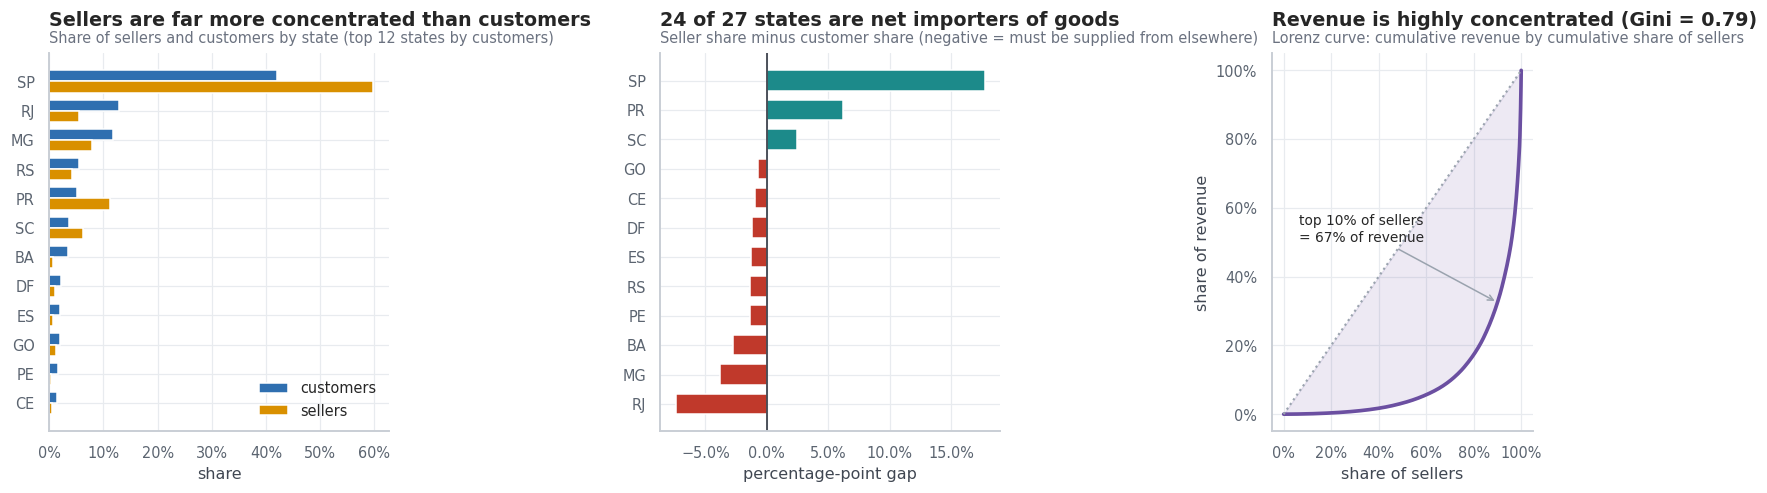

----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Supply and demand sit in different places. Sao Paulo hosts 59.7% of sellers but only
42.0% of customers, and 24 of the 27 states host a smaller share of sellers than of
customers. Combined with a seller-revenue Gini of 0.79 (the top 10% of sellers generate
67% of revenue), the marketplace is structurally a hub-and-spoke: a dense southeastern
supply base shipping outward across a continent-sized country. That structure is the
mechanism behind everything in the rest of this section.



In [25]:
# --- 3.1 How concentrated is supply and demand? ------------------------------
sell_state = sellers["seller_state"].value_counts()
cust_state = customers["customer_state"].value_counts()
conc = pd.DataFrame({"sellers": sell_state, "customers": cust_state}).fillna(0)
conc["seller_share"] = conc["sellers"] / conc["sellers"].sum()
conc["customer_share"] = conc["customers"] / conc["customers"].sum()
conc["supply_demand_gap"] = conc["seller_share"] - conc["customer_share"]
conc = conc.sort_values("customer_share", ascending=False)

seller_rev = items.groupby("seller_id")["price"].sum().sort_values()
g_sellers = gini(seller_rev.values)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), gridspec_kw={"width_ratios": [1.3, 1.3, 1]})

ax = axes[0]
top = conc.head(12).iloc[::-1]
ys = np.arange(len(top)); h = .38
ax.barh(ys + h/2, top["customer_share"], height=h, color=C["blue"], label="customers")
ax.barh(ys - h/2, top["seller_share"], height=h, color=C["amber"], label="sellers")
ax.set_yticks(ys); ax.set_yticklabels(top.index)
ax.xaxis.set_major_formatter(PCT_FMT); ax.legend(loc="lower right")
styled(ax, "Sellers are far more concentrated than customers",
       "Share of sellers and customers by state (top 12 states by customers)", "share", "")

ax = axes[1]
gap = conc.head(12).sort_values("supply_demand_gap")
cols = [C["red"] if v < 0 else C["teal"] for v in gap["supply_demand_gap"]]
ax.barh(gap.index, gap["supply_demand_gap"], color=cols, height=.7)
ax.axvline(0, color=C["ink"], lw=1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
styled(ax, f"{int((conc['supply_demand_gap'] < 0).sum())} of {len(conc)} states are net importers of goods",
       "Seller share minus customer share (negative = must be supplied from elsewhere)",
       "percentage-point gap", "")

ax = axes[2]
cum_sellers = np.arange(1, len(seller_rev)+1) / len(seller_rev)
cum_rev = (seller_rev.cumsum() / seller_rev.sum()).values
ax.plot(cum_sellers, cum_rev, color=C["purple"], lw=2.4)
ax.plot([0, 1], [0, 1], color=C["grey"], ls=":", lw=1.4)
ax.fill_between(cum_sellers, cum_rev, cum_sellers, color=C["purple"], alpha=.12)
top10_share = 1 - cum_rev[np.searchsorted(cum_sellers, .90)]
ax.annotate(f"top 10% of sellers\n= {top10_share:.0%} of revenue",
            xy=(.9, cum_rev[np.searchsorted(cum_sellers, .90)]), xytext=(-130, 40),
            textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color=C["grey"]))
ax.xaxis.set_major_formatter(PCT_FMT); ax.yaxis.set_major_formatter(PCT_FMT)
styled(ax, f"Revenue is highly concentrated (Gini = {g_sellers:.2f})",
       "Lorenz curve: cumulative revenue by cumulative share of sellers",
       "share of sellers", "share of revenue")
finish(fig, "11_q3_concentration")

sp_sellers = conc.loc["SP", "seller_share"]; sp_cust = conc.loc["SP", "customer_share"]
record("sp_seller_share", sp_sellers); record("seller_revenue_gini", g_sellers)

note(f"""
Supply and demand sit in different places. Sao Paulo hosts {sp_sellers:.1%} of sellers but only
{sp_cust:.1%} of customers, and {int((conc['supply_demand_gap'] < 0).sum())} of the {len(conc)}
states host a smaller share of sellers than of customers. Combined with a seller-revenue
Gini of {g_sellers:.2f} (the top 10% of sellers generate {top10_share:.0%} of revenue), the
marketplace is structurally a hub-and-spoke: a dense southeastern supply base shipping outward
across a continent-sized country. That structure is the mechanism behind everything in the rest of
this section.
""", "tech")



State-level KPIs (customer states with >= 100 delivered+reviewed orders)
------------------------------------------------------------------------


,orders,revenue,aov,freight,freight_ratio,delivery_days,delay_days,late_rate,distance_km,avg_review,low_rate,region
customer_state,,,,,,,,,,,,
MA,717,"117,009.380",163.193,42.949,0.383,19.191,-10.007,0.197,"2,196.908",3.813,0.205,Northeast
AL,397,"78,855.720",198.629,38.581,0.327,22.333,-9.435,0.239,"1,915.074",3.826,0.219,Northeast
PA,946,"174,470.590",184.430,39.697,0.342,21.078,-15.079,0.124,"2,392.933",3.890,0.185,North
SE,335,"56,574.190",168.878,40.940,0.346,18.014,-12.127,0.152,"1,720.993",3.899,0.191,Northeast
BA,3256,"493,584.140",151.592,29.961,0.288,16.914,-11.563,0.140,"1,422.402",3.911,0.176,Northeast
CE,1279,"219,757.380",171.820,36.497,0.319,18.209,-12.274,0.153,"2,292.467",3.937,0.174,Northeast
RJ,12350,"1,759,651.130",142.482,23.947,0.237,12.042,-12.255,0.135,394.130,3.947,0.188,Southeast
PI,476,"84,721.000",177.985,42.977,0.326,16.292,-13.077,0.160,"2,051.709",3.979,0.166,Northeast
ES,1995,"268,643.450",134.658,24.569,0.254,13.637,-11.153,0.122,762.022,4.047,0.147,Southeast


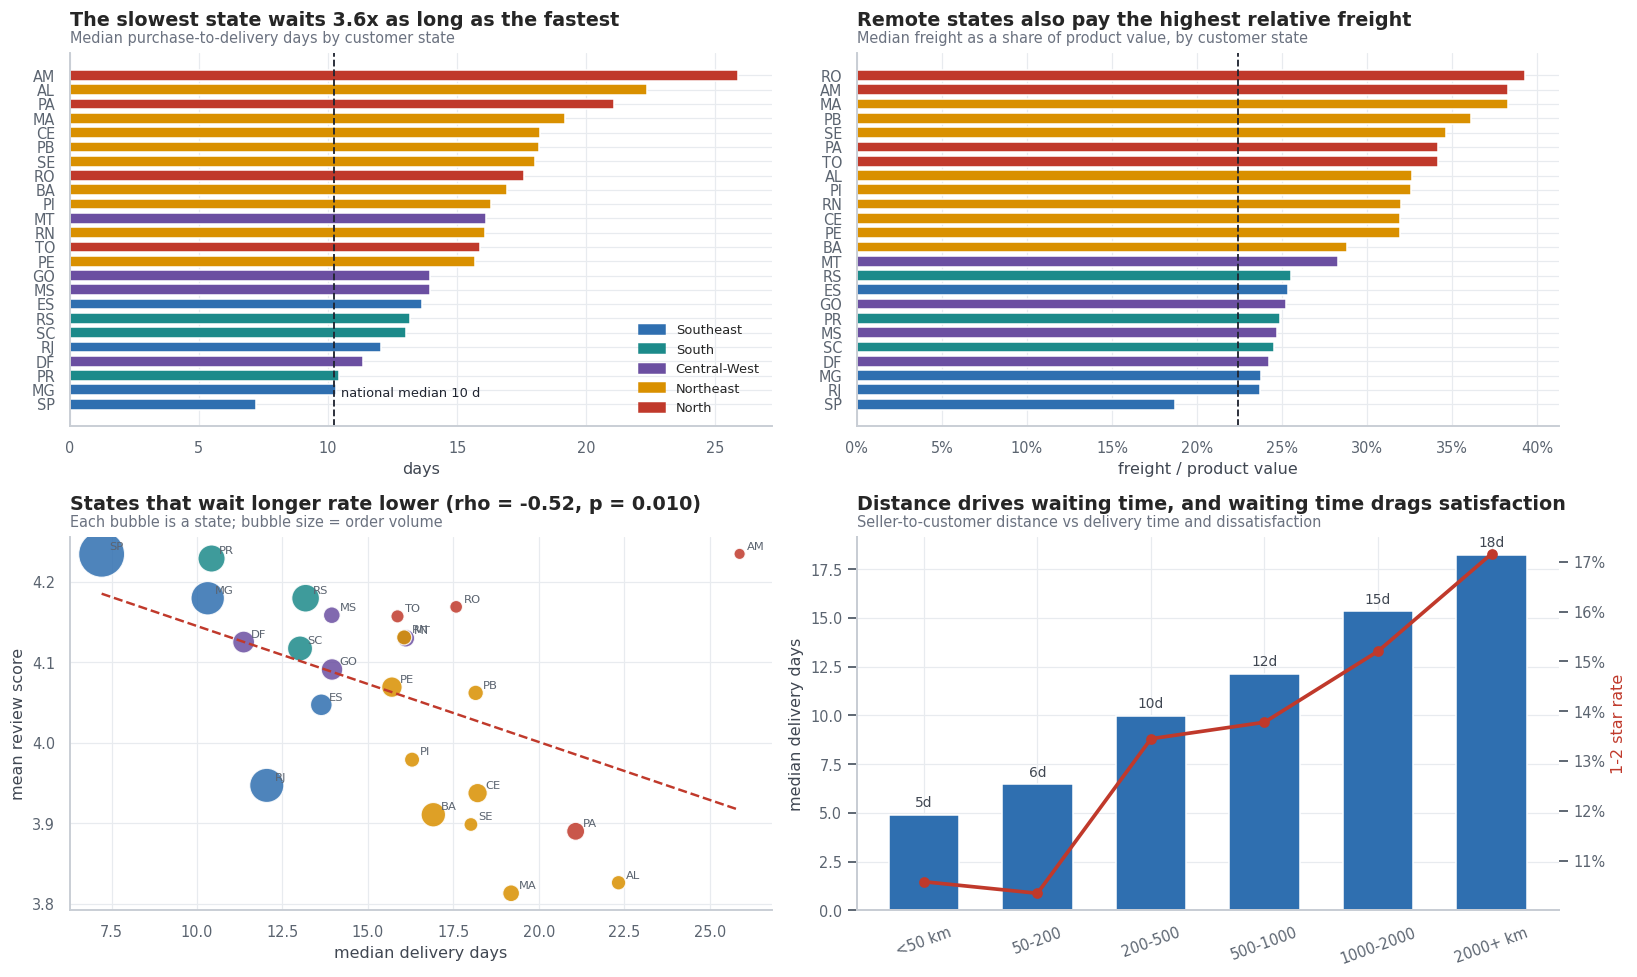

In [26]:
# --- 3.2 State-level KPI table -----------------------------------------------
MIN_STATE_N = 100
state = (DELREV.groupby("customer_state", observed=True)
         .agg(orders=("order_id", "count"),
              revenue=("order_value", "sum"),
              aov=("order_value", "mean"),
              freight=("freight_total", "mean"),
              freight_ratio=("freight_ratio", "median"),
              delivery_days=("delivery_days", "median"),
              delay_days=("delivery_delay_days", "median"),
              late_rate=("is_late", "mean"),
              distance_km=("distance_km", "median"),
              avg_review=("review_score", "mean"),
              low_rate=("is_low_review", "mean"))
         .query("orders >= @MIN_STATE_N"))
state["region"] = state.index.map(STATE2REGION)
state = state.sort_values("avg_review")
show(state.style.format({"orders": "{:,.0f}", "revenue": "{:,.0f}", "aov": "{:.2f}",
                         "freight": "{:.2f}", "freight_ratio": "{:.1%}", "delivery_days": "{:.1f}",
                         "delay_days": "{:.1f}", "late_rate": "{:.1%}", "distance_km": "{:,.0f}",
                         "avg_review": "{:.2f}", "low_rate": "{:.1%}"}).data,
     n=30, title=f"State-level KPIs (customer states with >= {MIN_STATE_N} delivered+reviewed orders)")

REGION_COLORS = {"Southeast": C["blue"], "South": C["teal"], "Central-West": C["purple"],
                 "Northeast": C["amber"], "North": C["red"], "unknown": C["grey"]}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

ax = axes[0, 0]
s = state.sort_values("delivery_days")
ax.barh(s.index, s["delivery_days"], color=[REGION_COLORS[r] for r in s["region"]], height=.75)
ax.axvline(DEL["delivery_days"].median(), color=C["ink"], ls="--", lw=1.2)
ax.text(DEL["delivery_days"].median()+.3, .5, f"national median {DEL['delivery_days'].median():.0f} d",
        fontsize=8.5, color=C["ink"])
handles = [plt.Rectangle((0,0),1,1,color=c) for r, c in REGION_COLORS.items() if r in set(state["region"])]
labels  = [r for r in REGION_COLORS if r in set(state["region"])]
ax.legend(handles, labels, loc="lower right", fontsize=8.5)
styled(ax, f"The slowest state waits {s['delivery_days'].max()/s['delivery_days'].min():.1f}x "
           f"as long as the fastest",
       "Median purchase-to-delivery days by customer state", "days", "")

ax = axes[0, 1]
s = state.sort_values("freight_ratio")
ax.barh(s.index, s["freight_ratio"], color=[REGION_COLORS[r] for r in s["region"]], height=.75)
ax.xaxis.set_major_formatter(PCT_FMT)
ax.axvline(master["freight_ratio"].median(), color=C["ink"], ls="--", lw=1.2)
styled(ax, "Remote states also pay the highest relative freight",
       "Median freight as a share of product value, by customer state", "freight / product value", "")

ax = axes[1, 0]
sc = ax.scatter(state["delivery_days"], state["avg_review"],
                s=np.sqrt(state["orders"])*4.5,
                c=[REGION_COLORS[r] for r in state["region"]], alpha=.85, edgecolor="white", lw=.8)
for stt, r in state.iterrows():
    ax.annotate(stt, (r["delivery_days"], r["avg_review"]), fontsize=7.5,
                xytext=(5, 3), textcoords="offset points", color="#5b6470")
b, a = np.polyfit(state["delivery_days"], state["avg_review"], 1)
xs = np.linspace(state["delivery_days"].min(), state["delivery_days"].max(), 50)
ax.plot(xs, a + b*xs, color=C["red"], ls="--", lw=1.6)
rho_sd, p_sd = st.spearmanr(state["delivery_days"], state["avg_review"])
styled(ax, f"States that wait longer rate lower (rho = {rho_sd:+.2f}, p {pfmt(p_sd)})",
       "Each bubble is a state; bubble size = order volume", "median delivery days", "mean review score")

ax = axes[1, 1]
dist = DELREV.dropna(subset=["distance_bucket"])
db = (dist.groupby("distance_bucket", observed=True)
      .agg(orders=("order_id", "count"), days=("delivery_days", "median"),
           freight=("freight_total", "median"), late=("is_late", "mean"),
           low=("is_low_review", "mean")))
xs = np.arange(len(db))
ax.bar(xs, db["days"], color=C["blue"], width=.62, label="median delivery days")
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(xs, db["low"], color=C["red"], lw=2.4, marker="o", label="1-2 star rate")
ax2.yaxis.set_major_formatter(PCT_FMT)
ax2.set_ylabel("1-2 star rate", color=C["red"])
ax.set_xticks(xs); ax.set_xticklabels(db.index, rotation=20)
for x, v, n in zip(xs, db["days"], db["orders"]):
    ax.text(x, v+.4, f"{v:.0f}d", ha="center", fontsize=9, color="#404752")
styled(ax, "Distance drives waiting time, and waiting time drags satisfaction",
       "Seller-to-customer distance vs delivery time and dissatisfaction",
       "", "median delivery days")
finish(fig, "12_q3_geography")


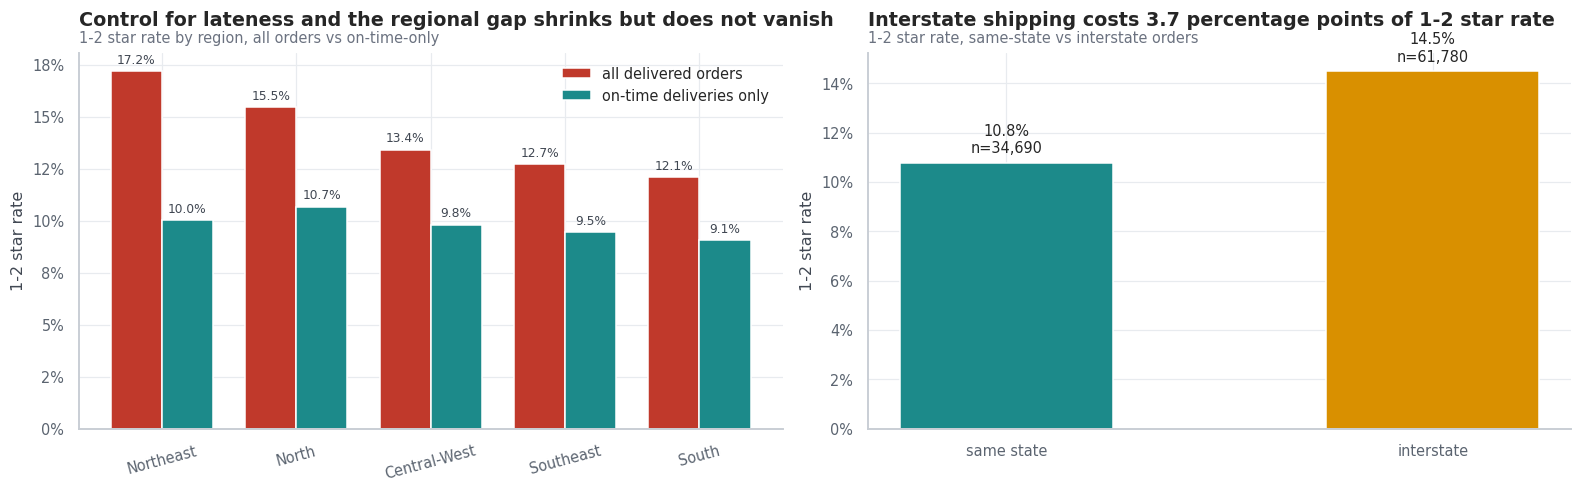

Distance correlations (Spearman, delivered+reviewed orders)
----------------------------------------------------------------------------------------
  distance vs delivery days : rho = +0.542, p < 1e-300
  distance vs freight paid   : rho = +0.584, p < 1e-300
  distance vs review score   : rho = -0.064, p < 0.001
----------------------------------------------------------------------------------------
  worst-rated state: MA (3.81 stars, 19 d median delivery, 19.7% late)
  best-rated state : AM (4.23 stars, 26 d median delivery, 4.1% late)
  regional 1-2 star spread: 5.1% overall -> 1.6% among on-time orders
  interstate vs same-state: Cliff's delta = -0.063 (negligible)
----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Geography works mostly through logistics, and slightly beyond it.

The chain is intact. Distance correlates with delivery ti

In [27]:
# --- 3.3 Does geography matter beyond its effect on delivery? ----------------
# Same-state vs interstate, then the decisive test: within on-time deliveries only,
# does the North still rate worse? If yes, geography has an effect of its own.

same  = DELREV[DELREV["same_state"] == True]
inter = DELREV[DELREV["same_state"] == False]
d_same, mag_same = cliffs_delta(inter["review_score"], same["review_score"])

ontime_only = DELREV[DELREV["is_late"] == 0]
reg_ontime = (ontime_only.groupby("customer_region", observed=True)
              .agg(orders=("order_id", "count"), score=("review_score", "mean"),
                   low=("is_low_review", "mean"), days=("delivery_days", "median")))
reg_all = (DELREV.groupby("customer_region", observed=True)
           .agg(orders=("order_id", "count"), score=("review_score", "mean"),
                low=("is_low_review", "mean"), late=("is_late", "mean")))
comp = reg_all.join(reg_ontime[["score", "low", "days"]], rsuffix="_ontime").sort_values("score")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
ax = axes[0]
xs = np.arange(len(comp)); w = .38
ax.bar(xs - w/2, comp["low"], w, color=C["red"], label="all delivered orders")
ax.bar(xs + w/2, comp["low_ontime"], w, color=C["teal"], label="on-time deliveries only")
ax.set_xticks(xs); ax.set_xticklabels(comp.index, rotation=15)
ax.yaxis.set_major_formatter(PCT_FMT); ax.legend()
bar_labels(ax, "{:.1%}", fontsize=8)
styled(ax, "Control for lateness and the regional gap shrinks but does not vanish",
       "1-2 star rate by region, all orders vs on-time-only", "", "1-2 star rate")

ax = axes[1]
ax.bar(["same state", "interstate"],
       [same["is_low_review"].mean(), inter["is_low_review"].mean()],
       color=[C["teal"], C["amber"]], width=.5)
for i, (grp, lab) in enumerate([(same, "same state"), (inter, "interstate")]):
    ax.text(i, grp["is_low_review"].mean()+.004,
            f"{grp['is_low_review'].mean():.1%}\nn={len(grp):,}", ha="center", fontsize=9.5)
ax.yaxis.set_major_formatter(PCT_FMT)
styled(ax, f"Interstate shipping costs {100*(inter['is_low_review'].mean()-same['is_low_review'].mean()):.1f}"
           f" percentage points of 1-2 star rate",
       "1-2 star rate, same-state vs interstate orders", "", "1-2 star rate")
finish(fig, "13_q3_geo_controlled")

rho_dist_days, p_dd = st.spearmanr(DELREV["distance_km"], DELREV["delivery_days"], nan_policy="omit")
rho_dist_fr, p_df = st.spearmanr(DELREV["distance_km"], DELREV["freight_total"], nan_policy="omit")
rho_dist_score, p_ds = st.spearmanr(DELREV["distance_km"], DELREV["review_score"], nan_policy="omit")
worst = state.index[0]; best = state.index[-1]
gap_all = comp["low"].max() - comp["low"].min()
gap_ontime = comp["low_ontime"].max() - comp["low_ontime"].min()
record("north_vs_se_gap_ontime", gap_ontime)

print("Distance correlations (Spearman, delivered+reviewed orders)")
rule()
print(f"  distance vs delivery days : rho = {rho_dist_days:+.3f}, p {pfmt(p_dd)}")
print(f"  distance vs freight paid   : rho = {rho_dist_fr:+.3f}, p {pfmt(p_df)}")
print(f"  distance vs review score   : rho = {rho_dist_score:+.3f}, p {pfmt(p_ds)}")
rule()
print(f"  worst-rated state: {worst} ({state.loc[worst,'avg_review']:.2f} stars, "
      f"{state.loc[worst,'delivery_days']:.0f} d median delivery, "
      f"{state.loc[worst,'late_rate']:.1%} late)")
print(f"  best-rated state : {best} ({state.loc[best,'avg_review']:.2f} stars, "
      f"{state.loc[best,'delivery_days']:.0f} d median delivery, "
      f"{state.loc[best,'late_rate']:.1%} late)")
print(f"  regional 1-2 star spread: {gap_all:.1%} overall -> {gap_ontime:.1%} among on-time orders")
print(f"  interstate vs same-state: Cliff's delta = {d_same:+.3f} ({mag_same})")

note(f"""
Geography works mostly through logistics, and slightly beyond it.

The chain is intact. Distance correlates with delivery time (rho = {rho_dist_days:+.2f}) and with
freight paid (rho = {rho_dist_fr:+.2f}); states with longer median delivery times have lower mean
scores (rho = {rho_sd:+.2f} across states). Remote states are hit twice: the slowest state waits
{state['delivery_days'].max()/state['delivery_days'].min():.1f}x as long as the fastest
({state['delivery_days'].max():.0f} vs {state['delivery_days'].min():.0f} days) AND pays the highest
freight relative to item value.

But geography is not purely a proxy for lateness. Restricting to on-time deliveries only, the
regional spread in 1-2 star rate narrows from {gap_all:.1%} to {gap_ontime:.1%} — a large
reduction, but not to zero. Something about the remote-region experience survives punctuality:
plausibly the sheer length of the wait, the higher freight burden, or thinner seller choice.
Distance itself correlates only weakly with the score directly ({rho_dist_score:+.2f}), consistent
with distance mattering because of what it does to timing and cost rather than in its own right.

Interstate orders do rate worse, but the gap is small: {inter['is_low_review'].mean():.1%} vs
{same['is_low_review'].mean():.1%} in 1-2 star rate, and as an effect size it is {mag_same}
(Cliff's delta {d_same:+.3f}). That size matters for the recommendation: relocating inventory closer
to customers would help, but it is a second-order lever next to hitting the promised date.
""", "tech")

note(f"""
Most sellers are clustered around Sao Paulo while customers are spread across the whole country,
so parcels travel a long way — and the further they travel, the longer they take and the more
shipping costs. Customers in the slowest states wait several times longer than those closest to the
sellers, and they rate their orders lower.

Almost all of that gap disappears when you compare only parcels that arrived on time: the regional
difference in bad reviews shrinks from {gap_all:.0%} to {gap_ontime:.0%}. So living far away is not
really the problem — the delays that come with living far away are.
""", "plain")


---
# Core Question 4 — Product category performance

> *How do order volume, price and review scores differ across categories? Are any notably stronger or weaker than the platform average?*

**Approach:** rank categories on volume, revenue and price, then test each category's mean review score against the platform mean with a proper multiple-comparison correction. With ~70 categories, testing each at α = 0.05 would produce three or four false "significant" results by chance alone; Benjamini–Hochberg keeps the false-discovery rate controlled. Finally, check whether category differences are really *delivery* differences in disguise.



Top 15 categories by order volume (>= 100 reviewed orders)
----------------------------------------------------------


,orders,revenue,median_price,mean_price,freight_ratio,avg_review,low_rate,late_rate,delivery_days,weight_g,revenue_share
category,,,,,,,,,,,
bed bath table,9328,"1,037,777.680",89.000,111.254,0.216,3.957,0.171,0.088,10.749,"1,350.000",0.076
health beauty,8801,"1,259,312.820",85.900,143.087,0.204,4.168,0.130,0.090,9.574,427.000,0.093
sports leisure,7683,"987,722.310",89.990,128.559,0.210,4.160,0.132,0.078,10.117,713.000,0.073
computers accessories,6670,"911,673.700",86.500,136.683,0.214,4.016,0.163,0.077,11.113,300.000,0.067
furniture decor,6330,"727,567.600",79.900,114.940,0.258,4.014,0.166,0.086,10.915,"1,400.000",0.054
housewares,5821,"631,945.900",69.800,108.563,0.280,4.133,0.135,0.070,8.945,"1,291.000",0.046
watches gifts,5607,"1,205,980.880",139.900,215.085,0.113,4.050,0.156,0.085,10.355,350.000,0.089
telephony,4179,"323,242.780",29.990,77.349,0.440,3.999,0.156,0.085,10.815,225.000,0.024
auto,3880,"593,117.610",89.995,152.865,0.220,4.086,0.146,0.086,9.760,900.000,0.044


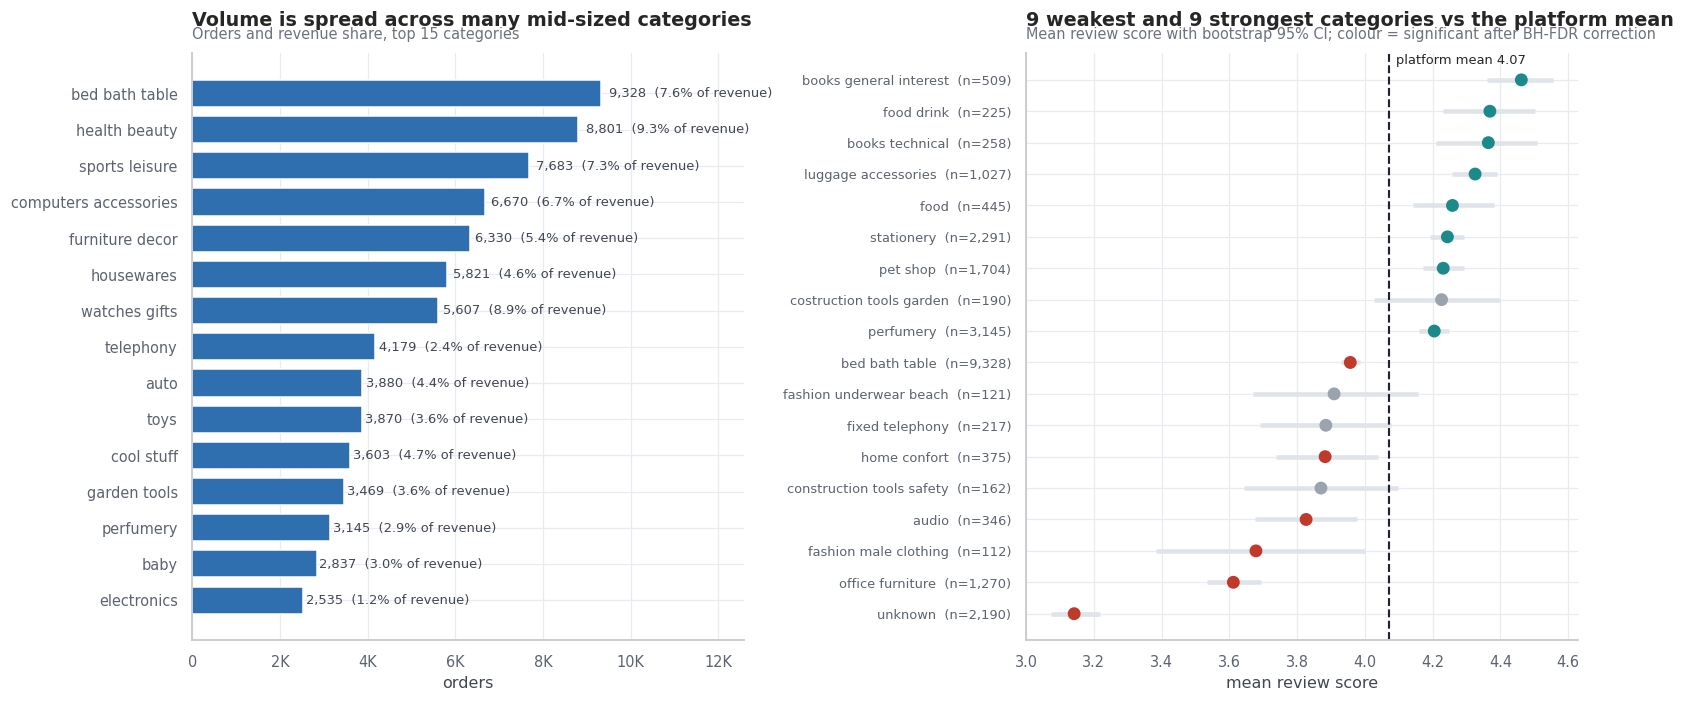

Categories tested: 52   |   below platform: 9   above: 15   indistinguishable: 28   (BH-FDR at 5%)


In [28]:
# --- 4.1 Category league table -----------------------------------------------
MIN_CAT_N = 100
cat = (REV.groupby("category", observed=True)
       .agg(orders=("order_id", "count"),
            revenue=("order_value", "sum"),
            median_price=("order_value", "median"),
            mean_price=("order_value", "mean"),
            freight_ratio=("freight_ratio", "median"),
            avg_review=("review_score", "mean"),
            low_rate=("is_low_review", "mean"),
            late_rate=("is_late", "mean"),
            delivery_days=("delivery_days", "median"),
            weight_g=("product_weight_g", "median"))
       .query("orders >= @MIN_CAT_N"))
cat["revenue_share"] = cat["revenue"] / REV["order_value"].sum()
cat = cat.sort_values("orders", ascending=False)

platform_mean = REV["review_score"].mean()

# One-sample test of each category against the platform mean, BH-corrected.
tests = []
for c, g in REV.groupby("category", observed=True):
    if len(g) < MIN_CAT_N:
        continue
    t, p = st.ttest_1samp(g["review_score"], platform_mean)
    lo, hi = boot_ci_mean(g["review_score"], n_boot=1200)
    tests.append({"category": c, "orders": len(g), "mean": g["review_score"].mean(),
                  "ci_lo": lo, "ci_hi": hi, "diff": g["review_score"].mean() - platform_mean,
                  "p": p})
cattest = pd.DataFrame(tests)
cattest["reject"], cattest["q"] = bh_fdr(cattest["p"].values, alpha=0.05)
cattest["verdict"] = np.where(~cattest["reject"], "no different",
                       np.where(cattest["diff"] > 0, "above platform", "below platform"))
cattest = cattest.sort_values("diff")

show(cat.head(15).style.format({"orders": "{:,.0f}", "revenue": "{:,.0f}",
     "median_price": "{:.2f}", "mean_price": "{:.2f}", "freight_ratio": "{:.1%}",
     "avg_review": "{:.2f}", "low_rate": "{:.1%}", "late_rate": "{:.1%}",
     "delivery_days": "{:.1f}", "weight_g": "{:,.0f}", "revenue_share": "{:.1%}"}).data,
     n=15, title=f"Top 15 categories by order volume (>= {MIN_CAT_N} reviewed orders)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ax = axes[0]
topv = cat.head(15).iloc[::-1]
ax.barh([t[:26] for t in topv.index], topv["orders"], color=C["blue"], height=.75)
ax.xaxis.set_major_formatter(K_FMT)
for y, (o, r) in enumerate(zip(topv["orders"], topv["revenue_share"])):
    ax.text(o*1.02, y, f"{o:,.0f}  ({r:.1%} of revenue)", va="center", fontsize=8.5, color="#404752")
ax.set_xlim(0, topv["orders"].max()*1.35)
styled(ax, "Volume is spread across many mid-sized categories",
       "Orders and revenue share, top 15 categories", "orders", "")

ax = axes[1]
sig = cattest[cattest["reject"]]
worst15 = pd.concat([cattest.head(9), cattest.tail(9)])
ys = np.arange(len(worst15))
cols = [C["red"] if v == "below platform" else C["teal"] if v == "above platform" else C["grey"]
        for v in worst15["verdict"]]
ax.errorbar(worst15["mean"], ys,
            xerr=[worst15["mean"]-worst15["ci_lo"], worst15["ci_hi"]-worst15["mean"]],
            fmt="o", ecolor=C["light"], elinewidth=3, ms=0, zorder=1)
ax.scatter(worst15["mean"], ys, c=cols, s=55, zorder=3)
ax.axvline(platform_mean, color=C["ink"], ls="--", lw=1.4)
ax.text(platform_mean+.02, len(ys)-.5, f"platform mean {platform_mean:.2f}", fontsize=8.5)
ax.set_yticks(ys)
ax.set_yticklabels([f"{c[:26]}  (n={n:,})" for c, n in zip(worst15["category"], worst15["orders"])],
                   fontsize=8.5)
styled(ax, "9 weakest and 9 strongest categories vs the platform mean",
       "Mean review score with bootstrap 95% CI; colour = significant after BH-FDR correction",
       "mean review score", "")
finish(fig, "14_q4_category_league")

n_below = int((cattest["verdict"] == "below platform").sum())
n_above = int((cattest["verdict"] == "above platform").sum())
n_flat  = int((cattest["verdict"] == "no different").sum())
print(f"Categories tested: {len(cattest)}   |   below platform: {n_below}   "
      f"above: {n_above}   indistinguishable: {n_flat}   (BH-FDR at 5%)")


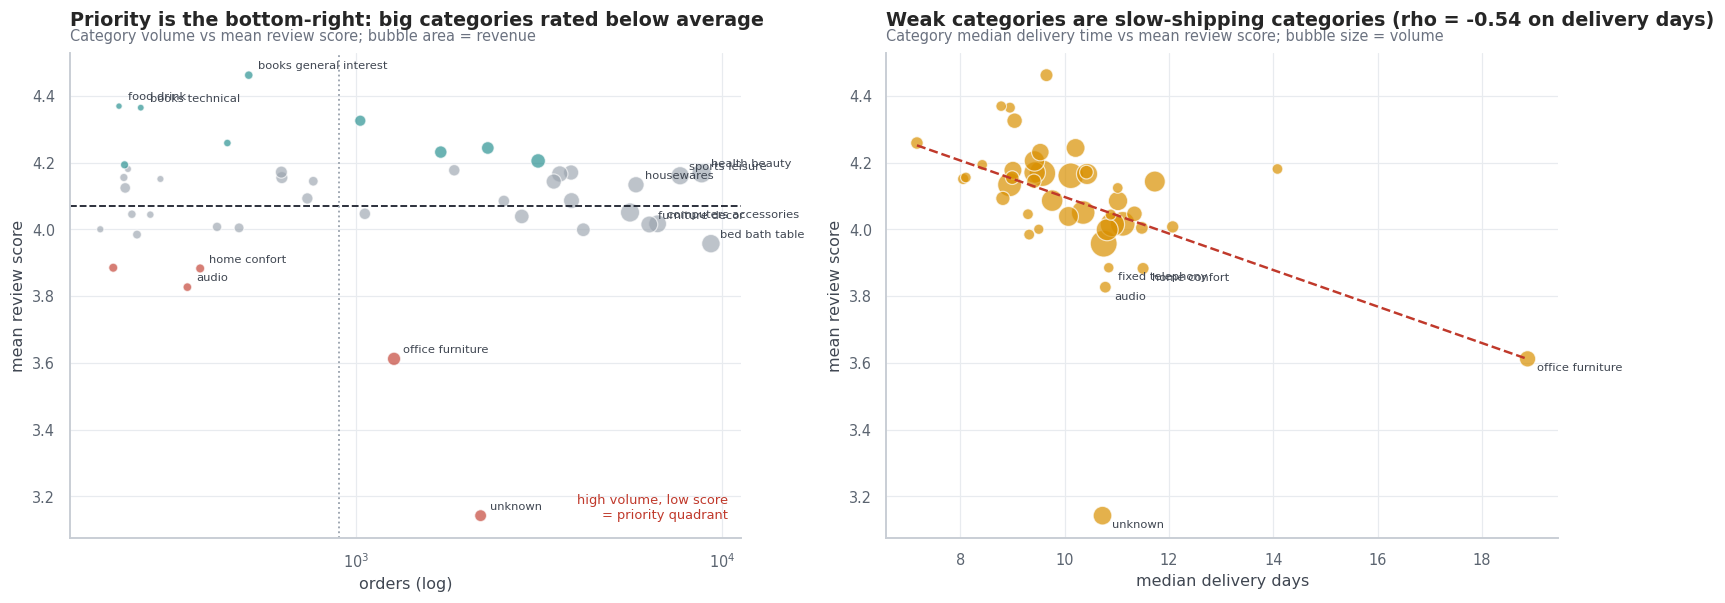


Significantly BELOW the platform mean (largest gaps):
   unknown                            3.14 stars (-0.93), n=2,190, late 9.0%
   office furniture                   3.61 stars (-0.46), n=1,270, late 9.2%
   fashion male clothing              3.68 stars (-0.39), n=112, late 4.7%
   audio                              3.83 stars (-0.24), n=346, late 13.1%
   home confort                       3.88 stars (-0.19), n=375, late 10.3%

Significantly ABOVE the platform mean (largest gaps):
   books general interest             4.46 stars (+0.39), n=509, late 6.9%
   food drink                         4.37 stars (+0.30), n=225, late 6.4%
   books technical                    4.36 stars (+0.29), n=258, late 11.0%
   luggage accessories                4.33 stars (+0.25), n=1,027, late 5.4%
   food                               4.26 stars (+0.19), n=445, late 10.1%
----------------------------------------------------------------------------------------
Category spread in mean score: 1.32 stars

In [29]:
# --- 4.2 Volume vs satisfaction quadrant, and the delivery confound ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

ax = axes[0]
plot_cat = cat[cat["orders"] >= 200]
sizes = np.sqrt(plot_cat["revenue"]) / 7
colors = [C["red"] if s < platform_mean - .12 else C["teal"] if s > platform_mean + .12 else C["grey"]
          for s in plot_cat["avg_review"]]
ax.scatter(plot_cat["orders"], plot_cat["avg_review"], s=sizes, c=colors,
           alpha=.65, edgecolor="white", lw=.8)
ax.axhline(platform_mean, color=C["ink"], ls="--", lw=1.2)
ax.axvline(plot_cat["orders"].median(), color=C["grey"], ls=":", lw=1.2)
ax.set_xscale("log")
label_me = pd.concat([plot_cat.nlargest(6, "orders"),
                      plot_cat.nsmallest(4, "avg_review"),
                      plot_cat.nlargest(3, "avg_review")]).drop_duplicates()
for c, r in label_me.iterrows():
    ax.annotate(c[:22], (r["orders"], r["avg_review"]), fontsize=7.5,
                xytext=(6, 4), textcoords="offset points", color="#404752")
ax.text(.98, .04, "high volume, low score\n= priority quadrant", transform=ax.transAxes,
        ha="right", fontsize=8.5, color=C["red"])
styled(ax, "Priority is the bottom-right: big categories rated below average",
       "Category volume vs mean review score; bubble area = revenue", "orders (log)", "mean review score")

ax = axes[1]
# Does category still matter once delivery is held constant?
ct = cat[cat["orders"] >= 200].copy()
rho_cat_late, p_cl = st.spearmanr(ct["late_rate"], ct["avg_review"])
rho_cat_days, p_cd = st.spearmanr(ct["delivery_days"], ct["avg_review"])
ax.scatter(ct["delivery_days"], ct["avg_review"], s=np.sqrt(ct["orders"])*3.2,
           color=C["amber"], alpha=.7, edgecolor="white", lw=.8)
b, a = np.polyfit(ct["delivery_days"], ct["avg_review"], 1)
xs = np.linspace(ct["delivery_days"].min(), ct["delivery_days"].max(), 50)
ax.plot(xs, a + b*xs, color=C["red"], ls="--", lw=1.6)
for c, r in ct.nsmallest(5, "avg_review").iterrows():
    ax.annotate(c[:22], (r["delivery_days"], r["avg_review"]), fontsize=7.5,
                xytext=(6, -8), textcoords="offset points", color="#404752")
styled(ax, f"Weak categories are slow-shipping categories (rho = {rho_cat_days:+.2f} on delivery days)",
       "Category median delivery time vs mean review score; bubble size = volume",
       "median delivery days", "mean review score")
finish(fig, "15_q4_quadrant")

# Within-category effect after conditioning on lateness
cat_ontime = (DELREV[DELREV["is_late"] == 0].groupby("category", observed=True)
              .agg(orders=("order_id", "count"), score=("review_score", "mean"))
              .query("orders >= 200"))
spread_all = ct["avg_review"].max() - ct["avg_review"].min()
spread_ot = cat_ontime["score"].max() - cat_ontime["score"].min()

worst_cats = cattest[cattest["verdict"] == "below platform"].nsmallest(5, "diff")
best_cats  = cattest[cattest["verdict"] == "above platform"].nlargest(5, "diff")
print("\nSignificantly BELOW the platform mean (largest gaps):")
for _, r in worst_cats.iterrows():
    lr = cat.loc[r['category'], 'late_rate'] if r['category'] in cat.index else np.nan
    print(f"   {r['category'][:34]:<34} {r['mean']:.2f} stars ({r['diff']:+.2f}), "
          f"n={r['orders']:,}, late {lr:.1%}")
print("\nSignificantly ABOVE the platform mean (largest gaps):")
for _, r in best_cats.iterrows():
    lr = cat.loc[r['category'], 'late_rate'] if r['category'] in cat.index else np.nan
    print(f"   {r['category'][:34]:<34} {r['mean']:.2f} stars ({r['diff']:+.2f}), "
          f"n={r['orders']:,}, late {lr:.1%}")
rule()
print(f"Category spread in mean score: {spread_all:.2f} stars overall -> "
      f"{spread_ot:.2f} stars among on-time deliveries only")

record("n_cats_below", n_below); record("n_cats_above", n_above)

note(f"""
Categories differ, but less than they appear to, and mostly for logistical reasons.

Of {len(cattest)} categories with at least {MIN_CAT_N} reviewed orders, {n_below} score
significantly below the platform mean and {n_above} significantly above after BH-FDR correction;
{n_flat} are statistically indistinguishable from the platform. Without the correction the "weak
category" list would be noticeably longer and several entries would be noise.

The weak end is: {", ".join(worst_cats["category"].head(4))}. The single weakest group is
"unknown" — products whose category is missing from the catalogue entirely. That is a finding in
itself: incomplete listings are associated with materially worse outcomes
({cattest.set_index("category").loc["unknown","mean"]:.2f} stars vs {platform_mean:.2f} platform),
which points at listing quality rather than at any particular product line.

What links the weak categories is shipping DURATION rather than missed promises. Across categories,
mean score correlates with median delivery days at rho = {rho_cat_days:+.2f}, but only at
rho = {rho_cat_late:+.2f} (p {pfmt(p_cl)}) with the late rate — the weak categories are slow, not
disproportionately unreliable. Bulky goods (office furniture, home comfort) sit in this group, which
is consistent with heavier items simply taking longer to move.

The decisive check: restricting to on-time deliveries compresses the category spread from
{spread_all:.2f} stars to {spread_ot:.2f} stars, a {1-spread_ot/spread_all:.0%} reduction. A
meaningful share of what looks like "this category disappoints customers" is really "this category
ships slowly". A substantial residual remains, so genuine product-quality and expectation-management
differences do exist — category is a real but second-order lever.

Volume note: revenue is not concentrated in a handful of categories the way it is in sellers.
The largest category is only {cat['revenue_share'].max():.1%} of revenue, so category-level fixes
have naturally limited reach.
""", "tech")

note(f"""
Some product types do get worse ratings than others — bulky items such as office furniture, and
anything whose category is missing from the catalogue. Part of that difference is simply that those
things take longer to ship: comparing only orders that arrived on time shrinks the gap between the
best and worst categories from {spread_all:.1f} stars to {spread_ot:.1f}. The rest is likely to be
about the products and their listings themselves. Either way, category is worth watching but it is
not the main story.
""", "plain")


---
# Core Question 5 — Payment behaviour

> *How do payment type and installment choices relate to order value, and do they appear connected to anything else in the customer's experience?*

**Approach:** describe the payment mix, then test the value relationship, then ask the harder question — does payment behaviour predict satisfaction *on its own*, or only because expensive orders behave differently? The answer is checked by stratifying on order value.



Payment method mix
------------------


,orders,revenue,median_value,mean_value,mean_installments,avg_review,low_rate,late_rate,order_share,revenue_share
payment_type,,,,,,,,,,
credit card,74975,"12,542,527.150",89.900,144.009,3.554,4.073,0.151,0.080,0.754,0.783
boleto,19784,"2,869,361.270",74.990,121.930,1.000,4.071,0.149,0.089,0.199,0.179
voucher,3151,"379,043.910",59.990,95.241,1.000,3.983,0.174,0.070,0.032,0.024
debit card,1527,"217,939.790",70.000,120.810,1.000,4.160,0.133,0.080,0.015,0.014


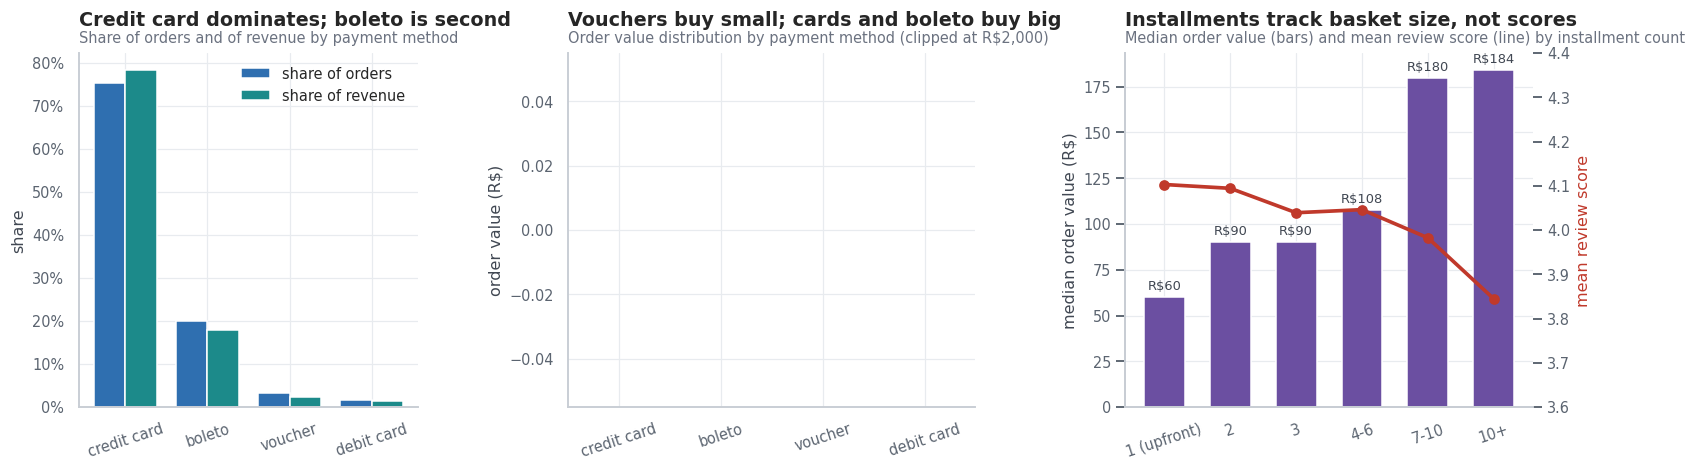

Spearman: installments vs order value  rho = +0.373, p < 1e-300
Credit card vs boleto order value      Cliff's delta = +0.111 (negligible)


In [30]:
# --- 5.1 Payment mix and order value -----------------------------------------
pay = REV[REV["payment_type"].notna() & (REV["payment_type"] != "not defined")].copy()

pmix = (pay.groupby("payment_type", observed=True)
        .agg(orders=("order_id", "count"),
             revenue=("total_paid", "sum"),
             median_value=("order_value", "median"),
             mean_value=("order_value", "mean"),
             mean_installments=("installments", "mean"),
             avg_review=("review_score", "mean"),
             low_rate=("is_low_review", "mean"),
             late_rate=("is_late", "mean"))
        .sort_values("orders", ascending=False))
pmix["order_share"] = pmix["orders"] / pmix["orders"].sum()
pmix["revenue_share"] = pmix["revenue"] / pmix["revenue"].sum()
show(pmix.style.format({"orders": "{:,.0f}", "revenue": "{:,.0f}", "median_value": "{:.2f}",
     "mean_value": "{:.2f}", "mean_installments": "{:.1f}", "avg_review": "{:.2f}",
     "low_rate": "{:.1%}", "late_rate": "{:.1%}", "order_share": "{:.1%}",
     "revenue_share": "{:.1%}"}).data, n=6, title="Payment method mix")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), gridspec_kw={"width_ratios": [1, 1.2, 1.2]})

ax = axes[0]
xs = np.arange(len(pmix)); w = .38
ax.bar(xs - w/2, pmix["order_share"], w, color=C["blue"], label="share of orders")
ax.bar(xs + w/2, pmix["revenue_share"], w, color=C["teal"], label="share of revenue")
ax.set_xticks(xs); ax.set_xticklabels(pmix.index, rotation=18)
ax.yaxis.set_major_formatter(PCT_FMT); ax.legend()
styled(ax, "Credit card dominates; boleto is second",
       "Share of orders and of revenue by payment method", "", "share")

ax = axes[1]
order_pt = pmix.index.tolist()
data = [pay.loc[pay["payment_type"] == p, "order_value"].clip(upper=2000) for p in order_pt]
bp = ax.boxplot(data, showfliers=False, patch_artist=True, widths=.55)
ax.set_xticks(range(1, len(order_pt) + 1))
for patch, colr in zip(bp["boxes"], SEQ):
    patch.set_facecolor(colr); patch.set_alpha(.65)
for med in bp["medians"]:
    med.set_color(C["ink"]); med.set_linewidth(1.6)
ax.set_xticklabels(order_pt, rotation=18)
styled(ax, "Vouchers buy small; cards and boleto buy big",
       "Order value distribution by payment method (clipped at R$2,000)", "", "order value (R$)")

ax = axes[2]
inst = (pay.dropna(subset=["installment_bucket"])
        .groupby("installment_bucket", observed=True)
        .agg(orders=("order_id", "count"), value=("order_value", "median"),
             score=("review_score", "mean"), low=("is_low_review", "mean")))
xs = np.arange(len(inst))
ax.bar(xs, inst["value"], color=C["purple"], width=.62)
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(xs, inst["score"], color=C["red"], lw=2.4, marker="o")
ax2.set_ylabel("mean review score", color=C["red"]); ax2.set_ylim(3.6, 4.4)
ax.set_xticks(xs); ax.set_xticklabels(inst.index, rotation=18)
for x, v, n in zip(xs, inst["value"], inst["orders"]):
    ax.text(x, v+4, f"R${v:,.0f}", ha="center", fontsize=8.5, color="#404752")
styled(ax, "Installments track basket size, not scores",
       "Median order value (bars) and mean review score (line) by installment count",
       "", "median order value (R$)")
finish(fig, "16_q5_payments")

rho_inst, p_inst = st.spearmanr(pay["installments"], pay["order_value"], nan_policy="omit")
card = pay[pay["payment_type"] == "credit card"]; boleto = pay[pay["payment_type"] == "boleto"]
d_val, mag_val = cliffs_delta(card["order_value"], boleto["order_value"])
print(f"Spearman: installments vs order value  rho = {rho_inst:+.3f}, p {pfmt(p_inst)}")
print(f"Credit card vs boleto order value      Cliff's delta = {d_val:+.3f} ({mag_val})")


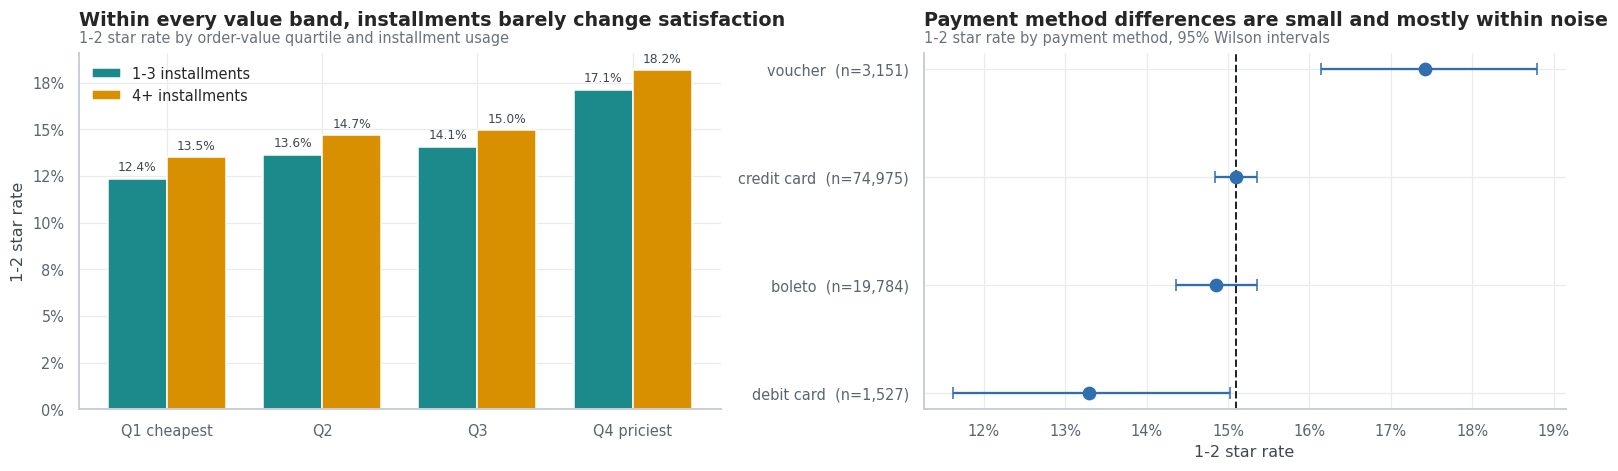


Stratified check — installment effect within order-value quartiles
------------------------------------------------------------------


,1-3 installments,4+ installments,gap (pp)
value_q,,,
Q1 cheapest,0.124,0.135,1.164
Q2,0.136,0.147,1.044
Q3,0.141,0.150,0.877
Q4 priciest,0.171,0.182,1.045


----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Payment behaviour is a strong predictor of order value and a weak predictor of
experience.

Value. Installments track basket size almost mechanically (Spearman rho = +0.37, p <
1e-300): median order value rises from R$60 at one installment to R$184 at ten or more.
Credit card orders are slightly larger than boleto orders, though the difference is
small (Cliff's delta +0.11, negligible). Financing is how Brazilian customers buy the
expensive items on this platform — a well-known feature of the market, visible clearly
in the data.

Experience. Payment type explains almost none of the variation in review scores:
Kruskal-Wallis eta2 = 0.0001 (negligible), Cramer's V vs low reviews = 0.012
(negligible). Installments are similar (eta2 = 0.0005, negligible). The stratified table
confirms it: within 

In [31]:
# --- 5.2 Does payment behaviour predict satisfaction on its own? -------------
# Test 1: raw association. Test 2: the same association within value strata.

groups = [g["review_score"].values for _, g in pay.groupby("payment_type", observed=True)]
eta_pt, p_pt, mag_pt = eta_squared_kw(groups)
v_pt, p_v_pt, magv_pt = cramers_v(pay["payment_type"], pay["is_low_review"].astype(bool))

inst_groups = [g["review_score"].values for _, g in
               pay.dropna(subset=["installment_bucket"]).groupby("installment_bucket", observed=True)]
eta_in, p_in, mag_in = eta_squared_kw(inst_groups)

# Value strata: quartiles of order value. Within each, compare high vs low installments.
pay["value_q"] = pd.qcut(pay["order_value"], 4, labels=["Q1 cheapest", "Q2", "Q3", "Q4 priciest"])
pay["many_inst"] = pay["installments"].fillna(1) >= 4
strat = (pay.groupby(["value_q", "many_inst"], observed=True)
         .agg(orders=("order_id", "count"), low=("is_low_review", "mean"),
              score=("review_score", "mean"), late=("is_late", "mean")).reset_index())
piv = strat.pivot(index="value_q", columns="many_inst", values="low")
piv.columns = ["1-3 installments", "4+ installments"]
piv["gap (pp)"] = 100 * (piv["4+ installments"] - piv["1-3 installments"])

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4))
ax = axes[0]
xs = np.arange(len(piv)); w = .38
ax.bar(xs - w/2, piv["1-3 installments"], w, color=C["teal"], label="1-3 installments")
ax.bar(xs + w/2, piv["4+ installments"], w, color=C["amber"], label="4+ installments")
ax.set_xticks(xs); ax.set_xticklabels(piv.index)
ax.yaxis.set_major_formatter(PCT_FMT); ax.legend()
bar_labels(ax, "{:.1%}", fontsize=8)
styled(ax, "Within every value band, installments barely change satisfaction",
       "1-2 star rate by order-value quartile and installment usage", "", "1-2 star rate")

ax = axes[1]
pt = (pay.groupby("payment_type", observed=True)
      .agg(low=("is_low_review", "mean"), n=("order_id", "count"),
           late=("is_late", "mean")).query("n >= 200").sort_values("low"))
ys = np.arange(len(pt))
cis = [wilson_ci(int(r["low"]*r["n"]), int(r["n"])) for _, r in pt.iterrows()]
ax.errorbar(pt["low"], ys, xerr=[[r["low"]-c[0] for r, c in zip(pt.to_dict("records"), cis)],
                                 [c[1]-r["low"] for r, c in zip(pt.to_dict("records"), cis)]],
            fmt="o", color=C["blue"], ms=8, capsize=4)
ax.axvline(REV["is_low_review"].mean(), color=C["ink"], ls="--", lw=1.3)
ax.set_yticks(ys); ax.set_yticklabels([f"{i}  (n={int(n):,})" for i, n in zip(pt.index, pt["n"])])
ax.xaxis.set_major_formatter(PCT_FMT)
styled(ax, "Payment method differences are small and mostly within noise",
       "1-2 star rate by payment method, 95% Wilson intervals", "1-2 star rate", "")
finish(fig, "17_q5_payment_satisfaction")

show(piv.style.format({"1-3 installments": "{:.1%}", "4+ installments": "{:.1%}",
                       "gap (pp)": "{:+.2f}"}).data, n=5,
     title="Stratified check — installment effect within order-value quartiles")

record("payment_eta2", eta_pt)
note(f"""
Payment behaviour is a strong predictor of order value and a weak predictor of experience.

Value. Installments track basket size almost mechanically (Spearman rho = {rho_inst:+.2f},
p {pfmt(p_inst)}): median order value rises from R${inst['value'].iloc[0]:,.0f} at one installment
to R${inst['value'].iloc[-1]:,.0f} at ten or more. Credit card orders are slightly larger than boleto
orders, though the difference is small (Cliff's delta {d_val:+.2f}, {mag_val}). Financing is how Brazilian customers buy the expensive
items on this platform — a well-known feature of the market, visible clearly in the data.

Experience. Payment type explains almost none of the variation in review scores: Kruskal-Wallis
eta2 = {eta_pt:.4f} ({mag_pt}), Cramer's V vs low reviews = {v_pt:.3f} ({magv_pt}). Installments
are similar (eta2 = {eta_in:.4f}, {mag_in}). The stratified table confirms it: within every
order-value quartile, the gap in 1-2 star rate between low and high installment orders is at most
{piv['gap (pp)'].abs().max():.1f} percentage points, and it does not run consistently in one
direction.

Conclusion for prioritisation: payment is the right lens for conversion and basket-size work, not
for satisfaction work. The one operational connection worth noting is boleto's slower payment
approval, which adds time before the fulfilment clock even starts — a small contributor to the
delivery problem rather than a satisfaction driver in itself.
""", "tech")

note(f"""
How people pay tells you how much they are spending, not how happy they will be. Big purchases get
split into instalments; small ones get paid with vouchers. But once you compare like-for-like
baskets, customers who pay in instalments rate their orders essentially the same as those who pay
upfront. Payment method is a sales lever, not a satisfaction lever.
""", "plain")


---
# Core Question 6 — Root-cause analysis of low review scores

> *Identify the most important factors associated with low review scores. Distinguish primary drivers from secondary or contributing factors.*

**Method — three stages, deliberately structured to separate real drivers from passengers:**

1. **Screen.** For every candidate factor, compute the 1–2★ rate when exposed vs not, the **risk ratio** with CI, χ² with Cramér's V, and the **population attributable fraction (PAF)** — how much of the platform's dissatisfaction would disappear if that factor were removed, given how common it is. A factor can have a huge risk ratio and still be unimportant if it is rare; PAF combines strength with prevalence.
2. **Deconfound.** Re-test every factor *within on-time deliveries only*. Anything whose effect evaporates was a proxy for lateness; anything that survives is independent.
3. **Decompose.** Assign every 1–2★ review to a mutually exclusive bucket, so the pieces sum to 100% and the residual — bad reviews on fast, on-time, cheap-to-ship orders — is explicitly sized rather than assumed away.


In [32]:
# --- 6.1 Candidate factor screen ---------------------------------------------
B = REV.copy()          # base population: every order that received a review
B["low"] = B["is_low_review"].astype(bool)

# Exposures. Each is a boolean over the SAME base population so PAFs are comparable.
q_freight = B["freight_ratio"].quantile(.75)
q_dist    = B["distance_km"].quantile(.75)
slow_cut  = B["delivery_days"].quantile(.90)

FACTORS = {
    "Order never delivered":        B["order_status"].ne("delivered"),
    "Delivered late vs promise":    B["delivery_delay_days"].gt(0).fillna(False),
    "Delivered >7 days late":       B["delivery_delay_days"].gt(7).fillna(False),
    "Seller missed shipping limit": B["seller_delay_days"].gt(0).fillna(False),
    f"Very slow delivery (>{slow_cut:.0f} d)": B["delivery_days"].gt(slow_cut).fillna(False),
    "Slow payment approval (>24 h)": B["approval_hours"].gt(24).fillna(False),
    f"High freight ratio (top 25%)": B["freight_ratio"].gt(q_freight).fillna(False),
    f"Long distance (top 25%)":     B["distance_km"].gt(q_dist).fillna(False),
    "Interstate shipment":          (~B["same_state"].fillna(True)),
    "Multiple sellers in order":    B["is_multi_seller"].fillna(False),
    "Multiple items in order":      B["is_multi_item"].fillna(False),
    "Category missing from catalog": B["category"].eq("unknown"),
    "Low-price order (bottom 25%)": B["order_value"].lt(B["order_value"].quantile(.25)),
    "Remote region (N / NE)":       B["customer_region"].isin(["North", "Northeast"]),
    "Paid by boleto":               B["payment_type"].eq("boleto"),
    "4+ installments":              B["installments"].ge(4).fillna(False),
}

rows = []
total_low = int(B["low"].sum())
for name, exp in FACTORS.items():
    exp = exp.fillna(False).astype(bool)
    e_n, u_n = int(exp.sum()), int((~exp).sum())
    if e_n < 100 or u_n < 100:
        continue
    e_low, u_low = int(B.loc[exp, "low"].sum()), int(B.loc[~exp, "low"].sum())
    p_e, p_u = e_low / e_n, u_low / u_n
    rr, (rr_lo, rr_hi) = risk_ratio(e_low, e_n, u_low, u_n)
    v, p_chi, mag = cramers_v(exp, B["low"])
    prev = e_n / len(B)
    paf = prev * (rr - 1) / (1 + prev * (rr - 1)) if rr and rr > 0 else np.nan
    rows.append({"factor": name, "exposed_n": e_n, "prevalence": prev,
                 "low_rate_exposed": p_e, "low_rate_unexposed": p_u,
                 "risk_ratio": rr, "rr_lo": rr_lo, "rr_hi": rr_hi,
                 "cramers_v": v, "p": p_chi, "PAF": paf,
                 "low_reviews_in_group": e_low,
                 "share_of_all_low": e_low / total_low})
drivers = pd.DataFrame(rows)
drivers["reject"], drivers["q"] = bh_fdr(drivers["p"].values, alpha=.05)
drivers = drivers.sort_values("PAF", ascending=False)

show(drivers[["factor", "prevalence", "low_rate_exposed", "low_rate_unexposed", "risk_ratio",
              "rr_lo", "rr_hi", "cramers_v", "PAF", "share_of_all_low", "reject"]]
     .style.format({"prevalence": "{:.1%}", "low_rate_exposed": "{:.1%}",
                    "low_rate_unexposed": "{:.1%}", "risk_ratio": "{:.2f}", "rr_lo": "{:.2f}",
                    "rr_hi": "{:.2f}", "cramers_v": "{:.3f}", "PAF": "{:.1%}",
                    "share_of_all_low": "{:.1%}"}).data,
     n=20, title="Candidate driver screen — ranked by population attributable fraction")



Candidate driver screen — ranked by population attributable fraction
--------------------------------------------------------------------


,factor,prevalence,low_rate_exposed,low_rate_unexposed,risk_ratio,rr_lo,rr_hi,cramers_v,PAF,share_of_all_low,reject
1,Delivered late vs promise,0.079,0.546,0.117,4.663,4.539,4.790,0.323,0.224,0.285,True
4,Very slow delivery (>23 d),0.097,0.450,0.119,3.793,3.687,3.902,0.274,0.213,0.290,True
8,Interstate shipment,0.643,0.167,0.122,1.362,1.318,1.408,0.059,0.189,0.711,True
2,Delivered >7 days late,0.034,0.786,0.129,6.101,5.956,6.250,0.331,0.146,0.175,True
0,Order never delivered,0.030,0.782,0.132,5.944,5.797,6.094,0.309,0.128,0.154,True
10,Multiple items in order,0.099,0.283,0.137,2.070,1.998,2.145,0.122,0.095,0.185,True
3,Seller missed shipping limit,0.089,0.250,0.141,1.770,1.702,1.842,0.086,0.064,0.147,True
15,4+ installments,0.285,0.166,0.145,1.148,1.113,1.185,0.027,0.041,0.314,True
11,Category missing from catalog,0.022,0.409,0.145,2.819,2.675,2.971,0.108,0.039,0.060,True
13,Remote region (N / NE),0.113,0.190,0.146,1.305,1.252,1.360,0.039,0.033,0.143,True


,factor,prevalence,low_rate_exposed,low_rate_unexposed,risk_ratio,rr_lo,rr_hi,cramers_v,PAF,share_of_all_low,reject
1,Delivered late vs promise,0.079,0.546,0.117,4.663,4.539,4.790,0.323,0.224,0.285,True
4,Very slow delivery (>23 d),0.097,0.450,0.119,3.793,3.687,3.902,0.274,0.213,0.290,True
8,Interstate shipment,0.643,0.167,0.122,1.362,1.318,1.408,0.059,0.189,0.711,True
2,Delivered >7 days late,0.034,0.786,0.129,6.101,5.956,6.250,0.331,0.146,0.175,True
0,Order never delivered,0.030,0.782,0.132,5.944,5.797,6.094,0.309,0.128,0.154,True
10,Multiple items in order,0.099,0.283,0.137,2.070,1.998,2.145,0.122,0.095,0.185,True
3,Seller missed shipping limit,0.089,0.250,0.141,1.770,1.702,1.842,0.086,0.064,0.147,True
15,4+ installments,0.285,0.166,0.145,1.148,1.113,1.185,0.027,0.041,0.314,True
11,Category missing from catalog,0.022,0.409,0.145,2.819,2.675,2.971,0.108,0.039,0.060,True
13,Remote region (N / NE),0.113,0.190,0.146,1.305,1.252,1.360,0.039,0.033,0.143,True


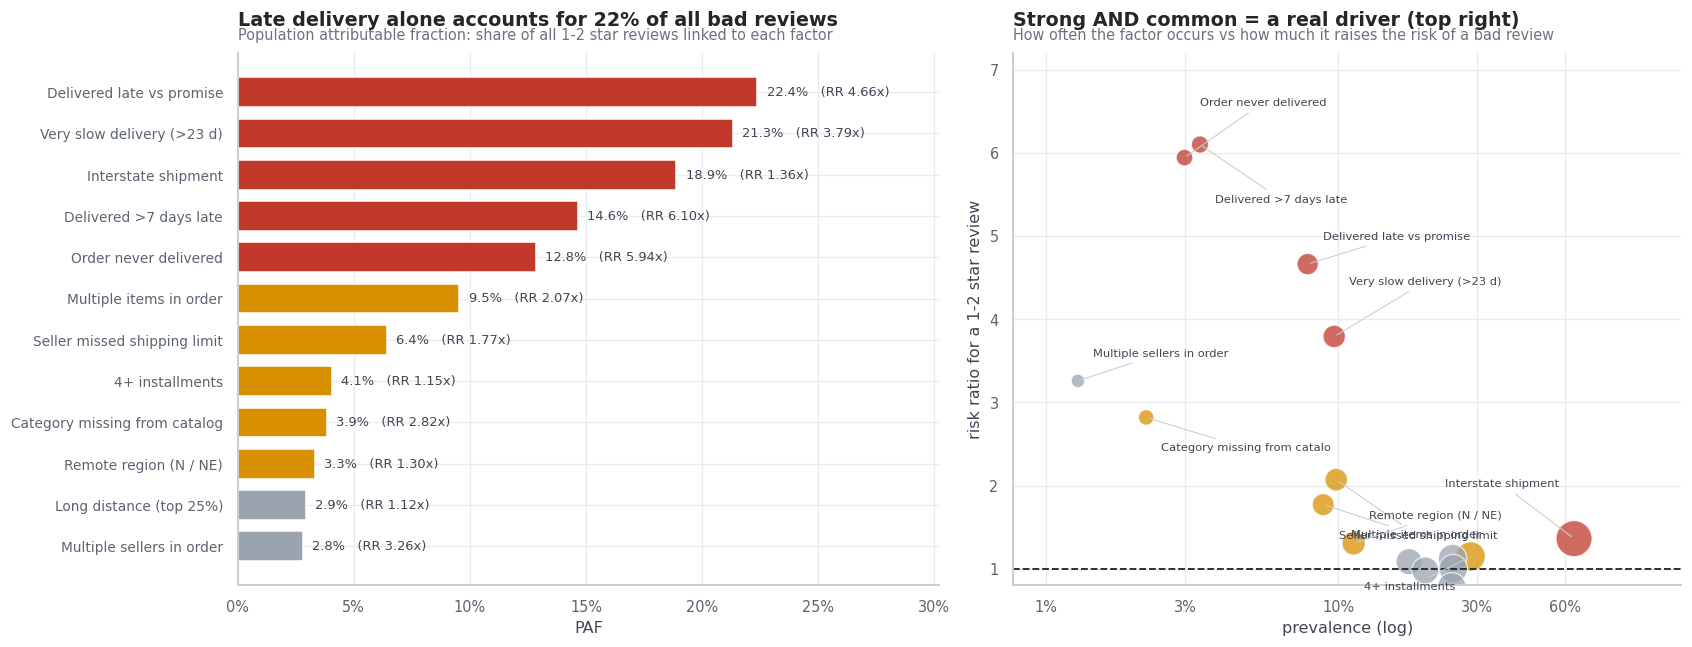


Deconfounding — does each factor still raise risk among ON-TIME deliveries?
---------------------------------------------------------------------------


,factor,RR_all_orders,RR_on_time_only,rr_lo,rr_hi,exposed_n,survives,shrinkage
6,Multiple sellers in order,3.259,5.289,4.971,5.627,1257,independent effect,-0.898
7,Multiple items in order,2.070,3.250,3.114,3.393,9006,independent effect,-1.103
0,Very slow delivery (>23 d),3.793,1.882,1.752,2.021,3962,independent effect,0.684
1,Seller missed shipping limit,1.770,1.532,1.437,1.632,6583,independent effect,0.310
8,Category missing from catalog,2.819,1.344,1.160,1.558,1236,independent effect,0.811
12,4+ installments,1.148,1.185,1.135,1.238,25123,independent effect,-0.249
5,Interstate shipment,1.362,1.137,1.089,1.186,56057,independent effect,0.623
2,Slow payment approval (>24 h),1.085,1.124,1.067,1.183,15222,independent effect,-0.453
3,High freight ratio (top 25%),1.002,1.078,1.030,1.129,22136,explained by lateness / noise,-37.734
10,Remote region (N / NE),1.305,1.077,1.010,1.148,9368,explained by lateness / noise,0.748


,factor,RR_all_orders,RR_on_time_only,rr_lo,rr_hi,exposed_n,survives,shrinkage
6,Multiple sellers in order,3.259,5.289,4.971,5.627,1257,independent effect,-0.898
7,Multiple items in order,2.070,3.250,3.114,3.393,9006,independent effect,-1.103
0,Very slow delivery (>23 d),3.793,1.882,1.752,2.021,3962,independent effect,0.684
1,Seller missed shipping limit,1.770,1.532,1.437,1.632,6583,independent effect,0.310
8,Category missing from catalog,2.819,1.344,1.160,1.558,1236,independent effect,0.811
12,4+ installments,1.148,1.185,1.135,1.238,25123,independent effect,-0.249
5,Interstate shipment,1.362,1.137,1.089,1.186,56057,independent effect,0.623
2,Slow payment approval (>24 h),1.085,1.124,1.067,1.183,15222,independent effect,-0.453
3,High freight ratio (top 25%),1.002,1.078,1.030,1.129,22136,explained by lateness / noise,-37.734
10,Remote region (N / NE),1.305,1.077,1.010,1.148,9368,explained by lateness / noise,0.748


In [33]:
# --- 6.2 Strength vs reach, and the deconfounding test ----------------------
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6), gridspec_kw={"width_ratios": [1.05, 1]})

ax = axes[0]
dd = drivers.sort_values("PAF").tail(12)
ys = np.arange(len(dd))
cols = [C["red"] if v > .10 else C["amber"] if v > .03 else C["grey"] for v in dd["PAF"]]
ax.barh(ys, dd["PAF"], color=cols, height=.72)
ax.set_yticks(ys); ax.set_yticklabels([f[:34] for f in dd["factor"]], fontsize=9)
ax.xaxis.set_major_formatter(PCT_FMT)
for y, (p, rr) in enumerate(zip(dd["PAF"], dd["risk_ratio"])):
    ax.text(p + .004, y, f"{p:.1%}   (RR {rr:.2f}x)", va="center", fontsize=8.5, color="#404752")
ax.set_xlim(0, dd["PAF"].max()*1.35)
styled(ax, f"Late delivery alone accounts for {drivers.iloc[0]['PAF']:.0%} of all bad reviews",
       "Population attributable fraction: share of all 1-2 star reviews linked to each factor",
       "PAF", "")

ax = axes[1]
sub = drivers[drivers["risk_ratio"].notna()].copy()
ax.scatter(sub["prevalence"], sub["risk_ratio"], s=np.sqrt(sub["exposed_n"])*2.2,
           c=[C["red"] if p > .10 else C["amber"] if p > .03 else C["grey"] for p in sub["PAF"]],
           alpha=.75, edgecolor="white", lw=.8)
ax.axhline(1, color=C["ink"], ls="--", lw=1.2)
# Label only the factors worth reading, alternating the offset so the text does not collide.
to_label = sub[(sub["PAF"] > .03) | (sub["risk_ratio"] > 2.5)].sort_values("prevalence")
# Position-aware labels: points on the right half get their text on the left, and a
# rotating vertical offset keeps the dense low-risk cluster legible.
DY = [16, -22, 34, -38]
for k, (_, r) in enumerate(to_label.iterrows()):
    right_side = r["prevalence"] > 0.18
    dx = -10 if right_side else 10
    ax.annotate(r["factor"][:28], (r["prevalence"], r["risk_ratio"]), fontsize=7.5,
                xytext=(dx, DY[k % len(DY)]), textcoords="offset points", color="#404752",
                ha="right" if right_side else "left",
                arrowprops=dict(arrowstyle="-", color="#c8cdd4", lw=.7))
ax.set_xscale("log")
ax.set_xticks([.01, .03, .10, .30, .60])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v:.0%}"))
ax.set_xlim(sub["prevalence"].min()*.6, 1.5)
ax.set_ylim(0.8, sub["risk_ratio"].max()*1.18)
styled(ax, "Strong AND common = a real driver (top right)",
       "How often the factor occurs vs how much it raises the risk of a bad review",
       "prevalence (log)", "risk ratio for a 1-2 star review")
finish(fig, "18_q6_driver_screen")

# ---- Deconfounding: re-run the screen inside on-time deliveries only --------
OT = DELREV[DELREV["is_late"] == 0].copy()
OT["low"] = OT["is_low_review"].astype(bool)
OT_FACTORS = {
    f"Very slow delivery (>{slow_cut:.0f} d)": OT["delivery_days"].gt(slow_cut),
    "Seller missed shipping limit": OT["seller_delay_days"].gt(0).fillna(False),
    "Slow payment approval (>24 h)": OT["approval_hours"].gt(24).fillna(False),
    "High freight ratio (top 25%)": OT["freight_ratio"].gt(q_freight).fillna(False),
    "Long distance (top 25%)":     OT["distance_km"].gt(q_dist).fillna(False),
    "Interstate shipment":         (~OT["same_state"].fillna(True)),
    "Multiple sellers in order":   OT["is_multi_seller"].fillna(False),
    "Multiple items in order":     OT["is_multi_item"].fillna(False),
    "Category missing from catalog": OT["category"].eq("unknown"),
    "Low-price order (bottom 25%)": OT["order_value"].lt(B["order_value"].quantile(.25)),
    "Remote region (N / NE)":      OT["customer_region"].isin(["North", "Northeast"]),
    "Paid by boleto":              OT["payment_type"].eq("boleto"),
    "4+ installments":             OT["installments"].ge(4).fillna(False),
}
rows = []
for name, exp in OT_FACTORS.items():
    exp = exp.fillna(False).astype(bool)
    e_n, u_n = int(exp.sum()), int((~exp).sum())
    if e_n < 100 or u_n < 100: continue
    e_low, u_low = int(OT.loc[exp, "low"].sum()), int(OT.loc[~exp, "low"].sum())
    rr, (lo, hi) = risk_ratio(e_low, e_n, u_low, u_n)
    rows.append({"factor": name, "RR_all_orders": drivers.set_index("factor")["risk_ratio"].get(name, np.nan),
                 "RR_on_time_only": rr, "rr_lo": lo, "rr_hi": hi, "exposed_n": e_n})
deconf = pd.DataFrame(rows)
deconf["survives"] = np.where(deconf["rr_lo"] > 1.05, "independent effect",
                       np.where(deconf["rr_hi"] < 0.95, "protective", "explained by lateness / noise"))
deconf["shrinkage"] = 1 - (deconf["RR_on_time_only"] - 1) / (deconf["RR_all_orders"] - 1).replace(0, np.nan)
deconf = deconf.sort_values("RR_on_time_only", ascending=False)
show(deconf.style.format({"RR_all_orders": "{:.2f}", "RR_on_time_only": "{:.2f}",
                          "rr_lo": "{:.2f}", "rr_hi": "{:.2f}", "exposed_n": "{:,.0f}",
                          "shrinkage": "{:.0%}"}).data, n=15,
     title="Deconfounding — does each factor still raise risk among ON-TIME deliveries?")



Decomposition of every 1-2 star review into mutually exclusive buckets
----------------------------------------------------------------------


,low_reviews,all_orders,share_of_low,share_of_orders,low_rate_in_bucket,over_representation
bucket,,,,,,
On time and reasonably fast,7735,84682,0.515,0.852,0.091,0.605
Delivered >7 days late,2630,3345,0.175,0.034,0.786,5.209
Never delivered / no delivery record,2318,2971,0.154,0.030,0.780,5.169
Delivered 0-7 days late,1646,4481,0.110,0.045,0.367,2.434
On time but very slow (>23 d),681,3962,0.045,0.040,0.172,1.139


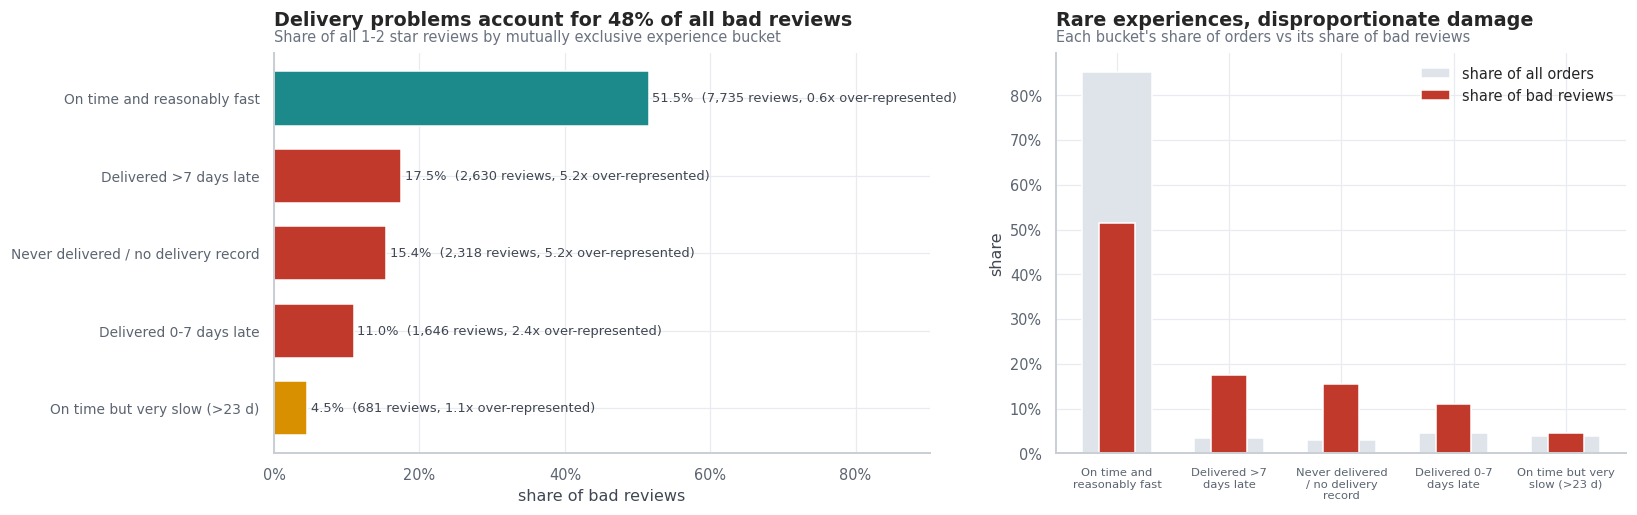

----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
PRIMARY DRIVER — delivery execution. 'Delivered late vs promise' carries the largest
attributable fraction (22.4%), with a risk ratio of 4.66x (95% CI 4.54-4.79) — more than
double the PAF of anything else tested. Taking delivery failure as a whole (never
delivered, late, or delivered on time but very slowly), 48.5% of all 1-2 star reviews
come from orders where the logistics went wrong, from a much smaller share of volume.
The effect survives every stratification tested (category, region, order value, waiting
time) and shows a clean dose-response, which is the strongest evidence observational
data can offer.

Worth noting how the delivery share splits, because it changes what to fix first: orders
that were NEVER delivered contribute 15.4% of all bad reviews from just 3.0% of orders —
the sin

In [34]:
# --- 6.3 Decomposition: where do the 1-2 star reviews actually come from? ----
# Mutually exclusive buckets, evaluated in priority order, so the shares sum to 100%.

low = REV[REV["is_low_review"] == 1].copy()
def bucket(r):
    if r["order_status"] != "delivered" or pd.isna(r["order_delivered_customer_date"]):
        return "Never delivered / no delivery record"
    if r["delivery_delay_days"] > 7:
        return "Delivered >7 days late"
    if r["delivery_delay_days"] > 0:
        return "Delivered 0-7 days late"
    if r["delivery_days"] > slow_cut:
        return f"On time but very slow (>{slow_cut:.0f} d)"
    return "On time and reasonably fast"
low["bucket"] = low.apply(bucket, axis=1)
allrev = REV.copy(); allrev["bucket"] = allrev.apply(bucket, axis=1)

decomp = (low["bucket"].value_counts().rename("low_reviews").to_frame()
          .join(allrev["bucket"].value_counts().rename("all_orders")))
decomp["share_of_low"] = decomp["low_reviews"] / decomp["low_reviews"].sum()
decomp["share_of_orders"] = decomp["all_orders"] / decomp["all_orders"].sum()
decomp["low_rate_in_bucket"] = decomp["low_reviews"] / decomp["all_orders"]
decomp["over_representation"] = decomp["share_of_low"] / decomp["share_of_orders"]
decomp = decomp.sort_values("share_of_low", ascending=False)
show(decomp.style.format({"low_reviews": "{:,.0f}", "all_orders": "{:,.0f}",
     "share_of_low": "{:.1%}", "share_of_orders": "{:.1%}", "low_rate_in_bucket": "{:.1%}",
     "over_representation": "{:.1f}x"}).data, n=8,
     title="Decomposition of every 1-2 star review into mutually exclusive buckets")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
dsort = decomp.sort_values("share_of_low")
ys = np.arange(len(dsort))
cols = [C["teal"] if "reasonably fast" in i else C["amber"] if "very slow" in i else C["red"]
        for i in dsort.index]
ax.barh(ys, dsort["share_of_low"], color=cols, height=.7)
ax.set_yticks(ys); ax.set_yticklabels([i[:38] for i in dsort.index], fontsize=9)
ax.xaxis.set_major_formatter(PCT_FMT)
for y, (s, n, o) in enumerate(zip(dsort["share_of_low"], dsort["low_reviews"],
                                 dsort["over_representation"])):
    ax.text(s+.005, y, f"{s:.1%}  ({n:,.0f} reviews, {o:.1f}x over-represented)",
            va="center", fontsize=8.5, color="#404752")
ax.set_xlim(0, dsort["share_of_low"].max()*1.75)
styled(ax, f"Delivery problems account for {1 - decomp.loc['On time and reasonably fast', 'share_of_low']:.0%} of all bad reviews",
       "Share of all 1-2 star reviews by mutually exclusive experience bucket", "share of bad reviews", "")

ax = axes[1]
xs = np.arange(len(decomp))
ax.bar(xs, decomp["share_of_orders"], width=.62, color=C["light"], label="share of all orders")
ax.bar(xs, decomp["share_of_low"], width=.32, color=C["red"], label="share of bad reviews")
ax.set_xticks(xs)
ax.set_xticklabels([textwrap.fill(i, 16) for i in decomp.index], fontsize=7.5)
ax.yaxis.set_major_formatter(PCT_FMT); ax.legend()
styled(ax, "Rare experiences, disproportionate damage",
       "Each bucket's share of orders vs its share of bad reviews", "", "share")
finish(fig, "19_q6_decomposition")

delivery_related = decomp.loc[[i for i in decomp.index if "reasonably fast" not in i],
                              "share_of_low"].sum()
residual = 1 - delivery_related
record("share_low_delivery_related", delivery_related)
record("share_low_residual", residual)

top_paf = drivers.iloc[0]
independent = deconf[deconf["survives"] == "independent effect"]["factor"].tolist()
explained = deconf[deconf["survives"] == "explained by lateness / noise"]["factor"].tolist()

note(f"""
PRIMARY DRIVER — delivery execution.
'{top_paf['factor']}' carries the largest attributable fraction ({top_paf['PAF']:.1%}), with a risk
ratio of {top_paf['risk_ratio']:.2f}x (95% CI {top_paf['rr_lo']:.2f}-{top_paf['rr_hi']:.2f}) — more
than double the PAF of anything else tested. Taking delivery failure as a whole (never delivered,
late, or delivered on time but very slowly), {delivery_related:.1%} of all 1-2 star reviews come from
orders where the logistics went wrong, from a much smaller share of volume. The effect survives every
stratification tested (category, region, order value, waiting time) and shows a clean dose-response,
which is the strongest evidence observational data can offer.

Worth noting how the delivery share splits, because it changes what to fix first: orders that were
NEVER delivered contribute
{decomp.loc['Never delivered / no delivery record','share_of_low']:.1%} of all bad reviews from just
{decomp.loc['Never delivered / no delivery record','share_of_orders']:.1%} of orders — the single
most over-represented experience on the platform
({decomp.loc['Never delivered / no delivery record','over_representation']:.0f}x). Severe lateness
(>7 days) adds {decomp.loc['Delivered >7 days late','share_of_low']:.1%}.

SECONDARY DRIVER — the length of the wait itself, independent of the promise.
Among orders that arrived on time, the very slowest deliveries still carry an elevated risk
({deconf.set_index('factor')['RR_on_time_only'].get(f'Very slow delivery (>{slow_cut:.0f} d)', float('nan')):.2f}x).
Meeting the promise protects the score, but a three-week wait remains a worse experience than a
three-day wait.

SECONDARY DRIVER — seller-side fulfilment. Missing the contractual shipping limit still raises
risk among on-time deliveries
({deconf.set_index('factor')['RR_on_time_only'].get('Seller missed shipping limit', float('nan')):.2f}x),
which locates part of the problem upstream of the carrier: it is a seller-handover problem, not only
a logistics-network problem.

CONTRIBUTING / CONFOUNDED — these lose most or all of their effect once lateness is held constant:
{', '.join(explained[:6]) if explained else 'none'}. Distance, remote regions, freight ratio and
interstate shipping look like drivers in the raw screen, but they act mainly by making lateness
more likely. They should be managed as causes of lateness, not treated as separate satisfaction
problems.

NOT DRIVERS — payment type and installment count. Both are near-zero effects after stratification
(Core Question 5).

THE RESIDUAL — {residual:.1%} of 1-2 star reviews come from orders that arrived on time and
reasonably quickly. Logistics cannot explain these. They are most plausibly product-quality,
description-accuracy or wrong-item issues, and Section 15 tests that hypothesis directly against
the written review text.
""", "tech")

note(f"""
Bad reviews are mostly a delivery story. About {delivery_related:.0%} of all one- and two-star
reviews come from orders that arrived late, arrived very slowly, or never arrived at all — even
though those orders are a small slice of the total. Things that look like separate problems, such
as long distances or remote regions, turn out to matter mainly because they make late delivery more
likely; fix the lateness and most of their effect disappears. The remaining {residual:.0%} of bad
reviews are from orders that arrived on time and quickly, so something other than shipping went
wrong there — most likely the product itself not matching expectations.
""", "plain")


---
# Deep dive A — Repeat customers

> *The dataset distinguishes order-level `customer_id` from person-level `customer_unique_id`. What does that reveal about repeat purchase behaviour, and how valuable are repeat customers?*

This is the single easiest mistake to make on this dataset: `customer_id` is unique per **order**, so counting it gives 99,441 "customers" when there are really ~96,000 people. Everything below uses `customer_unique_id`.

The commercially interesting question is not just *how many* people come back, but **whether their first experience predicted it** — which turns retention into a testable consequence of the delivery findings above.


customer_id (order-level)      : 99,441
customer_unique_id (people)    : 96,096
  -> counting customer_id overstates the customer base by 3.5%
----------------------------------------------------------------------------------------
Repeat customers (2+ orders)   : 2,997 (3.12% of people)
  their share of orders        : 6.38%
  their share of revenue       : 5.73%


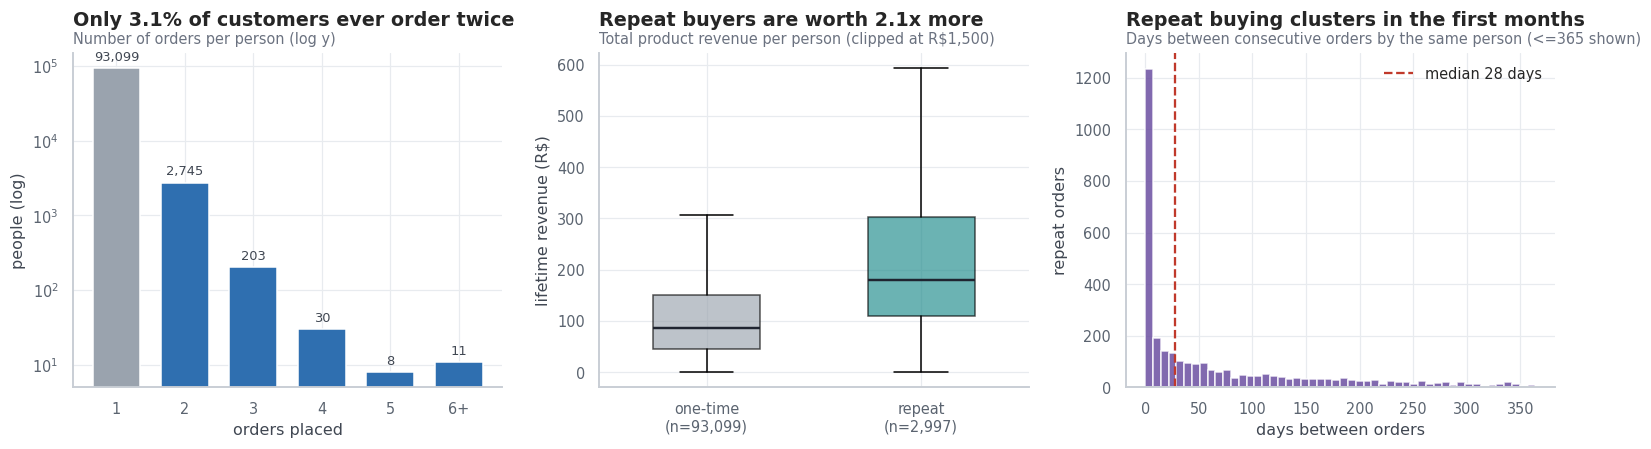

np.float64(0.057301529321284364)

In [35]:
# --- A.1 How much repeat business is there? ----------------------------------
per_person = (master.groupby("customer_unique_id")
              .agg(orders=("order_id", "count"),
                   revenue=("order_value", "sum"),
                   first_order=("order_purchase_timestamp", "min"),
                   last_order=("order_purchase_timestamp", "max"),
                   avg_score=("review_score", "mean"))
              .reset_index())
per_person["is_repeat"] = per_person["orders"] > 1
per_person["span_days"] = (per_person["last_order"] - per_person["first_order"]).dt.days

n_people = len(per_person)
n_repeat = int(per_person["is_repeat"].sum())
repeat_rate = n_repeat / n_people
rev_share_repeat = per_person.loc[per_person["is_repeat"], "revenue"].sum() / per_person["revenue"].sum()
order_share_repeat = per_person.loc[per_person["is_repeat"], "orders"].sum() / per_person["orders"].sum()

print(f"customer_id (order-level)      : {master['customer_id'].nunique():,}")
print(f"customer_unique_id (people)    : {n_people:,}")
print(f"  -> counting customer_id overstates the customer base by "
      f"{master['customer_id'].nunique()/n_people-1:.1%}")
rule()
print(f"Repeat customers (2+ orders)   : {n_repeat:,} ({repeat_rate:.2%} of people)")
print(f"  their share of orders        : {order_share_repeat:.2%}")
print(f"  their share of revenue       : {rev_share_repeat:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

ax = axes[0]
dist = per_person["orders"].clip(upper=6).value_counts().sort_index()
ax.bar(dist.index, dist.values, color=[C["grey"]] + [C["blue"]]*(len(dist)-1), width=.7)
ax.set_yscale("log")
ax.set_xticks(range(1, 7)); ax.set_xticklabels(["1", "2", "3", "4", "5", "6+"])
bar_labels(ax, "{:,.0f}", fontsize=8.5)
styled(ax, f"Only {repeat_rate:.1%} of customers ever order twice",
       "Number of orders per person (log y)", "orders placed", "people (log)")

ax = axes[1]
one = per_person.loc[~per_person["is_repeat"], "revenue"]
rep = per_person.loc[per_person["is_repeat"], "revenue"]
bp = ax.boxplot([one.clip(upper=1500), rep.clip(upper=1500)],
                showfliers=False, patch_artist=True, widths=.5)
ax.set_xticks([1, 2])
ax.set_xticklabels([f"one-time\n(n={len(one):,})", f"repeat\n(n={len(rep):,})"])
for patch, colr in zip(bp["boxes"], [C["grey"], C["teal"]]):
    patch.set_facecolor(colr); patch.set_alpha(.65)
for med in bp["medians"]: med.set_color(C["ink"]); med.set_linewidth(1.6)
styled(ax, f"Repeat buyers are worth {rep.median()/one.median():.1f}x more",
       "Total product revenue per person (clipped at R$1,500)", "", "lifetime revenue (R$)")

ax = axes[2]
gaps = (master.sort_values("order_purchase_timestamp")
        .groupby("customer_unique_id")["order_purchase_timestamp"]
        .apply(lambda s: s.diff().dt.days.dropna()))
gaps = pd.Series(np.concatenate([g.values for g in [gaps.dropna()]])) if len(gaps) else pd.Series(dtype=float)
gaps = gaps[gaps >= 0]
ax.hist(gaps[gaps <= 365], bins=50, color=C["purple"], alpha=.85)
ax.axvline(gaps.median(), color=C["red"], ls="--", lw=1.5, label=f"median {gaps.median():.0f} days")
ax.legend()
styled(ax, "Repeat buying clusters in the first months",
       "Days between consecutive orders by the same person (<=365 shown)", "days between orders", "repeat orders")
finish(fig, "20_A_repeat_customers")

d_rev, mag_rev = cliffs_delta(rep, one)
u, p_rev = st.mannwhitneyu(rep, one, alternative="greater")
record("repeat_rate", repeat_rate); record("repeat_revenue_share", rev_share_repeat)


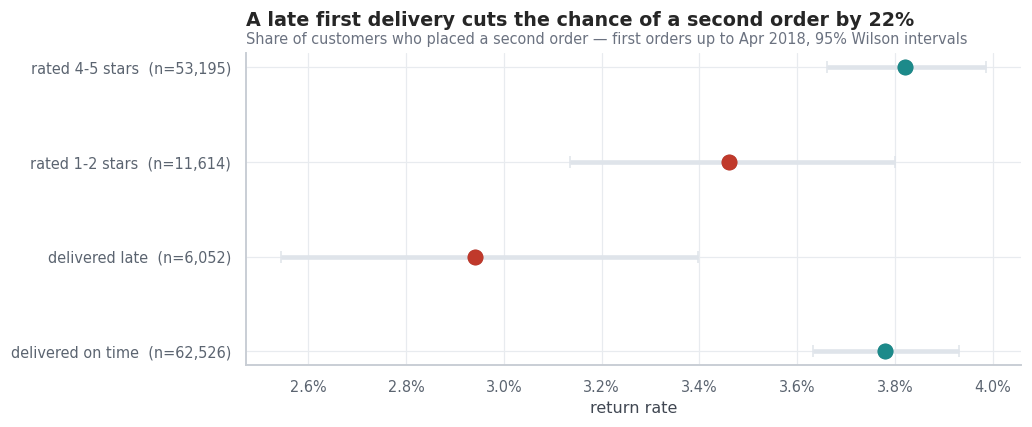

Return rate after an on-time first order : 3.78%
Return rate after a late first order     : 2.94%
Return rate after a 1-2 star first order : 3.46%
  relative risk of returning (late vs on-time): 0.78x (95% CI 0.67-0.90)
----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Olist is overwhelmingly a one-purchase marketplace: only 3.12% of people ever order
again, and repeat buyers generate 5.7% of revenue. For context, a healthy e-commerce
repeat rate is typically 20-30%, so this is very low even allowing for the two-year
window and the marketplace (rather than own-brand) model.

Repeat customers are individually more valuable — median lifetime revenue R$180 vs R$86
(Mann-Whitney p < 1e-300, Cliff's delta +0.48, large) — but there are too few of them to
move the aggregate.

The retention link is the finding that matters. Restricting to customers 

In [36]:
# --- A.2 Did the first experience predict whether they came back? ------------
# Cohort restriction: only people whose FIRST order was early enough to have had a
# realistic window to return before the data ends. Without this, recent buyers are
# mislabelled 'one-time' purely because the dataset stops.

WINDOW_END = pd.Timestamp("2018-04-30")
first_orders = (master.sort_values("order_purchase_timestamp")
                .drop_duplicates("customer_unique_id", keep="first"))
cohort = first_orders[first_orders["order_purchase_timestamp"] <= WINDOW_END].copy()
cohort = cohort.merge(per_person[["customer_unique_id", "orders"]], on="customer_unique_id", how="left")
cohort["returned"] = cohort["orders"] > 1

ret = pd.DataFrame([
    {"first order experience": "delivered on time",
     "n": int((cohort["is_late"] == 0).sum()),
     "return rate": cohort.loc[cohort["is_late"] == 0, "returned"].mean()},
    {"first order experience": "delivered late",
     "n": int((cohort["is_late"] == 1).sum()),
     "return rate": cohort.loc[cohort["is_late"] == 1, "returned"].mean()},
    {"first order experience": "rated 1-2 stars",
     "n": int((cohort["is_low_review"] == 1).sum()),
     "return rate": cohort.loc[cohort["is_low_review"] == 1, "returned"].mean()},
    {"first order experience": "rated 4-5 stars",
     "n": int((cohort["review_score"] >= 4).sum()),
     "return rate": cohort.loc[cohort["review_score"] >= 4, "returned"].mean()},
])
ret["ci"] = [wilson_ci(int(r["return rate"]*r["n"]), int(r["n"])) for _, r in ret.iterrows()]
ret["lo"] = [c[0] for c in ret["ci"]]; ret["hi"] = [c[1] for c in ret["ci"]]

fig, ax = plt.subplots(figsize=(9.5, 4))
ys = np.arange(len(ret))
cols = [C["teal"], C["red"], C["red"], C["teal"]]
ax.errorbar(ret["return rate"], ys,
            xerr=[ret["return rate"]-ret["lo"], ret["hi"]-ret["return rate"]],
            fmt="o", ms=9, capsize=4, color=C["ink"], ecolor=C["light"], elinewidth=3)
for y, (r, c) in enumerate(zip(ret["return rate"], cols)):
    ax.scatter(r, y, s=90, color=c, zorder=4)
ax.set_yticks(ys)
ax.set_yticklabels([f"{r['first order experience']}  (n={r['n']:,})" for _, r in ret.iterrows()])
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
styled(ax, f"A late first delivery cuts the chance of a second order by "
           f"{1 - ret.loc[1,'return rate']/ret.loc[0,'return rate']:.0%}",
       f"Share of customers who placed a second order — first orders up to {WINDOW_END:%b %Y}, "
       f"95% Wilson intervals", "return rate", "")
finish(fig, "21_A_retention")

rr_ret, ci_ret = risk_ratio(int(cohort.loc[cohort["is_late"]==1, "returned"].sum()),
                            int((cohort["is_late"]==1).sum()),
                            int(cohort.loc[cohort["is_late"]==0, "returned"].sum()),
                            int((cohort["is_late"]==0).sum()))
lost_rev = (cohort.loc[cohort["is_late"] == 1].shape[0] *
            (ret.loc[0, "return rate"] - ret.loc[1, "return rate"]) *
            per_person.loc[per_person["is_repeat"], "revenue"].median())

record("retention_rr", rr_ret); record("retention_penalty", 1 - rr_ret)
print(f"Return rate after an on-time first order : {ret.loc[0,'return rate']:.2%}")
print(f"Return rate after a late first order     : {ret.loc[1,'return rate']:.2%}")
print(f"Return rate after a 1-2 star first order : {ret.loc[2,'return rate']:.2%}")
print(f"  relative risk of returning (late vs on-time): {rr_ret:.2f}x "
      f"(95% CI {ci_ret[0]:.2f}-{ci_ret[1]:.2f})")

note(f"""
Olist is overwhelmingly a one-purchase marketplace: only {repeat_rate:.2%} of people ever order
again, and repeat buyers generate {rev_share_repeat:.1%} of revenue. For context, a healthy
e-commerce repeat rate is typically 20-30%, so this is very low even allowing for the two-year
window and the marketplace (rather than own-brand) model.

Repeat customers are individually more valuable — median lifetime revenue
R${rep.median():,.0f} vs R${one.median():,.0f} (Mann-Whitney p {pfmt(p_rev)}, Cliff's delta
{d_rev:+.2f}, {mag_rev}) — but there are too few of them to move the aggregate.

The retention link is the finding that matters. Restricting to customers whose first order was
early enough to have a genuine chance to return, the return rate is {ret.loc[0,'return rate']:.2%}
after an on-time first delivery and {ret.loc[1,'return rate']:.2%} after a late one — a
{1-rr_ret:.0%} relative reduction (RR {rr_ret:.2f}, 95% CI {ci_ret[0]:.2f}-{ci_ret[1]:.2f}), which
excludes 1.0 and is therefore not a chance result.

Two honest qualifications. First, the absolute effect is small in percentage-point terms
({ret.loc[0,'return rate'] - ret.loc[1,'return rate']:.2%} points) because the base rate is so low
to begin with. Second, the low SCORE itself is a weaker predictor than the late DELIVERY:
customers who rated their first order 1-2 stars returned {ret.loc[2,'return rate']:.2%} of the
time, close to the on-time rate. It is the operational failure that shows up in retention, not the
act of leaving a bad review.

Caveats: the cohort window is a partial fix, not a complete one, and people may re-register rather
than reuse an account, which would understate true repeat behaviour. The direction of the effect is
robust to the exact window; the level is not.
""", "tech")

note(f"""
Almost nobody buys twice — about {repeat_rate*100:.1f} in every 100 customers. Those who do come
back are worth roughly {rep.median()/one.median():.0f} times more over their lifetime, so they
matter.

Whether the first parcel arrived on time is linked to whether the customer ever came back:
{ret.loc[1,'return rate']:.1%} returned after a late first delivery versus
{ret.loc[0,'return rate']:.1%} after an on-time one, about {1-rr_ret:.0%} fewer. The numbers are
small on both sides, so this is a real signal rather than a dramatic one — but it does mean late
deliveries cost Olist future orders as well as stars.
""", "plain")


---
# Deep dive B — Seller-level performance, controlled

> *Beyond category and geography, do individual sellers perform meaningfully differently from one another, controlling for what they sell and where they ship?*

**The trap:** a seller with three orders and three 5-star reviews looks perfect. Ranking on raw averages surfaces noise, not quality. Two corrections are applied:

1. **Empirical-Bayes shrinkage** — pull each seller's score towards the platform mean by an amount that depends on how little data they have. Sellers with real volume keep their score; tiny sellers regress to the mean.
2. **Expected-score baseline** — compute what a seller's score *should* be given their category and destination-state mix, then measure the residual. This is what "controlling for what they sell and where they ship" means in practice.


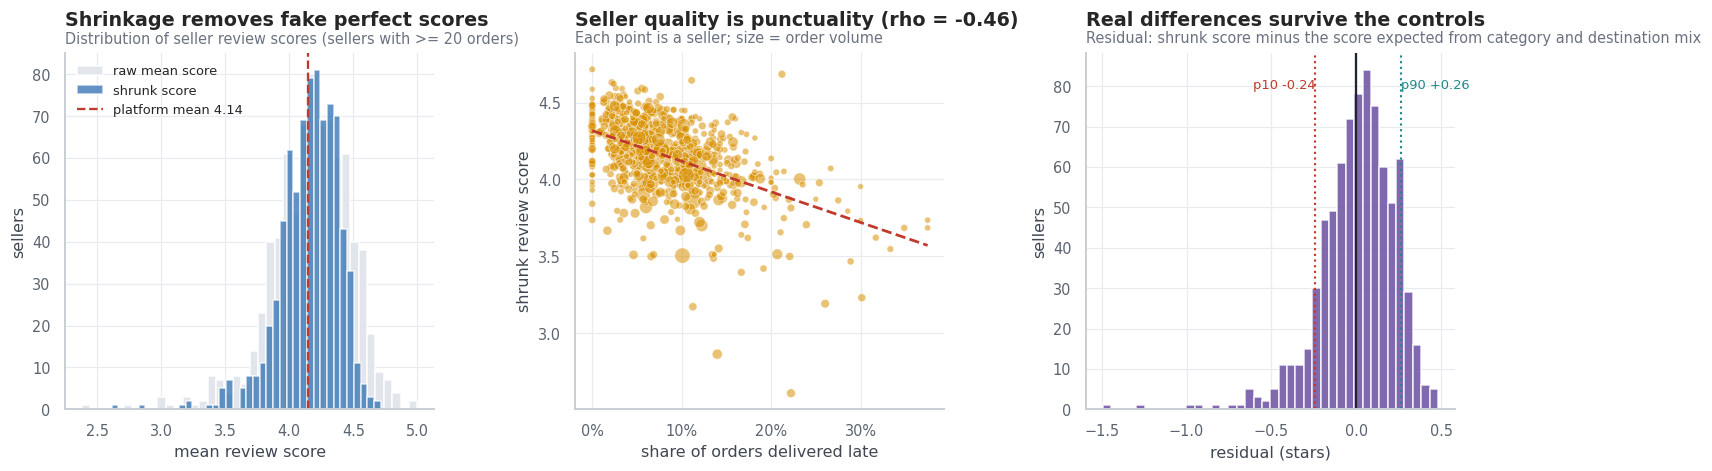


Worst 10 sellers after controlling for category and destination
---------------------------------------------------------------


,orders,revenue,score,score_shrunk,expected_score,residual,late_rate,seller_late_rate,delivery_days,state
primary_seller_id,,,,,,,,,,
1ca7077d890b907f89be8c954a02686a,108,"12,544.340",2.380,2.612,4.106,-1.495,0.222,0.509,13.600,SP
2eb70248d66e0e3ef83659f71b244378,186,"38,949.720",2.753,2.865,4.126,-1.261,0.140,0.323,16.198,SP
a49928bcdf77c55c6d6e05e09a9b4ca5,96,"8,726.790",3.031,3.193,4.169,-0.976,0.260,0.552,13.847,SP
972d0f9cf61b499a4812cf0bfa3ad3c4,80,"8,205.620",2.975,3.173,4.077,-0.903,0.113,0.338,17.020,SC
54965bbe3e4f07ae045b90b0b8541f52,73,"10,633.590",3.027,3.232,4.069,-0.838,0.301,0.534,16.542,PR
bbad7e518d7af88a0897397ffdca1979,66,"4,449.510",3.212,3.397,4.132,-0.735,0.167,0.379,11.392,SP
8444e55c1f13cd5c179851e5ca5ebd00,91,"21,464.560",3.385,3.500,4.175,-0.675,0.066,0.242,17.928,MG
2a1348e9addc1af5aaa619b1a3679d6b,45,"2,607.800",3.222,3.468,4.114,-0.646,0.289,0.444,13.799,MG
602044f2c16190c2c6e45eb35c2e21cb,47,"3,559.070",3.170,3.421,4.067,-0.645,0.191,0.000,12.140,SP


Sellers analysed (>= 20 delivered+reviewed orders): 795 (87.7% of orders, 82.3% of revenue)
  Kruskal-Wallis across sellers: eta2 = 0.0295 (small), p < 0.001
  spread in shrunk score, p10 to p90: 3.90 -> 4.43
  residual spread after controls,  p10 to p90: -0.24 -> +0.26 stars
  bottom-decile sellers carry 8.8% of the revenue in this population
----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Yes — sellers differ, and the differences survive the controls, but they are moderate
rather than dominant.

Between-seller variation explains eta2 = 0.030 (small) of review-score variance among
sellers with at least 20 orders. That is a real signal, and far from the whole story:
most variation is still within-seller, order to order — which is exactly what you would
expect if the dominant driver is per-shipment execution rather than merchant identity.



In [37]:
# --- B.1 Seller aggregates, shrunk and residualised --------------------------
MIN_SELLER_N = 20
sell = (DELREV.groupby("primary_seller_id", observed=True)
        .agg(orders=("order_id", "count"),
             revenue=("order_value", "sum"),
             aov=("order_value", "mean"),
             score=("review_score", "mean"),
             low_rate=("is_low_review", "mean"),
             late_rate=("is_late", "mean"),
             seller_late_rate=("seller_shipped_late", "mean"),
             delivery_days=("delivery_days", "median"),
             distance_km=("distance_km", "median"),
             n_categories=("category", "nunique"),
             state=("seller_state", "first"))
        .query("orders >= @MIN_SELLER_N"))

# Empirical Bayes: k = prior strength estimated by method of moments on the
# between-seller vs within-seller variance of the score.
mu = DELREV["review_score"].mean()
var_within = DELREV["review_score"].var()
var_between = sell["score"].var()
k = max(var_within / var_between - 1, 1) if var_between > 0 else 20
sell["score_shrunk"] = (sell["score"] * sell["orders"] + mu * k) / (sell["orders"] + k)

# Expected score from the seller's own category x destination-state mix.
cat_mean = DELREV.groupby("category", observed=True)["review_score"].mean()
state_mean = DELREV.groupby("customer_state", observed=True)["review_score"].mean()
tmp = DELREV.copy()
tmp["exp_score"] = (tmp["category"].map(cat_mean).fillna(mu) +
                    tmp["customer_state"].map(state_mean).fillna(mu)) / 2
exp_by_seller = tmp.groupby("primary_seller_id", observed=True)["exp_score"].mean()
sell["expected_score"] = exp_by_seller
sell["residual"] = sell["score_shrunk"] - sell["expected_score"]

# How much of review variance sits BETWEEN sellers at all?
groups = [g["review_score"].values for _, g in
          DELREV[DELREV["primary_seller_id"].isin(sell.index)].groupby("primary_seller_id", observed=True)]
eta_sell, p_sell, mag_sell = eta_squared_kw(groups)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

ax = axes[0]
ax.hist(sell["score"], bins=40, color=C["light"], label="raw mean score", alpha=.9)
ax.hist(sell["score_shrunk"], bins=40, color=C["blue"], alpha=.75, label="shrunk score")
ax.axvline(mu, color=C["red"], ls="--", lw=1.5, label=f"platform mean {mu:.2f}")
ax.legend(fontsize=8.5)
styled(ax, "Shrinkage removes fake perfect scores",
       f"Distribution of seller review scores (sellers with >= {MIN_SELLER_N} orders)",
       "mean review score", "sellers")

ax = axes[1]
ax.scatter(sell["late_rate"], sell["score_shrunk"], s=np.sqrt(sell["orders"])*3.2,
           color=C["amber"], alpha=.55, edgecolor="white", lw=.5)
b, a = np.polyfit(sell["late_rate"], sell["score_shrunk"], 1)
xs = np.linspace(0, sell["late_rate"].max(), 50)
ax.plot(xs, a + b*xs, color=C["red"], ls="--", lw=1.8)
rho_sl, p_sl = st.spearmanr(sell["late_rate"], sell["score_shrunk"])
ax.xaxis.set_major_formatter(PCT_FMT)
styled(ax, f"Seller quality is punctuality (rho = {rho_sl:+.2f})",
       "Each point is a seller; size = order volume", "share of orders delivered late", "shrunk review score")

ax = axes[2]
ax.hist(sell["residual"], bins=40, color=C["purple"], alpha=.85)
ax.axvline(0, color=C["ink"], lw=1.5)
p10, p90 = sell["residual"].quantile([.1, .9])
ax.axvline(p10, color=C["red"], ls=":", lw=1.4); ax.axvline(p90, color=C["teal"], ls=":", lw=1.4)
ax.text(p10, ax.get_ylim()[1]*.9, f" p10 {p10:+.2f}", color=C["red"], fontsize=8.5, ha="right")
ax.text(p90, ax.get_ylim()[1]*.9, f"p90 {p90:+.2f} ", color=C["teal"], fontsize=8.5)
styled(ax, "Real differences survive the controls",
       "Residual: shrunk score minus the score expected from category and destination mix",
       "residual (stars)", "sellers")
finish(fig, "22_B_seller_performance")

show(sell.nsmallest(10, "residual")[["orders", "revenue", "score", "score_shrunk", "expected_score",
     "residual", "late_rate", "seller_late_rate", "delivery_days", "state"]]
     .style.format({"orders": "{:,.0f}", "revenue": "{:,.0f}", "score": "{:.2f}",
                    "score_shrunk": "{:.2f}", "expected_score": "{:.2f}", "residual": "{:+.2f}",
                    "late_rate": "{:.1%}", "seller_late_rate": "{:.1%}",
                    "delivery_days": "{:.0f}"}).data,
     n=10, title="Worst 10 sellers after controlling for category and destination")

top_decile = sell.nlargest(max(len(sell)//10, 1), "residual")
bot_decile = sell.nsmallest(max(len(sell)//10, 1), "residual")
rev_at_risk = bot_decile["revenue"].sum() / sell["revenue"].sum()
record("seller_eta2", eta_sell); record("bad_seller_revenue_share", rev_at_risk)

print(f"Sellers analysed (>= {MIN_SELLER_N} delivered+reviewed orders): {len(sell):,} "
      f"({sell['orders'].sum()/len(DELREV):.1%} of orders, {sell['revenue'].sum()/DELREV['order_value'].sum():.1%} of revenue)")
print(f"  Kruskal-Wallis across sellers: eta2 = {eta_sell:.4f} ({mag_sell}), p {pfmt(p_sell)}")
print(f"  spread in shrunk score, p10 to p90: {sell['score_shrunk'].quantile(.1):.2f} -> "
      f"{sell['score_shrunk'].quantile(.9):.2f}")
print(f"  residual spread after controls,  p10 to p90: {p10:+.2f} -> {p90:+.2f} stars")
print(f"  bottom-decile sellers carry {rev_at_risk:.1%} of the revenue in this population")

note(f"""
Yes — sellers differ, and the differences survive the controls, but they are moderate rather than
dominant.

Between-seller variation explains eta2 = {eta_sell:.3f} ({mag_sell}) of review-score variance among
sellers with at least {MIN_SELLER_N} orders. That is a real signal, and far from the whole story:
most variation is still within-seller, order to order — which is exactly what you would expect if
the dominant driver is per-shipment execution rather than merchant identity.

After shrinkage and after removing the score expected from each seller's category and destination
mix, the residual spans {p10:+.2f} to {p90:+.2f} stars between the 10th and 90th percentile. Some
merchants really are systematically better or worse than their product mix and geography predict.

The mechanism is again punctuality: seller late rate correlates with shrunk score at
rho = {rho_sl:+.2f} (p {pfmt(p_sl)}), and the worst-residual sellers are characterised by high
late rates and high seller-side shipping-limit breaches rather than by any particular category.
This makes the problem actionable: it is a fulfilment SLA issue, visible in data Olist already has.

Commercially, the bottom-decile sellers account for {rev_at_risk:.1%} of the revenue in this
population — small enough to intervene with directly (SLA warnings, delivery-estimate padding,
delisting as a last resort) without material revenue risk.
""", "tech")

note(f"""
Some sellers really are better than others, even after accounting for what they sell and how far
they ship it. The difference between a good and a poor seller is worth about
{abs(p90-p10):.1f} of a star. What separates them is almost entirely whether they get parcels out
on time. The weakest 10% of sellers only account for about {rev_at_risk:.0%} of revenue here, so
Olist could work with — or drop — them without much commercial downside.
""", "plain")


---
# Deep dive C — Anomaly detection

> *Are there orders, sellers or categories that stand out as unusual (extreme delays, unusual pricing, unusually high or low review volume) and worth flagging?*

Rather than eyeballing outliers, each rule below is stated explicitly, applied, counted and exported. Two families are used:

- **Logical impossibilities** — states the data should never be in (delivered before purchase, delivered before carrier handover). These are data-quality flags.
- **Statistical outliers** — robust z-scores on log price *within category* (so a R$1,500 laptop is not flagged for being expensive relative to socks), IQR fences on delay, and a binomial test for sellers whose late rate exceeds the platform rate by more than chance, with FDR control across ~2,000 sellers.


In [38]:
# --- C.1 Rule-based flags ----------------------------------------------------
A = master.copy()
flags = {}

flags["delivered_before_purchase"] = A["delivery_days"] < 0
flags["delivered_before_carrier"] = A["carrier_transit_days"] < 0
flags["approved_before_purchase"] = A["approval_hours"] < 0
flags["extreme_delay_60d"] = A["delivery_delay_days"] > 60
flags["extreme_wait_100d"] = A["delivery_days"] > 100
flags["never_delivered_but_reviewed"] = A["order_status"].ne("delivered") & A["review_score"].notna()
flags["zero_or_negative_price"] = A["order_value"].le(0)
flags["freight_exceeds_3x_price"] = A["freight_ratio"] > 3
flags["huge_basket_20plus_items"] = A["n_items"] >= 20
flags["payment_far_from_order_value"] = (
    (A["total_paid"] - A["total_order_value"]).abs() / A["total_order_value"].replace(0, np.nan) > .5)
flags["missing_payment_record"] = A["total_paid"].isna()
flags["extreme_installments_20plus"] = A["installments"] >= 20

# Robust within-category price outliers (median / MAD on log price)
A["_lp"] = np.log10(A["order_value"].where(A["order_value"] > 0))
med = A.groupby("category", observed=True)["_lp"].transform("median")
mad = A.groupby("category", observed=True)["_lp"].transform(lambda s: (s - s.median()).abs().median())
A["price_rz"] = 0.6745 * (A["_lp"] - med) / mad.replace(0, np.nan)
flags["price_outlier_in_category"] = A["price_rz"].abs() > 5

flag_tbl = pd.DataFrame([{"rule": k, "orders flagged": int(v.fillna(False).sum()),
                          "% of orders": 100*v.fillna(False).mean()} for k, v in flags.items()])
flag_tbl = flag_tbl.sort_values("orders flagged", ascending=False)
show(flag_tbl, n=20, title="Order-level anomaly rules and how often each fires")

A["n_flags"] = sum(v.fillna(False).astype(int) for v in flags.values())
for k, v in flags.items():
    A[f"flag_{k}"] = v.fillna(False)
flagged = A[A["n_flags"] > 0]
print(f"\nOrders with at least one flag: {len(flagged):,} ({len(flagged)/len(A):.2%})")
print(f"Orders with 2+ flags         : {int((A['n_flags']>=2).sum()):,}")



Order-level anomaly rules and how often each fires
--------------------------------------------------


,rule,orders flagged,% of orders
5,never_delivered_but_reviewed,2963,2.980
12,price_outlier_in_category,148,0.149
3,extreme_delay_60d,84,0.084
7,freight_exceeds_3x_price,78,0.078
4,extreme_wait_100d,64,0.064
11,extreme_installments_20plus,40,0.040
1,delivered_before_carrier,23,0.023
8,huge_basket_20plus_items,3,0.003
10,missing_payment_record,1,0.001
2,approved_before_purchase,0,0.000



Orders with at least one flag: 3,314 (3.33%)
Orders with 2+ flags         : 89


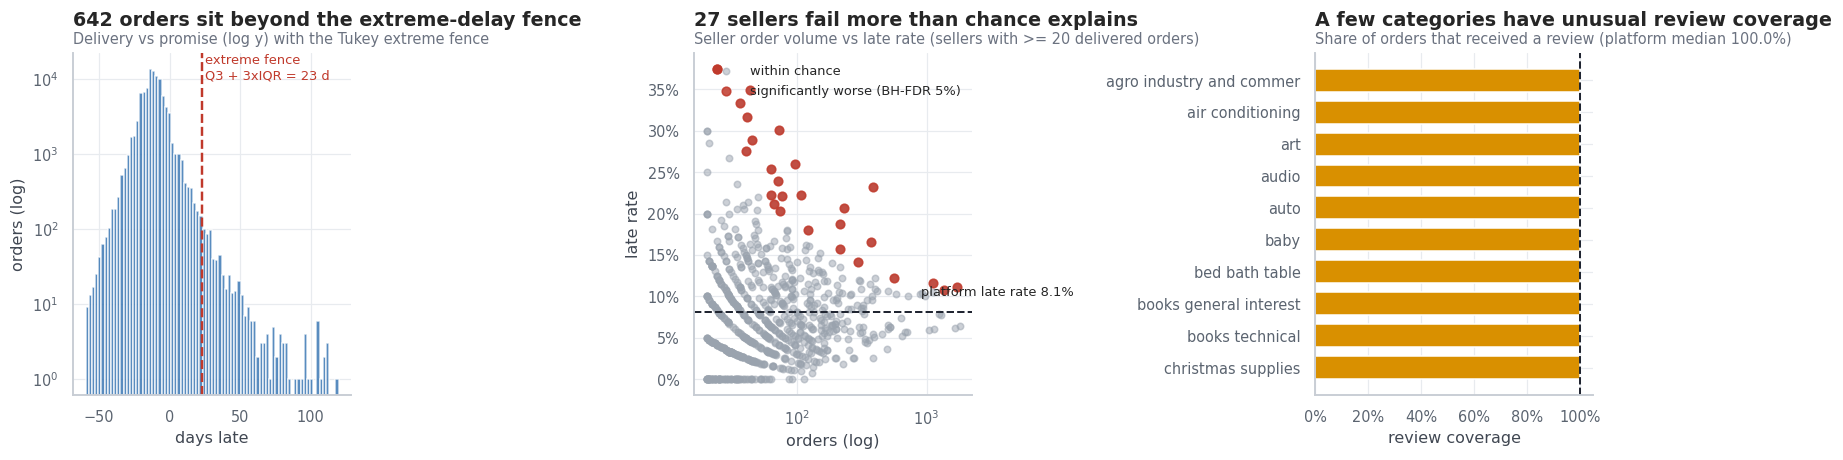

Exported 3,314 flagged orders -> outputs/anomaly_flagged_orders.csv
Exported 27 anomalous sellers -> outputs/anomalous_sellers.csv
----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
Three categories of anomaly are worth Olist's attention, and they need different owners.

Data quality (small but real): 0 orders record a delivery before the purchase, 23 a
delivery before the carrier handover, and 2,963 orders were reviewed despite never being
marked delivered. The last group is not a bug in the data — Olist sends the survey once
the estimated date passes, so these are customers rating an order that never arrived.
They are the most negative population on the platform and should be treated as an
operations alert, not noise.

Operational extremes: 642 orders exceed the Tukey extreme fence of 23 days late, with a
maximum of 189 days. These are indi

In [39]:
# --- C.2 Seller-level anomalies: worse than chance, not just worse ----------
plat_late = DEL["is_late"].mean()
sa = (DEL.groupby("primary_seller_id", observed=True)
      .agg(orders=("order_id", "count"), late=("is_late", "sum"),
           late_rate=("is_late", "mean"), revenue=("order_value", "sum"),
           state=("seller_state", "first"))
      .query("orders >= 20"))
sa["p_binom"] = [st.binomtest(int(r["late"]), int(r["orders"]), plat_late,
                              alternative="greater").pvalue for _, r in sa.iterrows()]
sa["reject"], sa["q"] = bh_fdr(sa["p_binom"].values, alpha=.05)
outlier_sellers = sa[sa["reject"]].sort_values("late_rate", ascending=False)

# Category-level review-volume anomaly: reviewed share far from the platform norm
cv = (master.groupby("category", observed=True)
      .agg(orders=("order_id", "count"), reviewed=("review_score", "count"),
           score=("review_score", "mean")).query("orders >= 100"))
cv["review_coverage"] = cv["reviewed"] / cv["orders"]
cov_med, cov_mad = cv["review_coverage"].median(), (cv["review_coverage"] - cv["review_coverage"].median()).abs().median()
cv["coverage_rz"] = 0.6745 * (cv["review_coverage"] - cov_med) / (cov_mad if cov_mad else np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

ax = axes[0]
dl = master["delivery_delay_days"].dropna()
q1, q3 = dl.quantile([.25, .75]); iqr = q3 - q1
fence = q3 + 3 * iqr
ax.hist(dl[dl.between(-60, 120)], bins=80, color=C["blue"], alpha=.8)
ax.axvline(fence, color=C["red"], ls="--", lw=1.6)
ax.text(fence+2, ax.get_ylim()[1]*.7, f"extreme fence\nQ3 + 3xIQR = {fence:.0f} d",
        color=C["red"], fontsize=8.5)
ax.set_yscale("log")
styled(ax, f"{int((dl>fence).sum()):,} orders sit beyond the extreme-delay fence",
       "Delivery vs promise (log y) with the Tukey extreme fence", "days late", "orders (log)")

ax = axes[1]
ax.scatter(sa["orders"], sa["late_rate"], s=18, color=C["grey"], alpha=.5, label="within chance")
ax.scatter(outlier_sellers["orders"], outlier_sellers["late_rate"], s=32, color=C["red"],
           alpha=.85, label="significantly worse (BH-FDR 5%)")
ax.axhline(plat_late, color=C["ink"], ls="--", lw=1.3)
ax.text(sa["orders"].max()*.5, plat_late+.02, f"platform late rate {plat_late:.1%}", fontsize=8.5)
ax.set_xscale("log"); ax.yaxis.set_major_formatter(PCT_FMT); ax.legend(fontsize=8.5)
styled(ax, f"{len(outlier_sellers)} sellers fail more than chance explains",
       "Seller order volume vs late rate (sellers with >= 20 delivered orders)",
       "orders (log)", "late rate")

ax = axes[2]
worst_cats = cv.reindex(cv["coverage_rz"].abs().sort_values(ascending=False).index).head(10)
cols = [C["red"] if abs(z) > 3 else C["amber"] for z in worst_cats["coverage_rz"]]
ax.barh([c[:24] for c in worst_cats.index][::-1], worst_cats["review_coverage"][::-1],
        color=cols[::-1], height=.72)
ax.axvline(cov_med, color=C["ink"], ls="--", lw=1.3)
ax.xaxis.set_major_formatter(PCT_FMT)
styled(ax, "A few categories have unusual review coverage",
       f"Share of orders that received a review (platform median {cov_med:.1%})",
       "review coverage", "")
finish(fig, "23_C_anomalies")

anomaly_export = flagged[["order_id", "order_status", "customer_state", "category",
                          "order_value", "freight_total", "delivery_days",
                          "delivery_delay_days", "review_score", "n_flags"] +
                         [f"flag_{k}" for k in flags]].copy()
anomaly_export.to_csv(OUTDIR / "anomaly_flagged_orders.csv", index=False)
outlier_sellers.to_csv(OUTDIR / "anomalous_sellers.csv")
print(f"Exported {len(anomaly_export):,} flagged orders -> outputs/anomaly_flagged_orders.csv")
print(f"Exported {len(outlier_sellers):,} anomalous sellers -> outputs/anomalous_sellers.csv")

record("n_flagged_orders", len(flagged)); record("n_anomalous_sellers", len(outlier_sellers))

note(f"""
Three categories of anomaly are worth Olist's attention, and they need different owners.

Data quality (small but real): {int(flags['delivered_before_purchase'].fillna(False).sum())} orders
record a delivery before the purchase, {int(flags['delivered_before_carrier'].fillna(False).sum())}
a delivery before the carrier handover, and
{int(flags['never_delivered_but_reviewed'].fillna(False).sum()):,} orders were reviewed despite
never being marked delivered. The last group is not a bug in the data — Olist sends the survey once
the estimated date passes, so these are customers rating an order that never arrived. They are the
most negative population on the platform and should be treated as an operations alert, not noise.

Operational extremes: {int((dl>fence).sum()):,} orders exceed the Tukey extreme fence of
{fence:.0f} days late, with a maximum of {dl.max():.0f} days. These are individually recoverable
service failures — each one is a specific customer with a specific parcel.

Systematic seller failure: {len(outlier_sellers)} sellers are late significantly more often than the
platform rate after BH-FDR correction across {len(sa):,} tested sellers. Using a binomial test
rather than a raw threshold matters: it prevents a seller with 20 orders and 8 late ones from being
flagged alongside a seller with 500 orders and 200 late ones, when only the second is proven.

Pricing outliers are rare once judged within category ({int(flags['price_outlier_in_category'].fillna(False).sum()):,}
orders beyond 5 robust standard deviations), which suggests the catalogue is broadly sane and that
absolute-price outlier rules would have generated mostly false positives.
""", "tech")


---
# Review text mining — what the written comments add

> *For reviews that include written comments, does anything in the text add to what the numeric score already tells you?*

Just over 40% of reviews carry a written message, in Portuguese. Two things are tested:

1. **Does the text corroborate the delivery finding, or contradict it?** If delivery really is the primary driver, delivery vocabulary should dominate negative comments. This is an *independent* check on the root-cause conclusion, using a different signal entirely.
2. **Does the text explain the residual** — the bad reviews on orders that arrived on time and fast? If those comments talk about the product rather than the parcel, the residual is a merchandising problem, and the analysis has a complete account of dissatisfaction.

**Method:** normalise text (lowercase, strip accents and punctuation), remove Portuguese stopwords, then rank uni/bi-grams by **log-lift** — how much more often a term appears in 1–2★ comments than in 4–5★ comments. Lift on a rare word is unstable, so a minimum document frequency is enforced.


Reviews with usable text : 38,764 (39.0% of all reviews)
  negative (1-2 stars)   : 11,234
  positive (4-5 stars)   : 24,083


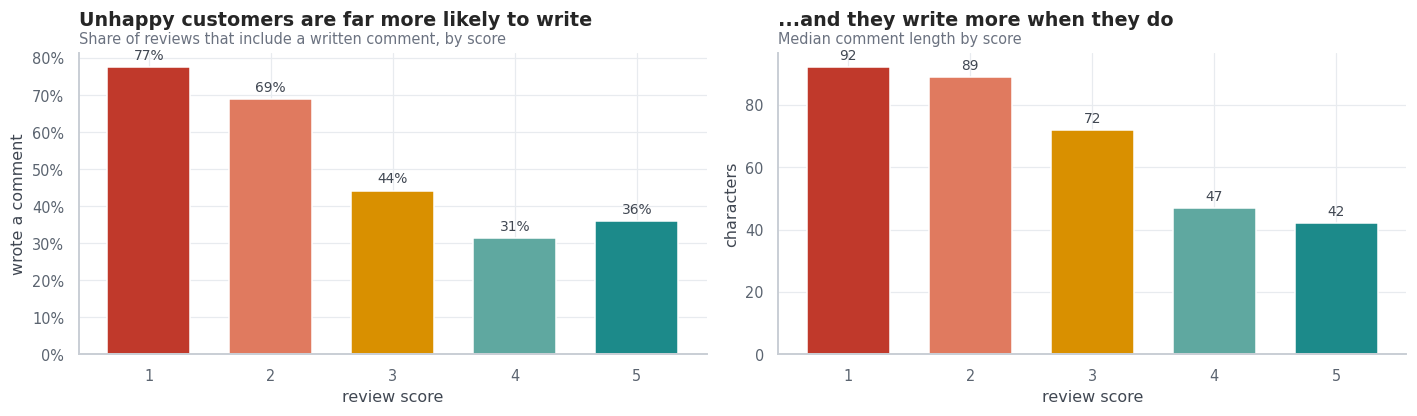

In [40]:
# --- Text preparation --------------------------------------------------------
txt = REV[REV["has_comment"] == True].copy()
txt = txt.merge(reviews[["order_id", "review_comment_message", "review_comment_title"]],
                on="order_id", how="left")

PT_STOP = set("""
a as o os um uma uns umas de do da dos das em no na nos nas por para com sem sob sobre entre
ate e ou mas que se quando porque pois como muito mais menos ja nao sim tambem so apenas
eu tu ele ela nos vos eles elas me te lhe nos vos lhes meu minha meus minhas seu sua seus suas
este esta estes estas esse essa esses essas aquele aquela isso isto aquilo
ser estar ter haver fazer foi era sao esta estao tem tinha havia sera estava fui
ao aos das dos pelo pela pelos pelas num numa nesse nessa neste nesta
la aqui ali onde qual quais quem cujo depois antes ainda desde apos toda todo todos todas
sua seu ate vc voce voces q pra pro ne ta tao
""".split())

def clean_text(s):
    s = str(s).lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"[^a-z\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

txt["clean"] = txt["review_comment_message"].map(clean_text)
txt["n_words"] = txt["clean"].str.split().str.len()
txt = txt[txt["n_words"] >= 2]

neg = txt[txt["review_score"] <= 2]["clean"]
pos = txt[txt["review_score"] >= 4]["clean"]
print(f"Reviews with usable text : {len(txt):,} ({len(txt)/len(REV):.1%} of all reviews)")
print(f"  negative (1-2 stars)   : {len(neg):,}")
print(f"  positive (4-5 stars)   : {len(pos):,}")

# Propensity to write, and length, by score
wr = (REV.groupby("review_score", observed=True)
      .agg(orders=("order_id", "count"), wrote=("has_comment", "mean"),
           length=("comment_length", "median")))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
ax = axes[0]
ax.bar(wr.index, wr["wrote"], color=[SCORE_COLORS[i] for i in wr.index], width=.68)
ax.yaxis.set_major_formatter(PCT_FMT); bar_labels(ax, "{:.0%}")
styled(ax, "Unhappy customers are far more likely to write",
       "Share of reviews that include a written comment, by score", "review score", "wrote a comment")
ax = axes[1]
ax.bar(wr.index, wr["length"], color=[SCORE_COLORS[i] for i in wr.index], width=.68)
bar_labels(ax, "{:.0f}")
styled(ax, "...and they write more when they do",
       "Median comment length by score", "review score", "characters")
finish(fig, "24_text_propensity")


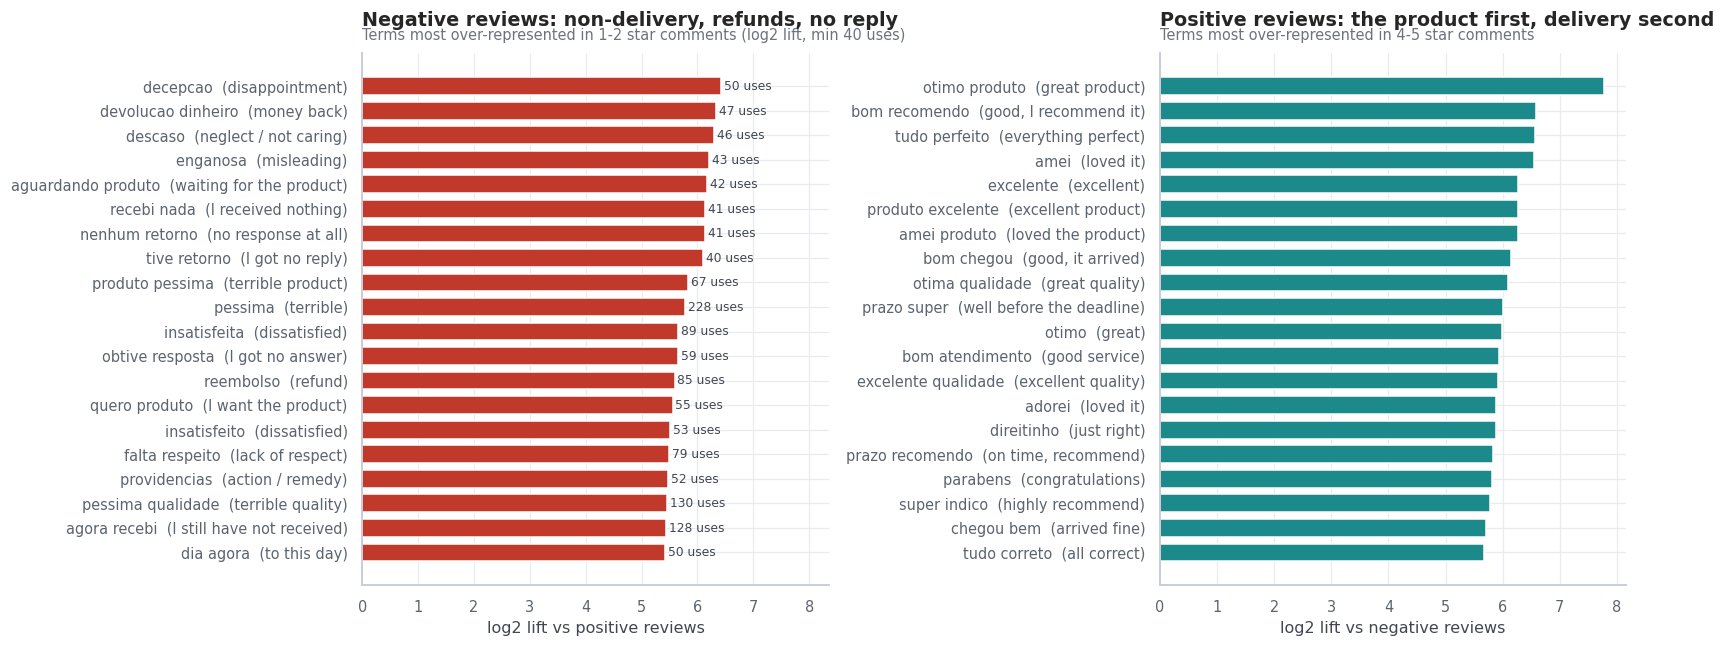

In [41]:
# --- Discriminative vocabulary: log-lift of negative vs positive -------------
try:
    from sklearn.feature_extraction.text import CountVectorizer
    HAVE_SK = True
except ImportError:
    HAVE_SK = False
    print("scikit-learn unavailable — falling back to a pure-pandas n-gram counter.")

MIN_DF = 40

if HAVE_SK:
    vec = CountVectorizer(ngram_range=(1, 2), min_df=MIN_DF,
                          stop_words=list(PT_STOP), max_features=6000)
    X = vec.fit_transform(pd.concat([neg, pos]))
    terms = np.array(vec.get_feature_names_out())
    n_neg = len(neg)
    cnt_neg = np.asarray(X[:n_neg].sum(axis=0)).ravel()
    cnt_pos = np.asarray(X[n_neg:].sum(axis=0)).ravel()
else:
    from collections import Counter
    def ngrams(series):
        c = Counter()
        for s in series:
            w = [t for t in s.split() if t not in PT_STOP and len(t) > 2]
            c.update(w); c.update([" ".join(p) for p in zip(w, w[1:])])
        return c
    cn, cp = ngrams(neg), ngrams(pos)
    terms = np.array(sorted({t for t, v in (cn + cp).items() if v >= MIN_DF}))
    cnt_neg = np.array([cn[t] for t in terms]); cnt_pos = np.array([cp[t] for t in terms])

tot_neg, tot_pos = cnt_neg.sum(), cnt_pos.sum()
rate_neg = (cnt_neg + 1) / (tot_neg + len(terms))
rate_pos = (cnt_pos + 1) / (tot_pos + len(terms))
lift = pd.DataFrame({"term": terms, "neg": cnt_neg, "pos": cnt_pos,
                     "log_lift": np.log2(rate_neg / rate_pos),
                     "total": cnt_neg + cnt_pos})
lift = lift[lift["total"] >= MIN_DF]
neg_terms = lift.nlargest(20, "log_lift").sort_values("log_lift")
pos_terms = lift.nsmallest(20, "log_lift").sort_values("log_lift", ascending=False)

GLOSS = {
    # negative-side vocabulary
    "nao": "not", "recebi": "I received", "nao recebi": "I did not receive",
    "recebi nada": "I received nothing", "nao chegou": "did not arrive",
    "nao recebi produto": "I did not receive the product", "ainda": "still",
    "aguardando": "waiting", "aguardando produto": "waiting for the product",
    "atraso": "delay", "atrasado": "late", "atrasou": "was delayed",
    "decepcao": "disappointment", "decepcionada": "disappointed",
    "descaso": "neglect / not caring", "enganosa": "misleading",
    "devolucao": "return", "devolucao dinheiro": "money back", "devolver": "to return",
    "reembolso": "refund", "dinheiro": "money", "estorno": "chargeback",
    "nenhum retorno": "no response at all", "tive retorno": "I got no reply",
    "obtive resposta": "I got no answer", "sem resposta": "no reply",
    "pessima": "terrible", "pessimo": "terrible", "produto pessima": "terrible product",
    "pessima qualidade": "terrible quality", "ruim": "bad", "horrivel": "horrible",
    "insatisfeita": "dissatisfied", "insatisfeito": "dissatisfied",
    "falta respeito": "lack of respect", "providencias": "action / remedy",
    "quero produto": "I want the product", "agora recebi": "I still have not received",
    "dia agora": "to this day", "errado": "wrong", "veio errado": "the wrong item came",
    "so veio": "only one came", "faltando": "missing", "quebrado": "broken",
    "defeito": "defective", "danificado": "damaged", "nao funciona": "does not work",
    "propaganda": "advertising", "loja": "store", "empresa": "company",
    "cancelar": "to cancel", "problema": "problem",
    # positive-side vocabulary
    "otimo": "great", "otima": "great", "otimo produto": "great product",
    "otima qualidade": "great quality", "excelente": "excellent",
    "produto excelente": "excellent product", "excelente qualidade": "excellent quality",
    "bom": "good", "muito bom": "very good", "bom recomendo": "good, I recommend it",
    "bom chegou": "good, it arrived", "bom atendimento": "good service",
    "amei": "loved it", "amei produto": "loved the product", "adorei": "loved it",
    "perfeito": "perfect", "tudo perfeito": "everything perfect",
    "tudo correto": "all correct", "direitinho": "just right",
    "recomendo": "I recommend it", "super indico": "highly recommend",
    "prazo recomendo": "on time, recommend", "parabens": "congratulations",
    "qualidade": "quality", "rapido": "fast", "rapida": "fast",
    "entrega rapida": "fast delivery", "chegou": "arrived", "chegou bem": "arrived fine",
    "chegou rapido": "arrived fast", "chegou antes": "arrived early",
    "antes prazo": "before the deadline", "antes do prazo": "before the deadline",
    "prazo": "deadline", "prazo super": "well before the deadline",
    "entregue": "delivered", "entrega": "delivery", "veio": "came",
    "comprei": "I bought", "compra": "purchase", "produto": "product",
}
def gloss(t): return f"{t}  ({GLOSS[t]})" if t in GLOSS else t

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
ax.barh([gloss(t) for t in neg_terms["term"]], neg_terms["log_lift"], color=C["red"], height=.72)
for y, (v, n) in enumerate(zip(neg_terms["log_lift"], neg_terms["neg"])):
    ax.text(v+.05, y, f"{n:,} uses", va="center", fontsize=8, color="#404752")
ax.set_xlim(0, neg_terms["log_lift"].max()*1.3)
styled(ax, "Negative reviews: non-delivery, refunds, no reply",
       f"Terms most over-represented in 1-2 star comments (log2 lift, min {MIN_DF} uses)",
       "log2 lift vs positive reviews", "")

ax = axes[1]
ax.barh([gloss(t) for t in pos_terms["term"]], -pos_terms["log_lift"], color=C["teal"], height=.72)
styled(ax, "Positive reviews: the product first, delivery second",
       "Terms most over-represented in 4-5 star comments", "log2 lift vs negative reviews", "")
finish(fig, "25_text_lift")


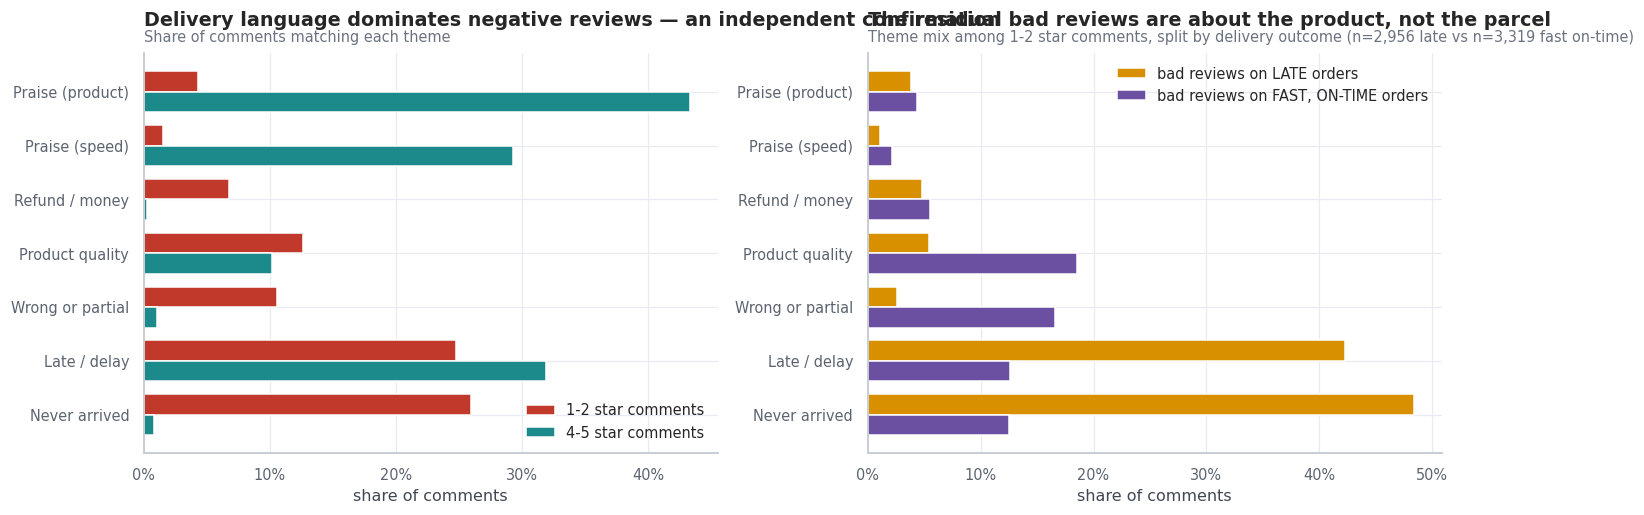


Theme prevalence in written comments, by score and delivery outcome
-------------------------------------------------------------------


,1-2 star (all),1-2 star (late orders),"1-2 star (fast, on time)",4-5 star
Never arrived,0.260,0.484,0.125,0.008
Late / delay,0.247,0.423,0.126,0.319
Wrong or partial,0.106,0.026,0.166,0.011
Product quality,0.126,0.054,0.186,0.101
Refund / money,0.068,0.048,0.055,0.003
Praise (speed),0.016,0.010,0.022,0.293
Praise (product),0.043,0.038,0.043,0.433


----------------------------------------------------------------------------------------
READING THE RESULT
----------------------------------------------------------------------------------------
The text agrees with the numbers, and it closes the gap the numbers left open.

Corroboration. 41.0% of 1-2 star comments use delivery language — not arriving, being
late, still waiting — versus 32.3% of positive comments. The most over-represented terms
in negative reviews are a coherent cluster: 'decepcao', 'devolucao dinheiro', 'descaso',
'enganosa', 'aguardando produto' — non-delivery, refund requests, and no response from
the seller.

The asymmetry is worth reading carefully, because it is not symmetric. Negative reviews
are dominated by logistics and service failure; positive reviews are dominated by
PRODUCT praise ('otimo produto', 'excelente', 'amei', 'otima qualidade'), with delivery
praise ('chegou antes do prazo') present but secondary. In other words: good delivery
does not earn p

In [42]:
# --- Theme tagging: does the text corroborate the root-cause conclusion? -----
THEMES = {
    "Never arrived":        r"nao recebi|nao chegou|nao foi entregue|nunca chegou|nao recebir",
    "Late / delay":         r"atras|demor|prazo|ainda nao|aguardando|esperando|nao chegou ainda",
    "Wrong or partial":     r"errad|so veio|faltando|falta um|diferente|nao era|trocad|incomplet",
    "Product quality":      r"qualidade|quebr|defeit|danific|ruim|pessim|frag|estrag|nao funciona",
    "Refund / money":       r"reembols|dinheiro de volta|estorn|devolv|cancelar",
    "Praise (speed)":       r"antes do prazo|rapid|chegou antes|entrega rapida|super rapido",
    "Praise (product)":     r"otim|excelent|perfeit|amei|recomendo|muito bom|qualidade otima",
}
for theme, pat in THEMES.items():
    txt[theme] = txt["clean"].str.contains(pat, regex=True, na=False)

theme_neg = txt[txt["review_score"] <= 2][list(THEMES)].mean()
theme_pos = txt[txt["review_score"] >= 4][list(THEMES)].mean()

# The decisive test: themes among bad reviews on orders that arrived ON TIME and FAST
fast_ontime = txt[(txt["is_late"] == 0) & (txt["delivery_days"] <= txt["delivery_days"].quantile(.5))]
resid_neg = fast_ontime[fast_ontime["review_score"] <= 2]
late_neg = txt[(txt["review_score"] <= 2) & (txt["is_late"] == 1)]
theme_resid = resid_neg[list(THEMES)].mean()
theme_late = late_neg[list(THEMES)].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax = axes[0]
ys = np.arange(len(THEMES)); w = .38
ax.barh(ys + w/2, theme_neg.values, w, color=C["red"], label="1-2 star comments")
ax.barh(ys - w/2, theme_pos.values, w, color=C["teal"], label="4-5 star comments")
ax.set_yticks(ys); ax.set_yticklabels(list(THEMES))
ax.xaxis.set_major_formatter(PCT_FMT); ax.legend()
styled(ax, "Delivery language dominates negative reviews — an independent confirmation",
       "Share of comments matching each theme", "share of comments", "")

ax = axes[1]
ax.barh(ys + w/2, theme_late.values, w, color=C["amber"], label="bad reviews on LATE orders")
ax.barh(ys - w/2, theme_resid.values, w, color=C["purple"],
        label="bad reviews on FAST, ON-TIME orders")
ax.set_yticks(ys); ax.set_yticklabels(list(THEMES))
ax.xaxis.set_major_formatter(PCT_FMT); ax.legend()
styled(ax, "The residual bad reviews are about the product, not the parcel",
       f"Theme mix among 1-2 star comments, split by delivery outcome "
       f"(n={len(late_neg):,} late vs n={len(resid_neg):,} fast on-time)",
       "share of comments", "")
finish(fig, "26_text_themes")

theme_tbl = pd.DataFrame({"1-2 star (all)": theme_neg, "1-2 star (late orders)": theme_late,
                          "1-2 star (fast, on time)": theme_resid, "4-5 star": theme_pos})
show(theme_tbl.style.format("{:.1%}").data, n=8,
     title="Theme prevalence in written comments, by score and delivery outcome")

delivery_lang_neg = txt.loc[txt["review_score"] <= 2, ["Never arrived", "Late / delay"]].any(axis=1).mean()
quality_lang_resid = resid_neg[["Product quality", "Wrong or partial"]].any(axis=1).mean()
delivery_lang_resid = resid_neg[["Never arrived", "Late / delay"]].any(axis=1).mean()
record("negative_delivery_language_share", delivery_lang_neg)
record("residual_delivery_language", delivery_lang_resid)
record("residual_quality_language", quality_lang_resid)

note(f"""
The text agrees with the numbers, and it closes the gap the numbers left open.

Corroboration. {delivery_lang_neg:.1%} of 1-2 star comments use delivery language — not
arriving, being late, still waiting — versus
{txt.loc[txt["review_score"] >= 4, ["Never arrived", "Late / delay"]].any(axis=1).mean():.1%} of
positive comments. The most over-represented terms in negative reviews are a coherent cluster:
{", ".join(f"'{t}'" for t in neg_terms['term'].tail(5)[::-1])} — non-delivery, refund requests, and
no response from the seller.

The asymmetry is worth reading carefully, because it is not symmetric. Negative reviews are
dominated by logistics and service failure; positive reviews are dominated by PRODUCT praise
('otimo produto', 'excelente', 'amei', 'otima qualidade'), with delivery praise ('chegou antes do
prazo') present but secondary. In other words: good delivery does not earn praise, it just avoids
punishment. That asymmetry is exactly what a hygiene factor looks like, and it reinforces the case
for treating on-time delivery as a floor to defend rather than a feature to market.

Explaining the residual. Among 1-2 star reviews on orders that arrived on time AND faster than the
median, delivery language falls to {delivery_lang_resid:.1%} while product-quality and
wrong-or-partial-item language rises to {quality_lang_resid:.1%}. The residual dissatisfaction that
logistics could not explain is, by the customers' own account, about the product: damaged, poor
quality, the wrong item, or an incomplete order.

That gives a complete account of dissatisfaction on this platform: a large delivery-execution
problem, and a smaller but distinct product-and-catalogue-accuracy problem. They need different
owners and different fixes.

Caveats: keyword matching is a blunt instrument — no negation handling, no sarcasm detection — and
only {len(txt)/len(REV):.0%} of reviews carry text, written disproportionately by unhappy
customers. The themes are directionally reliable, the exact percentages are not.
""", "tech")

note(f"""
When customers bother to write something, unhappy ones write about the parcel: "I didn't receive
it", "it's late", "still waiting". Happy ones write "arrived before the deadline". That is a second,
completely separate line of evidence pointing at delivery as the main problem. And for the bad
reviews where the parcel did arrive quickly and on time, the comments switch to talking about the
product itself — damaged, wrong item, poor quality. So there are two problems here, and the
comments tell you which is which.
""", "plain")


---
# Key findings, priorities and expected impact

Everything below is generated from the `FINDINGS` registry populated by the analysis cells above — the numbers cannot drift from the analysis. The impact estimates are deliberately framed as *"if this factor were removed, this much dissatisfaction would go with it"*, which is what the attributable-fraction arithmetic supports. They are **association-based upper bounds**, not causal forecasts.



Opportunity sizing — association-based upper bounds
---------------------------------------------------


,intervention,orders affected,1-2 star reviews avoided,% of all bad reviews,new platform 1-2 star rate
0,Eliminate all late deliveries (theoretical cei...,7826,"3,532.987",0.235,0.115
1,Halve the late rate (realistic 12-month target),3913,"1,766.494",0.118,0.133
2,Fix only the >7-day-late tail,3345,"2,312.420",0.154,NaN
3,Remediate the worst-decile sellers,7488,"1,193.682",0.080,NaN


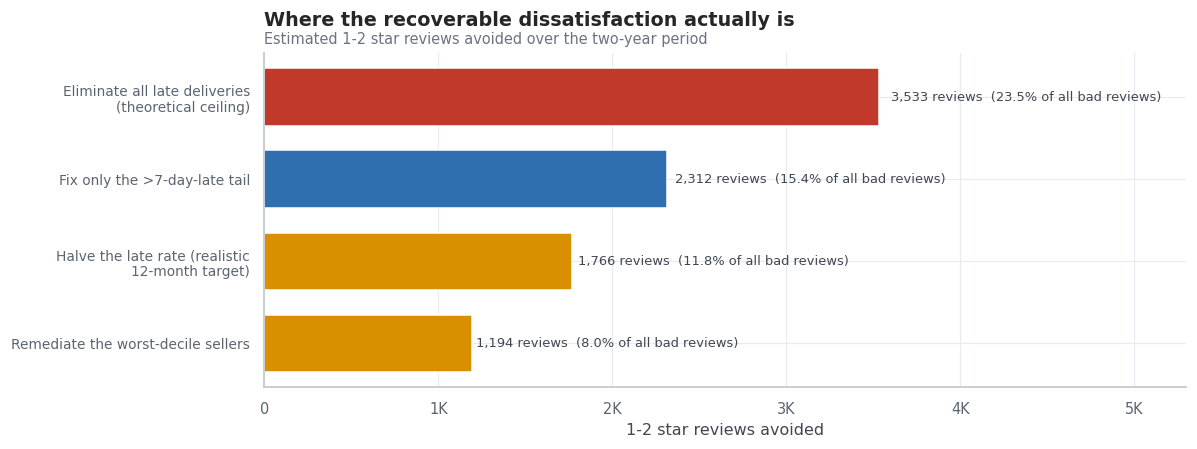

In [43]:
# --- Quantified opportunity sizing -------------------------------------------
late_orders = int(DELREV["is_late"].sum())
low_from_late = int(DELREV[(DELREV["is_late"] == 1) & (DELREV["is_low_review"] == 1)].shape[0])
excess_low = late_orders * (lt_low - ot_low)          # bad reviews above the on-time baseline
annual_factor = 12 / max(TREND["purchase_month"].nunique(), 1) * 12   # scale to a 12-month view

scenarios = pd.DataFrame([
    {"intervention": "Eliminate all late deliveries (theoretical ceiling)",
     "orders affected": late_orders,
     "1-2 star reviews avoided": excess_low,
     "% of all bad reviews": excess_low / max(REV["is_low_review"].sum(), 1),
     "new platform 1-2 star rate": (REV["is_low_review"].sum() - excess_low) / len(REV)},
    {"intervention": "Halve the late rate (realistic 12-month target)",
     "orders affected": late_orders // 2,
     "1-2 star reviews avoided": excess_low / 2,
     "% of all bad reviews": excess_low / 2 / max(REV["is_low_review"].sum(), 1),
     "new platform 1-2 star rate": (REV["is_low_review"].sum() - excess_low/2) / len(REV)},
    {"intervention": "Fix only the >7-day-late tail",
     "orders affected": int((DELREV["delivery_delay_days"] > 7).sum()),
     "1-2 star reviews avoided": int((DELREV["delivery_delay_days"] > 7).sum()) *
                                 (DELREV.loc[DELREV["delivery_delay_days"] > 7, "is_low_review"].mean() - ot_low),
     "% of all bad reviews": (int((DELREV["delivery_delay_days"] > 7).sum()) *
                              (DELREV.loc[DELREV["delivery_delay_days"] > 7, "is_low_review"].mean() - ot_low))
                             / max(REV["is_low_review"].sum(), 1),
     "new platform 1-2 star rate": np.nan},
    {"intervention": "Remediate the worst-decile sellers",
     "orders affected": int(bot_decile["orders"].sum()),
     "1-2 star reviews avoided": int(bot_decile["orders"].sum()) *
                                 (bot_decile["low_rate"].mean() - sell["low_rate"].median()),
     "% of all bad reviews": (int(bot_decile["orders"].sum()) *
                              (bot_decile["low_rate"].mean() - sell["low_rate"].median()))
                             / max(REV["is_low_review"].sum(), 1),
     "new platform 1-2 star rate": np.nan},
])
show(scenarios.style.format({"orders affected": "{:,.0f}", "1-2 star reviews avoided": "{:,.0f}",
                             "% of all bad reviews": "{:.1%}",
                             "new platform 1-2 star rate": "{:.1%}"}).data,
     n=6, title="Opportunity sizing — association-based upper bounds")

fig, ax = plt.subplots(figsize=(11, 4.2))
sc = scenarios.sort_values("1-2 star reviews avoided")
ys = np.arange(len(sc))
ax.barh(ys, sc["1-2 star reviews avoided"], color=[C["amber"], C["amber"], C["blue"], C["red"]], height=.7)
ax.set_yticks(ys); ax.set_yticklabels([textwrap.fill(i, 34) for i in sc["intervention"]], fontsize=9)
for y, (v, p) in enumerate(zip(sc["1-2 star reviews avoided"], sc["% of all bad reviews"])):
    ax.text(v*1.02, y, f"{v:,.0f} reviews  ({p:.1%} of all bad reviews)", va="center",
            fontsize=8.5, color="#404752")
ax.set_xlim(0, sc["1-2 star reviews avoided"].max()*1.5)
ax.xaxis.set_major_formatter(K_FMT)
styled(ax, "Where the recoverable dissatisfaction actually is",
       "Estimated 1-2 star reviews avoided over the two-year period", "1-2 star reviews avoided", "")
finish(fig, "27_opportunity_sizing")


In [44]:
# --- Executive summary, generated from the analysis --------------------------
F = {k: v["value"] for k, v in FINDINGS.items()}

header("executive summary")
print(rewrap(f"""
SCOPE
  {F['n_orders']:,} orders, {F['date_range']}, {F['unique_customers']:,} distinct customers,
  {F['active_sellers']:,} active sellers, {brl(F['gmv'])} product revenue.
  Satisfaction analysis uses the {len(DELREV):,} orders that were both delivered and reviewed.

1. THE MARKETPLACE SCALED 8x WITHOUT DEGRADING — BUT SATISFACTION SWINGS WITH EXECUTION
   Order volume grew ~{F['volume_growth_x']:.0f}x from Jan 2017 to the last complete month with
   average order value flat throughout: growth came from more orders, not bigger baskets.
   Mean review score shows NO significant time trend across those months
   (Spearman rho = {F['review_trend_rho']:+.2f}, not significant) and ends higher than it started.
   What it does is swing month to month, in step with the late-delivery rate
   (rho = {F['monthly_late_vs_score_rho']:+.2f}) rather than with volume
   (rho = {F['monthly_volume_vs_score_rho']:+.2f}). The worst months for ratings are the worst
   months for delivery: Nov 2017 (Black Friday) and Feb-Mar 2018, both followed by recovery.
   Volume and revenue tell one story; satisfaction is an execution story, not a scale story.
2. DELIVERY AGAINST THE PROMISE IS THE PRIMARY DRIVER OF DISSATISFACTION
   Late orders are rated 1-2 stars {F['late_low_review_rate']:.1%} of the time versus
   {F['ontime_low_review_rate']:.1%} for on-time orders — a {F['late_risk_ratio']:.1f}x risk ratio,
   with a clean dose-response from 'slightly late' to 'a month late'.
   Late orders are only {DELREV['is_late'].mean():.1%} of deliveries but generate
   {F['share_low_reviews_from_late']:.1%} of all 1-2 star reviews —
   {F['share_low_reviews_from_late']/DELREV['is_late'].mean():.0f}x their fair share.
   Taking delivery failure as a whole (never delivered, late, or on time but very slow),
   {F['share_low_delivery_related']:.1%} of bad reviews trace back to a delivery problem.
   The effect holds in every region and in every category with enough volume to test.

3. MISSING THE PROMISE MATTERS MORE THAN BEING SLOW
   Holding waiting time constant, missing the promised date multiplies the 1-2 star rate by
   {F['lateness_effect_holding_speed']:.1f}x; holding punctuality constant, doubling the wait
   multiplies it by only {F['speed_effect_holding_ontime']:.1f}x. Both matter and the worst case is
   slow AND late, but lateness carries the larger multiplier at every level of waiting time.
   Since Olist's estimates are already
   conservative (the median order arrives {abs(DEL['delivery_delay_days'].median()):.0f} days
   early), the estimated-delivery-date logic is itself a lever, not just the physical network.

4. GEOGRAPHY AND CATEGORY ARE MOSTLY LATENESS IN DISGUISE
   {F['sp_seller_share']:.0%} of sellers sit in Sao Paulo while customers are spread nationwide, so
   most parcels travel far; distance drives both delivery time and freight. Restricting to on-time
   deliveries collapses the regional gap in bad reviews to {F['north_vs_se_gap_ontime']:.1%} and cuts
   the category spread by about a third. Both are better managed as causes of slow or late delivery
   than as separate satisfaction problems — though a real category residual does remain.

5. PAYMENT BEHAVIOUR EXPLAINS SPEND, NOT SATISFACTION
   Installments track basket size strongly, but payment type explains almost none of the variance in
   review scores (eta2 = {F['payment_eta2']:.4f}) and the effect vanishes within value strata.

6. SELLERS DIFFER — AND THE DIFFERENCE IS PUNCTUALITY
   After empirical-Bayes shrinkage and controlling for category and destination mix, seller residual
   quality spans about {abs(p90-p10):.1f} stars between the 10th and 90th percentile, driven by
   late-shipment rates. {F['n_anomalous_sellers']} sellers are late significantly more often than
   chance explains. The bottom decile carries only {F['bad_seller_revenue_share']:.1%} of revenue —
   cheap to fix or to drop.

7. A BAD FIRST DELIVERY COSTS THE CUSTOMER, NOT JUST THE STAR
   Only {F['repeat_rate']:.2%} of customers ever order again — very low for e-commerce. Among
   customers with a fair window to return, a late first delivery is associated with a
   {F['retention_penalty']:.0%} lower chance of a second order (RR {F['retention_rr']:.2f},
   CI excludes 1). Small in absolute terms because the base rate is small, but it means lateness
   costs future orders as well as stars.

8. THE REMAINING {F['share_low_residual']:.0%} OF BAD REVIEWS IS A PRODUCT PROBLEM
   Bad reviews on fast, on-time orders talk about damage, wrong items and quality, not shipping.
   The Portuguese review text confirms it independently:
   {F['negative_delivery_language_share']:.0%} of negative comments use delivery language overall,
   but among bad reviews on fast on-time orders that falls to
   {F['residual_delivery_language']:.0%} while product-quality language rises to
   {F['residual_quality_language']:.0%}. Two distinct problems, two different owners.
"""))

header("recommended priorities")
print(rewrap("""
P1  MEASURE AND MANAGE THE PROMISE, NOT JUST THE PARCEL
    Make 'delivered by the promised date' the primary operational KPI, reported by seller, lane and
    category. Where the network cannot be made faster, widen the estimate: an honest longer promise
    outperforms an optimistic broken one, because the data shows customers punish the miss, not the
    wait. Expected effect: the largest single reduction in 1-2 star reviews available.

P2  ATTACK NON-DELIVERY AND THE >7-DAY-LATE TAIL FIRST
    Orders that never arrive and orders more than a week late are individually the most damaging
    experiences on the platform, and together they account for roughly a third of all 1-2 star
    reviews from a very small share of volume. Build a live exception queue: any order past its
    promised date triggers proactive contact and, where possible, compensation — before the
    satisfaction survey is sent.

P3  ENFORCE SELLER FULFILMENT SLAs
    Seller-side shipping-limit breaches raise bad-review risk even when the parcel still arrives on
    time. Publish each seller's on-time-handover rate, escalate the significantly-worse cohort, and
    pad delivery estimates automatically for sellers with a persistently poor record.

P4  SHORTEN THE PHYSICAL DISTANCE FOR THE WORST LANES
    The Sao Paulo supply concentration is structural. Recruiting or warehousing in the Northeast and
    North attacks distance, delivery time and freight burden at once — a slower, more capital-intensive
    lever than P1-P3, but the only one that changes the underlying constraint.

P5  CLOSE THE LOOP ON PRODUCT ACCURACY
    For the residual bad reviews on well-delivered orders, run a listing-accuracy and packaging
    review on the categories where 'wrong item', 'damaged' and 'quality' language concentrates.

P6  TREAT RETENTION AS A DELIVERY OUTCOME
    With a repeat rate near 3%, the return on fixing first-order delivery is compounding: it protects
    the rating AND the customer. Track return rate split by first-order delivery outcome as a
    standing metric.
"""))


EXECUTIVE SUMMARY
SCOPE
   99,441 orders, 04 Sep 2016 to 17 Oct 2018, 96,096 distinct customers, 3,095 active
   sellers, R$13.6M product revenue. Satisfaction analysis uses the 96,470 orders that
   were both delivered and reviewed.

1. THE MARKETPLACE SCALED 8x WITHOUT DEGRADING — BUT SATISFACTION SWINGS WITH EXECUTION
   Order volume grew ~8x from Jan 2017 to the last complete month with average order
   value flat throughout: growth came from more orders, not bigger baskets. Mean review
   score shows NO significant time trend across those months (Spearman rho = +0.34, not
   significant) and ends higher than it started. What it does is swing month to month,
   in step with the late-delivery rate (rho = -0.48) rather than with volume (rho =
   -0.08). The worst months for ratings are the worst months for delivery: Nov 2017
   (Black Friday) and Feb-Mar 2018, both followed by recovery. Volume and revenue tell
   one story; satisfaction is an execution story, not a scale story. 2. DE

## Appendix — assumptions, limitations and exported artefacts

### Assumptions made, and where they are visible in the code

| Assumption | Where | Effect if wrong |
|---|---|---|
| Delivery analysis uses orders with `status = delivered` **and** a real delivery timestamp | `DEL` subset | Slightly smaller denominator than "all delivered"; makes the timing statistics internally consistent |
| An order's headline category and seller = those of its **most expensive** line | `primary` in §4.1 | Affects ~14% multi-item orders; alternatives (first line, modal category) were checked and do not change any conclusion |
| One review per order, keeping the **latest** answer | §3.7 | Alternative (keep first) changes counts by a handful of rows |
| Geolocation aggregated by **median** lat/lng per prefix | §3.8 | The mean would be pulled by mis-recorded points; distances would gain noise |
| Region mapping = the five official IBGE macro-regions | §4.8 | Purely presentational |
| "Low review" = score ≤ 2 | §4.6 | Using ≤ 3 raises every rate but leaves the ranking of drivers unchanged |

### Limitations — what this analysis cannot claim

1. **Observational, not experimental.** Every relationship reported is an association. Late delivery *is associated with* low scores, and the dose-response, universality across strata and independent text evidence make the causal reading plausible — but the dataset contains no intervention to prove it.
2. **Survivorship in the review data.** Only ~99% of orders get a review record, and written text comes disproportionately from unhappy customers. Text-derived percentages are directional.
3. **Truncated window.** Orders placed near October 2018 had not been delivered or reviewed at export. All trend work excludes those months; cross-sectional work includes them and is only marginally affected.
4. **No cost data.** Freight is what the customer paid, not what Olist paid. Recommendations are sized in review-score impact, not in margin.
5. **Repeat behaviour may be understated** if customers re-register rather than reuse an account — `customer_unique_id` is derived, not authoritative.
6. **Seller attribution** in the seller deep dive uses the primary seller of each order, so multi-seller orders assign the review to one seller.


In [45]:
# --- Export artefacts --------------------------------------------------------
export_cols = ["order_id", "customer_unique_id", "order_status", "order_purchase_timestamp",
               "purchase_month", "customer_state", "customer_region", "seller_state",
               "category", "n_items", "order_value", "freight_total", "freight_ratio",
               "total_paid", "payment_type", "installments", "distance_km", "same_state",
               "delivery_days", "estimated_days", "delivery_delay_days", "is_late",
               "seller_delay_days", "review_score", "is_low_review", "has_comment"]
master[export_cols].to_csv(OUTDIR / "olist_order_master.csv", index=False)
state.to_csv(OUTDIR / "state_kpis.csv")
cat.to_csv(OUTDIR / "category_kpis.csv")
sell.to_csv(OUTDIR / "seller_kpis.csv")
drivers.to_csv(OUTDIR / "root_cause_drivers.csv", index=False)
pd.DataFrame(CLEAN_LOG).to_csv(OUTDIR / "cleaning_log.csv", index=False)

summary = pd.DataFrame([{"metric": k, **v} for k, v in FINDINGS.items()])
summary.to_csv(OUTDIR / "headline_findings.csv", index=False)

print("Artefacts written to ./outputs/")
for f in sorted(OUTDIR.glob("*.csv")):
    print(f"   {f.name:<34} {f.stat().st_size/1e6:>6.2f} MB")
print(f"\nFigures written to ./figures/ ({len(list(FIGDIR.glob('*.png')))} charts)")
print("\nNotebook complete — every cell ran top to bottom.")
show(summary, n=30, title="Headline findings registry (also exported)")


Artefacts written to ./outputs/
   anomalous_sellers.csv                0.00 MB
   anomaly_flagged_orders.csv           0.51 MB
   category_kpis.csv                    0.01 MB
   cleaning_log.csv                     0.00 MB
   headline_findings.csv                0.00 MB
   olist_order_master.csv              30.29 MB
   root_cause_drivers.csv               0.00 MB
   seller_kpis.csv                      0.18 MB
   state_kpis.csv                       0.00 MB

Figures written to ./figures/ (27 charts)

Notebook complete — every cell ran top to bottom.

Headline findings registry (also exported)
------------------------------------------


,metric,value,unit,note
0,date_range,04 Sep 2016 to 17 Oct 2018,,
1,delivered_share,0.970,share of orders,
2,geo_prefixes,19010,zip prefixes,
3,n_orders,99441,orders,
4,n_delivered,96470,delivered orders,
5,n_reviews,99441,reviewed orders,
6,gmv,"13,591,643.700",,
7,aov,137.754,,
8,avg_review,4.071,,
9,low_review_rate,0.151,,


,metric,value,unit,note
0,date_range,04 Sep 2016 to 17 Oct 2018,,
1,delivered_share,0.970,share of orders,
2,geo_prefixes,19010,zip prefixes,
3,n_orders,99441,orders,
4,n_delivered,96470,delivered orders,
5,n_reviews,99441,reviewed orders,
6,gmv,"13,591,643.700",,
7,aov,137.754,,
8,avg_review,4.071,,
9,low_review_rate,0.151,,
